In [ ]:
!pip install fink-client --upgrade
# fastavro 1.6.0 requires Cython<3
!pip install "Cython<3"
!pip install --no-build-isolation "fastavro==1.6.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 38.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 41.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.3/213.3 kB 20.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=0b44099a1d956c386e1ece58fdd7743a42c7f7e83f3260b452002c405d647182
  Stored in directory: /root/.cache/pip/wheels/fc/ab/d4/5da2067ac95b36618c629a5f93f809425700506f72c9732fac
Successfully built docopt
  Attempting uninstall: numpy
    Found existing installation: numpy 1.25.2
    Uninstalling numpy-1.25.2:
      Successfully uninstalled numpy-1.25.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.4 MB/s eta 0:00:00
  Attempting uninstall: Cython
    Found existing installation: Cython 3.0.9
    Uninstalling Cython-3.0.9:
      Successfully uninstalled Cython-3.0.9
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 10.3 MB/s eta 0:00:00


In [ ]:
# access help using `fink_client_register -h`
!fink_client_register -username yash -group_id yash_swinburne -servers 134.158.74.95:24499/ -maxtimeout 10 --verbose

Credentials stored at /root/.finkclient/credentials.yml
{'group_id': 'yash_swinburne', 'maxtimeout': 10, 'mytopics': [], 'password': None, 'servers': '134.158.74.95:24499/', 'username': 'yash'}


Choosing a very recent alert will mean that there will be very few data points: for Feb 1-2 2024 alerts and streaming the alerts on Feb 8, I only got 1-2 data points for all categories of light curves.

See also [this notebook](https://github.com/mcoughlin/ztf_summer_school_2023/blob/main/lectures/01/day01_fast_transients_solution.ipynb) and [this page](https://zwickytransientfacility.github.io/ztf-avro-alert/filtering.html) for some selection criteria.

Even if the data transfer is stopped in between, it will start from the same position when started again, which is a nice feature to prevent duplicates.

In [ ]:
topic = 'ftransfer_ztf_2024-03-18_636039'

In [ ]:
# Jan 1 - June 30, 2020 (6 months)
# For the northern hemisphere, summer months are probably better for observations (June, July & August).
# We have not added the criteria selecting only fast transients: to select fast transients, we require jd - jdstarthist < few days (e.g., 7).
# This can be handled downstream. We probably don't want to have a biased dataset where only "fast" transients are present.
# Also, we don't use the full light curves, so this "fast transient criterion" is not always accurate.
"""
candidate.nbad = 0;
candidate.fwhm <= 5;
candidate.elong <= 1.2;
ABS(candidate.magdiff) <= 0.1;
candidate.drb > 0.8 AND candidate.rb > 0.8;
candidate.ndethist > 2 AND candidate.ndethist < 80;
candidate.isdiffpos = "t";
NOT(candidate.ssdistnr < 10 AND candidate.ssdistnr > 0);
candidate.sgscore1 > 0.5 AND candidate.distpsnr1 < 1.5 AND candidate.distpsnr1 >= 0;
candidate.jd - candidate.jdstarthist > 30/60/24;
"""

import subprocess
from subprocess import Popen, PIPE, CalledProcessError, STDOUT

command = [
    'fink_datatransfer',
    '-topic', f'{topic}',
    '-outdir', f'{topic}',
    '-partitionby', 'finkclass',
    '--verbose'
]

def execute(cmd):
    """This function is taken from
    https://stackoverflow.com/a/28319191
    """
    with Popen(cmd, stdout=PIPE, bufsize=1, universal_newlines=True, stderr=STDOUT) as p:
        for line in p.stdout:
            print(line, end='') # process line here

    if p.returncode != 0:
        raise CalledProcessError(p.returncode, p.args)

execute(command)

Topic [Partition]                                   Committed        Lag
ftransfer_ztf_2024-03-18_636039 [0]                         -      12341
ftransfer_ztf_2024-03-18_636039 [1]                         -      12146
ftransfer_ztf_2024-03-18_636039 [2]                         -      12247
ftransfer_ztf_2024-03-18_636039 [3]                         -      12143
ftransfer_ztf_2024-03-18_636039 [4]                         -      12077
ftransfer_ztf_2024-03-18_636039 [5]                         -      12257
ftransfer_ztf_2024-03-18_636039 [6]                         -      12237
ftransfer_ztf_2024-03-18_636039 [7]                         -      12085
ftransfer_ztf_2024-03-18_636039 [8]                         -      12166
ftransfer_ztf_2024-03-18_636039 [9]                         -      12257
------------------------------------------------------------------------
Total                                                       0     121956
---------------------------------------------------

In [ ]:
import os
import glob
import pandas as pd
DIRS = f'/content/{topic}/*'
for DIR in glob.glob(DIRS):
    num_files = 0
    for f in glob.glob(os.path.join(DIR, '*.parquet')):
        df = pd.read_parquet(f)
        num_files += len(df)
    print(f'{DIR.split("/")[-1]}: {num_files} alerts')

finkclass=SN%20candidate: 1881 alerts
finkclass=GravLensSystem: 3 alerts
finkclass=QSO_Candidate: 24 alerts
finkclass=Inexistent: 1 alerts
finkclass=Candidate_LP%2A: 1027 alerts
finkclass=LensedQ: 1 alerts
finkclass=Candidate_YSO: 605 alerts
finkclass=Candidate_WD%2A: 14 alerts
finkclass=Candidate_brownD%2A: 5 alerts
finkclass=PN: 7 alerts
finkclass=Mira: 348 alerts
finkclass=BYDra: 8 alerts
finkclass=gammaDor: 4 alerts
finkclass=XB: 1 alerts
finkclass=C%2A: 119 alerts
finkclass=EmG: 2 alerts
finkclass=BLLac: 302 alerts
finkclass=PM%2A: 9 alerts
finkclass=PulsV%2A: 518 alerts
finkclass=pulsV%2ASX: 4 alerts
finkclass=Unknown: 66152 alerts
finkclass=PulsV%2ARVTau: 8 alerts
finkclass=SB%2A: 7 alerts
finkclass=Star: 1613 alerts
finkclass=Pec%2A: 26 alerts
finkclass=V%2A%3F: 2 alerts
finkclass=WD%2A: 3 alerts
finkclass=Candidate_CV%2A: 159 alerts
finkclass=Orion_V%2A: 136 alerts
finkclass=IR: 6 alerts
finkclass=QSO: 8875 alerts
finkclass=Seyfert_1: 786 alerts
finkclass=Candidate_RRLyr: 1638

In [ ]:
# We collate come subclasses into a single class based on the below rule.
import shutil
from distutils.dir_util import copy_tree

agn_list = ['AGN','Blazar','BLLac','LINER','QSO','Seyfert', 'Seyfert_1', 'Seyfert_2']
stars_list = ['EB*','CataclyV*','LMXB','RRLyr','RotV*','Star','WD*','low-mass*']
simbad_galaxies_list = [
        "galaxy",
        "Galaxy",
        "EmG",
        "Seyfert",
        "Seyfert_1",
        "Seyfert_2",
        "BlueCompG",
        "StarburstG",
        "LSB_G",
        "HII_G",
        "High_z_G",
        "GinPair",
        "GinGroup",
        "BClG",
        "GinCl",
        "PartofG",
        "Compact_Gr_G",
        "IG",
        "PairG",
        "GroupG",
        "ClG",
        "SuperClG",
        "Void",
    ]

AGN_DIR = os.path.join(f'/content/{topic}', 'custom_agn')
STARS_DIR = os.path.join(f'/content/{topic}', 'custom_stars')
SIMBAD_GALAXIES_DIR = os.path.join(f'/content/{topic}', 'simbad_galaxies')
os.makedirs(AGN_DIR, exist_ok=True)
os.makedirs(STARS_DIR, exist_ok=True)
os.makedirs(SIMBAD_GALAXIES_DIR, exist_ok=True)

print('Starting arranding subfolders...')
for raw_dir in glob.glob(DIRS):
    dir = raw_dir.split('/')[-1].split('finkclass=')[-1]
    print(dir)
    if dir in agn_list:
        shutil.move(raw_dir, AGN_DIR)
        # shutil.rmtree(raw_dir)
    elif dir in stars_list:
        shutil.move(raw_dir, STARS_DIR)
        # shutil.rmtree(raw_dir)
    elif dir in simbad_galaxies_list:
        shutil.move(raw_dir, SIMBAD_GALAXIES_DIR)
        # shutil.rmtree(raw_dir)
    else:
        print(f'Folder {dir} not in the alerts, skipping...')
print('Done!')

Starting arranding subfolders...
SN%20candidate
Folder SN%20candidate not in the alerts, skipping...
GravLensSystem
Folder GravLensSystem not in the alerts, skipping...
QSO_Candidate
Folder QSO_Candidate not in the alerts, skipping...
Inexistent
Folder Inexistent not in the alerts, skipping...
Candidate_LP%2A
Folder Candidate_LP%2A not in the alerts, skipping...
LensedQ
Folder LensedQ not in the alerts, skipping...
Candidate_YSO
Folder Candidate_YSO not in the alerts, skipping...
Candidate_WD%2A
Folder Candidate_WD%2A not in the alerts, skipping...
Candidate_brownD%2A
Folder Candidate_brownD%2A not in the alerts, skipping...
PN
Folder PN not in the alerts, skipping...
Mira
Folder Mira not in the alerts, skipping...
BYDra
Folder BYDra not in the alerts, skipping...
gammaDor
Folder gammaDor not in the alerts, skipping...
XB
Folder XB not in the alerts, skipping...
C%2A
Folder C%2A not in the alerts, skipping...
EmG
BLLac
PM%2A
Folder PM%2A not in the alerts, skipping...
PulsV%2A
Folder P

In [ ]:
!ls {AGN_DIR} | wc -l
!ls {STARS_DIR} | wc -l
!ls {SIMBAD_GALAXIES_DIR} | wc -l

6
3
2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def read_alert(folder):
    pdf = pd.read_parquet(folder)
    return pdf

df_alerts = read_alert(f'/content/{topic}')
df_alerts.head(2)

,objectId,candid,magpsf,sigmapsf,fid,jd,ra,dec,tnsclass,cdsxmatch,roid,mulens,snn_snia_vs_nonia,snn_sn_vs_all,rf_snia_vs_nonia,rf_kn_vs_nonkn,tracklet,lc_features_g,lc_features_r,finkclass
0,ZTF19aawfxge,1262464245615015003,18.745361,0.079393,2,2.459017e+06,322.679684,7.877787,Unknown,AGN,0,0.0,0.0,0.0,0.0,0.0,None,"{'amplitude': 0.07329940795898438, 'anderson_d...","{'amplitude': 0.09364986419677734, 'anderson_d...",AGN
1,ZTF18aadijyg,1145223834215015029,19.354258,0.123969,1,2.458900e+06,100.296835,33.749905,Unknown,AGN,0,0.0,0.0,0.0,0.0,0.0,None,"{'amplitude': 0.05305004119873047, 'anderson_d...","{'amplitude': None, 'anderson_darling_normal':...",AGN


**To understand the characteristics of different transients' light curves, see the code from the filters mentioned here: https://github.com/astrolabsoftware/fink-filters/blob/master/fink_filters**

To filter kilonova candidates, see https://github.com/astrolabsoftware/fink-filters/blob/master/fink_filters/filter_kn_candidates/filter.py

In [ ]:
df_alerts_shape = df_alerts.shape

In [ ]:
print(f'No. of alerts = {len(df_alerts)}')
print(f'No. of transients = {len(df_alerts["objectId"].unique())}')

No. of alerts = 121956
No. of transients = 69887


In [ ]:
df_alerts.columns

Index(['objectId', 'candid', 'magpsf', 'sigmapsf', 'fid', 'jd', 'ra', 'dec',
       'tnsclass', 'cdsxmatch', 'roid', 'mulens', 'snn_snia_vs_nonia',
       'snn_sn_vs_all', 'rf_snia_vs_nonia', 'rf_kn_vs_nonkn', 'tracklet',
       'lc_features_g', 'lc_features_r', 'finkclass'],
      dtype='object')

## Exploratory analysis

In [ ]:
def get_lc(df_alerts, name):
    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts['objectId'] == name].sort_values(by='jd')

    if pdf.empty:
        raise ValueError(f'No alerts exist for objectId = {name}, so cannot make a light curve!')

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    observation_data, observation_mask = [], []
    # for filt in np.unique(pdf['fid']):
    # Don't loop over pdf['fid'] since in pdf, we might not get all filters. For creating the dataset, we need fixed-sized arrays, so we should select all filters instead of filters seen in this pdf.
    for filt in np.unique(df_alerts['fid']):
        maskFilt = pdf['fid'] == filt
        observation_data.append(
            pdf['magpsf'] * maskFilt
        )
        observation_mask.append(
            maskFilt.astype(int)
        )

    observation_data = np.array(observation_data).T  # after transpose: seqlen x num_channels
    observation_mask = np.array(observation_mask).T  # after transpose: seqlen x num_channels

    times = np.expand_dims(pdf['jd'], 1)  # Add dimension at the 1st index to prepare for concatenation.
    data = np.concatenate((observation_data, observation_mask, times), axis=1)

    return data

def plot_lc(df_alerts, name):
    """ Plot photometry contained in an alert.

    Parameters
    ----------
    name: str
        objectID
    """
    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts['objectId'] == name].sort_values(by='jd')

    if pdf.empty:
        raise ValueError(f'No alerts exist for objectId = {name}!')

    fig = plt.figure(figsize=(15, 6))

    # Colors to plot
    colordic = {1: 'C0', 2: 'C1'}

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    for filt in np.unique(pdf['fid']):
        # select data from one filter at a time
        maskFilt = pdf['fid'] == filt

        plt.errorbar(
            pdf[maskFilt]['jd'],
            pdf[maskFilt]['magpsf'],
            pdf[maskFilt]['sigmapsf'],
            ls = '', marker='o', color=colordic[filt], label=filtdic[filt]
        )

        plt.errorbar(
            pdf[maskFilt]['jd'],
            pdf[maskFilt]['magpsf'],
            pdf[maskFilt]['sigmapsf'],
            ls='', marker='^', color=colordic[filt]
        )

        _offset_x = (pdf[maskFilt]['jd'].max() - pdf[maskFilt]['jd'].min()) / 200
        _offset_y = (pdf[maskFilt]['magpsf'].max() - pdf[maskFilt]['magpsf'].min()) / 100
        for x, y, string in zip(pdf[maskFilt]['jd'], pdf[maskFilt]['magpsf'], pdf[maskFilt]['finkclass']):
            plt.text(
                x+_offset_x, y+_offset_y, string,
                color=colordic[filt]
            )

    plt.gca().invert_yaxis()
    plt.legend()
    plt.title(f'{pdf["objectId"].unique()[0]}')
    plt.xlabel('Modified Julian Date')
    plt.ylabel('Magnitude')
    plt.show()
    # msg = """
    # - Circles (●) with error bars show valid alerts that pass the Fink quality cuts.
    # - Upper triangles with errors (▲), represent alert measurements that do not satisfy Fink quality cuts, but are nevetheless contained in the history of valid alerts and used by classifiers.
    # - Lower triangles (▽), represent 5-sigma mag limit in difference image based on PSF-fit photometry contained in the history of valid alerts.
    # """
    # print(msg)

Point: Even though I used `candidate.ndethist > 2 AND candidate.ndethist < 80` in the selection criteria, it seems the above light curve (`ZTF19acexkel`) has only two detections. I think this is because `ndethist` shows the no. of spatially coincident detections (within 1.5 arcsec) since the start of the survey whereas the data transfer service only contains alerts in the data range we selected.

<!-- If we end up using these alerts themselves to create the light curves (which will be clear after discussion), then perhaps we should only select only those objectIds that have more than two alerts in the time period we specify. Or even more stricter, only those transients that have more than two detections in each band, $g$ and $r$. Both of these critera may yield a smaller sample of transients since we would inevitably exclude some transients that have more than two detections but not within the time period we choose. We can alleviate this issue if we select the light curves not from the alerts, but independently (maybe from the API instead of data transfer). These alerts can then be used only for selecting objectIds interesting to us. -->

There doesn't seem to be `prv_candidates` in the alerts received by which we can get all the history of the transient, as in [here](https://github.com/astrolabsoftware/fink-client/blob/7cc15347810a1521374b1ae9b6fd243c63f4282f/fink_client/visualisation.py#L94).


---
Notes:

- `ndethist` only considers $\textrm{SNR} \gtrsim 3$ detections. Definitions vary across different terms that denote the "number of detections". So need to be careful.
- `lc_features_..` is used for anomaly detection. We are free to use those in our analsys if needed.
- `magpsf` is what magnitude? Is the DC magnitude present in these alerts? For nuclear events like TDEs or AGN flares, `magpsf` could be contaminated by host galaxy flux, especially if the host is very bright. But the host information would not be present in the alerts.
- The difference between objectId and candid is that the same objectId can have multiple `candid`'s.

In [ ]:
# Just extract one random example containing sufficient datapoints for us to clearly see the light curve.
for transient_name in df_alerts['objectId'].unique():
    transient_alert = df_alerts[df_alerts['objectId'] == transient_name]

    if len(transient_alert) > 10:
        print(transient_name)
        break

ZTF18acyyixs


A selection criterion is to select only those objectIds that have more than two detected points in the considered alert stream. This is actually best done when we have the full light curves, but could be fine as long as an alert stream is used that spans atleast several months. (Note that `ndethist > 2` while filtering the alerts does not guarantee there will be more than two alerts for a given objectId, so we need to do this selection ourselves downstream). For our initial work, the more the points in the light curve, the better. So we can select light curves with atleast two points in atleast one passband.

In [ ]:
df_alerts['objectId'].unique().shape

(69887,)

Check get_lc and plot_lc

In [ ]:
data = get_lc(df_alerts, 'ZTF18abcigoj')
data.shape

(16, 5)

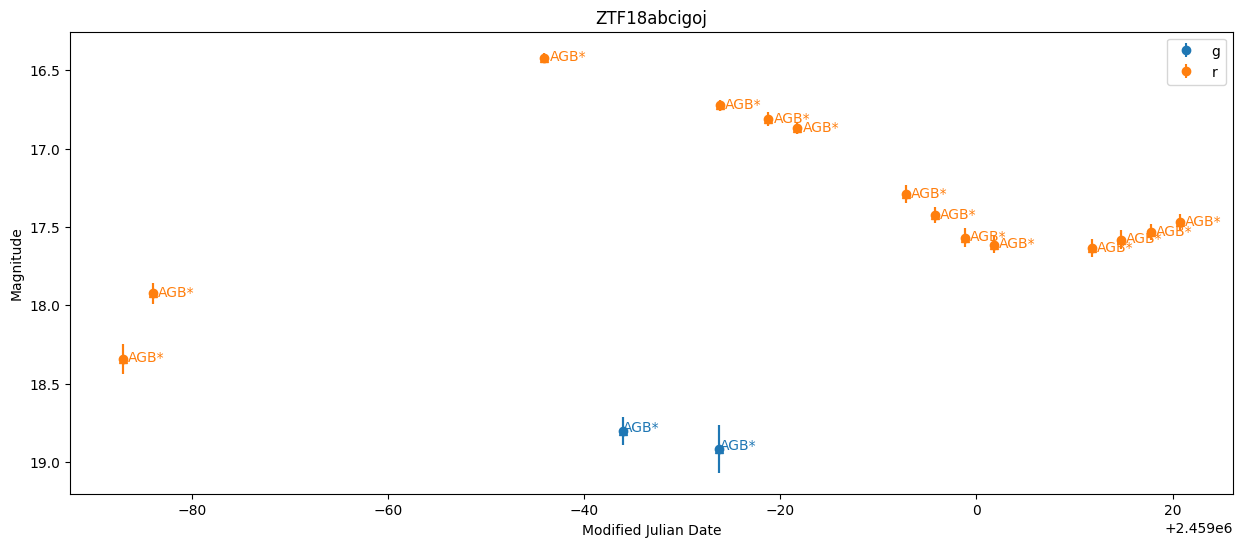

In [ ]:
plot_lc(df_alerts, 'ZTF18abcigoj')

In [ ]:
# Select the objectIds (transients) that have more than or equal to three alerts in atleast one passband/filter.
# Note that we mean more than three alerts in the time period in which the alerts are captured and not from the start of the survey.
# See notes above.
# For requiring three rather than two alerts, it's because if there are one or two alerts, you can fit anything to them with good accuracy.
# Only when you have three points or more, can we fit something meaningful.
df_alerts = df_alerts.groupby('objectId').filter(
    lambda group: (len(group[group['fid'] == 1]) >= 3) or (len(group[group['fid'] == 2]) >= 3)
)

print(f'{len(df_alerts)} alerts selected out of {df_alerts_shape[0]}')

for objectId in df_alerts['objectId'].unique():
    pdf = df_alerts[df_alerts['objectId'] == objectId]
    assert (len(pdf[pdf['fid'] == 1]) >= 3) or (len(pdf[pdf['fid'] == 2]) >= 3)

40910 alerts selected out of 121956


In [ ]:
df_alerts['objectId'].unique().shape

(8026,)

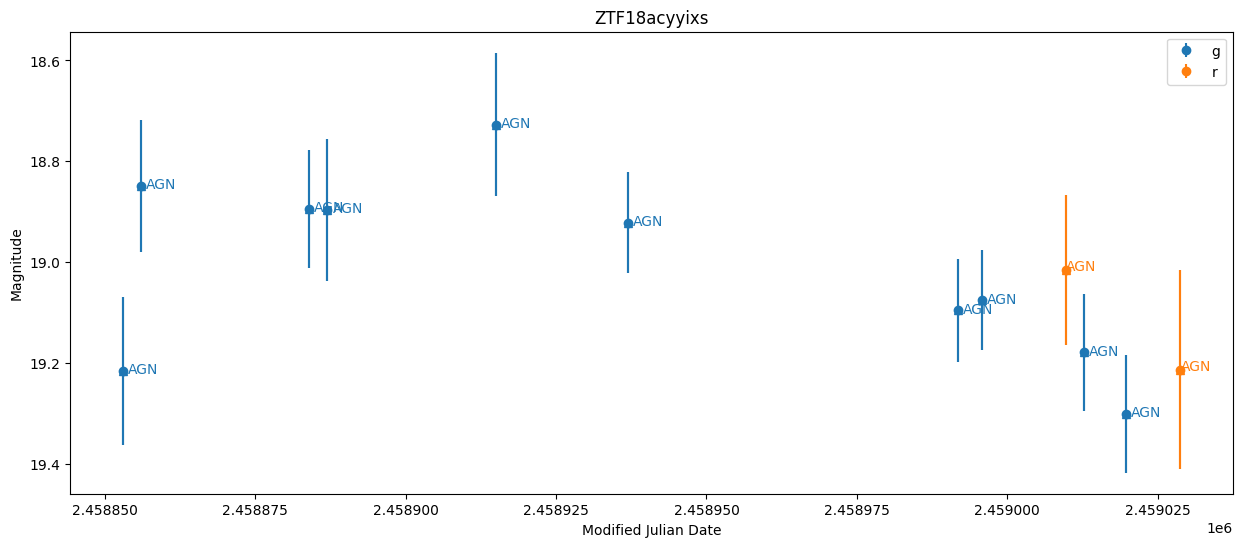

In [ ]:
# Plot an example transient.
# This is a MIRA star. See here: https://fink-portal.org/ZTF18adbipeq. If you observe, the observations started in Jan 2020 and going up to 2024.
# Since we have data from Jan to June 2020, we only see a part of the variable star. That's a challenge!
plot_lc(df_alerts, transient_name)

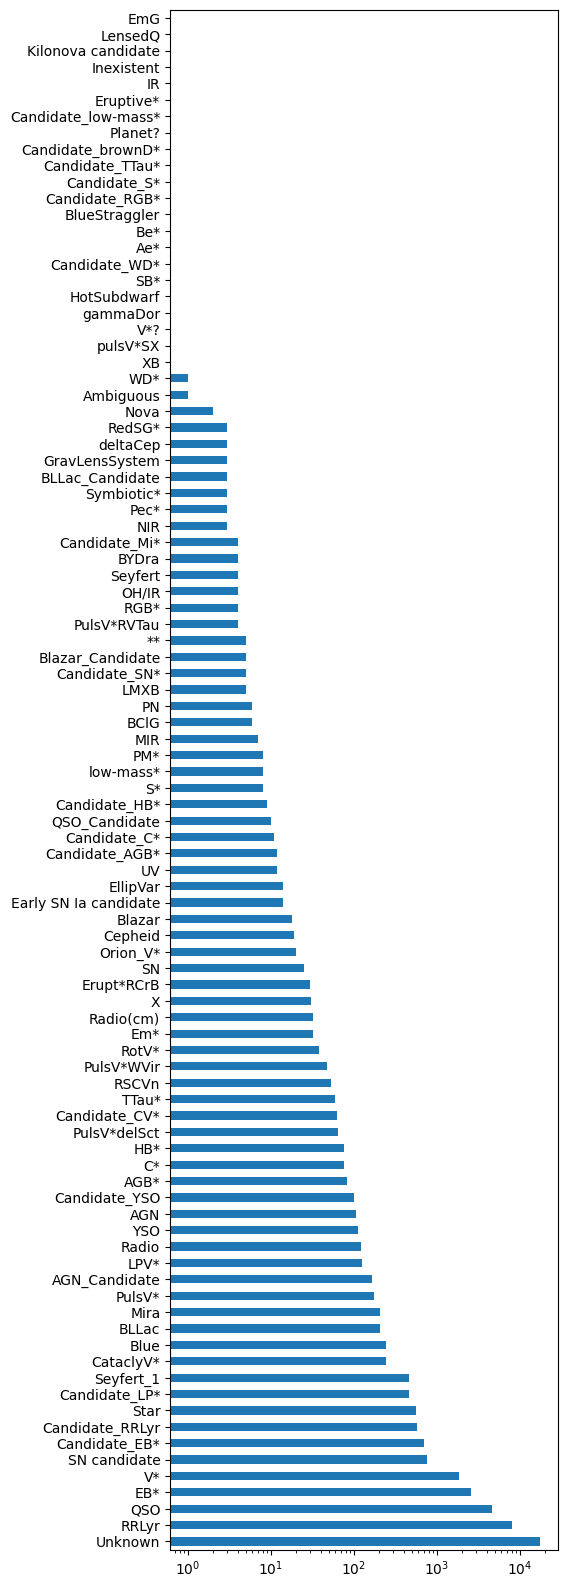

In [ ]:
# Now see the distribution of the fink classes out of those selected finally.
fig, ax = plt.subplots(1, 1, figsize=(5, 20))
df_alerts['finkclass'].value_counts().plot(kind='barh', ax=ax)
ax.set_xscale('log')

Plot locations of all alerts.

Text(0, 0.5, 'dec')

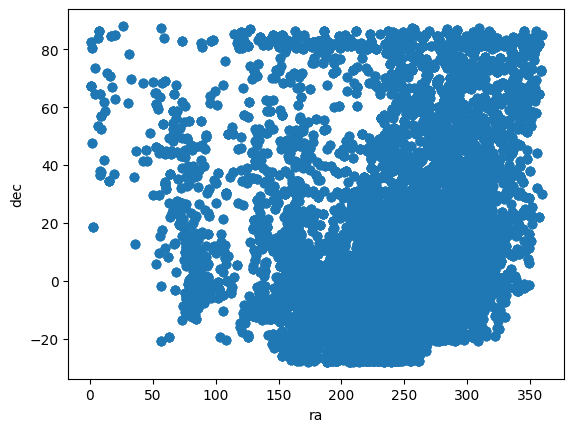

In [ ]:
# TODO: See if all alerts for a given objectId have the same position? Must be. What's the maximum coordinate error for different alerts of the same transient?
fig, ax = plt.subplots(1, 1)
ax.scatter(df_alerts['ra'], df_alerts['dec'])
ax.set_xlabel('ra')
ax.set_ylabel('dec')

For the same objectId, are there more than one unique Fink classes?

In [ ]:
print('These objectIds contain alerts with atleast two having more than one fink class')
for objectId in df_alerts['objectId'].unique():
    pdf = df_alerts[df_alerts['objectId'] == objectId]
    num_unique_fink_classes = len(pdf['finkclass'].unique())
    if num_unique_fink_classes > 1:
        print(f'{objectId} has these fink classes: {pdf["finkclass"].tolist()}')

These objectIds contain alerts with atleast two having more than one fink class
ZTF20aasiwqp has these fink classes: ['BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Unknown']
ZTF19abtugnm has these fink classes: ['BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'Unknown', 'Unknown']
ZTF19acpmsjk has these fink classes: ['BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'SN candidate']
ZTF19aavvlvr has these fink classes: ['BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'BLLac', 'Radio', 'Radio', 'Radio']
ZTF19aadfuku has these fink classes: ['BLLac', 'BLLac', 'Blue', 'Blue', 'Blue', 'Blue', 'Blue']
ZTF17aabwktk has these fink classes

In [ ]:
df_alerts_kilonova = df_alerts[df_alerts['finkclass'] == 'Kilonova candidate']
for objectId in df_alerts_kilonova['objectId'].unique():
    df_alerts_kilonova_objectId = df_alerts_kilonova[df_alerts_kilonova['objectId'] == objectId]
    plot_lc(df_alerts_kilonova_objectId, name=objectId)

TODO: (old comment) Why are such transients as above (that only have 2 detections) included in the sample? I had excluded those above..need to check

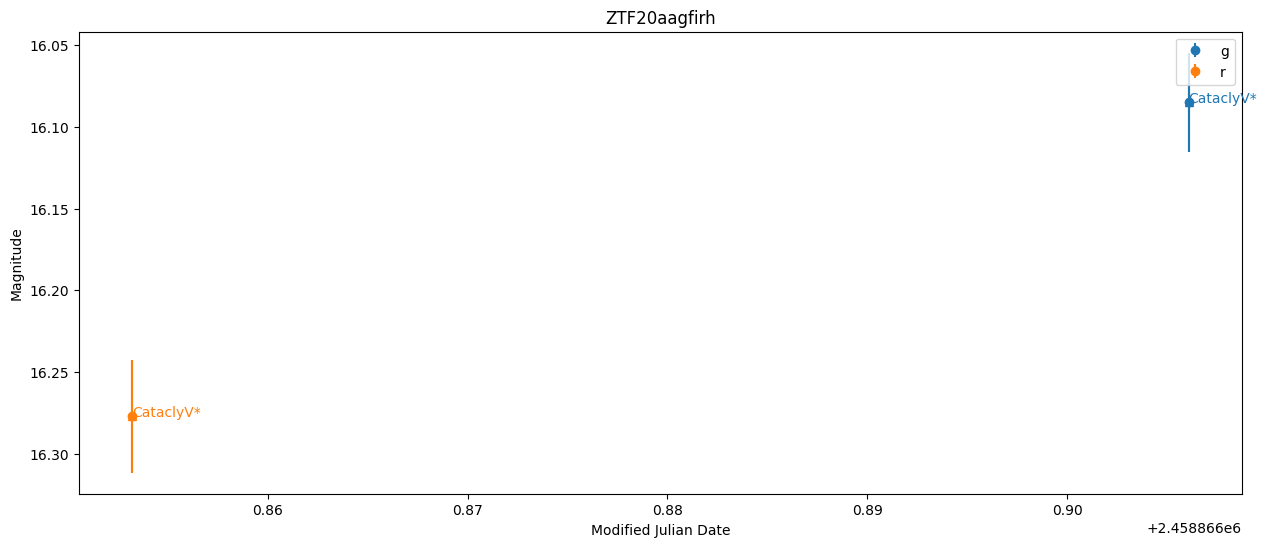

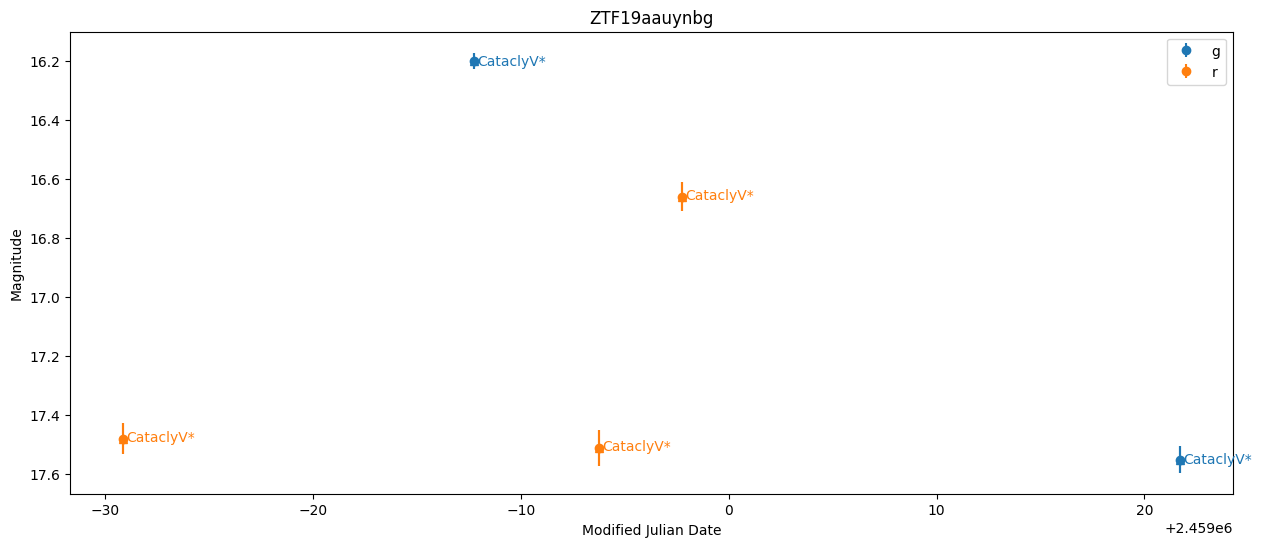

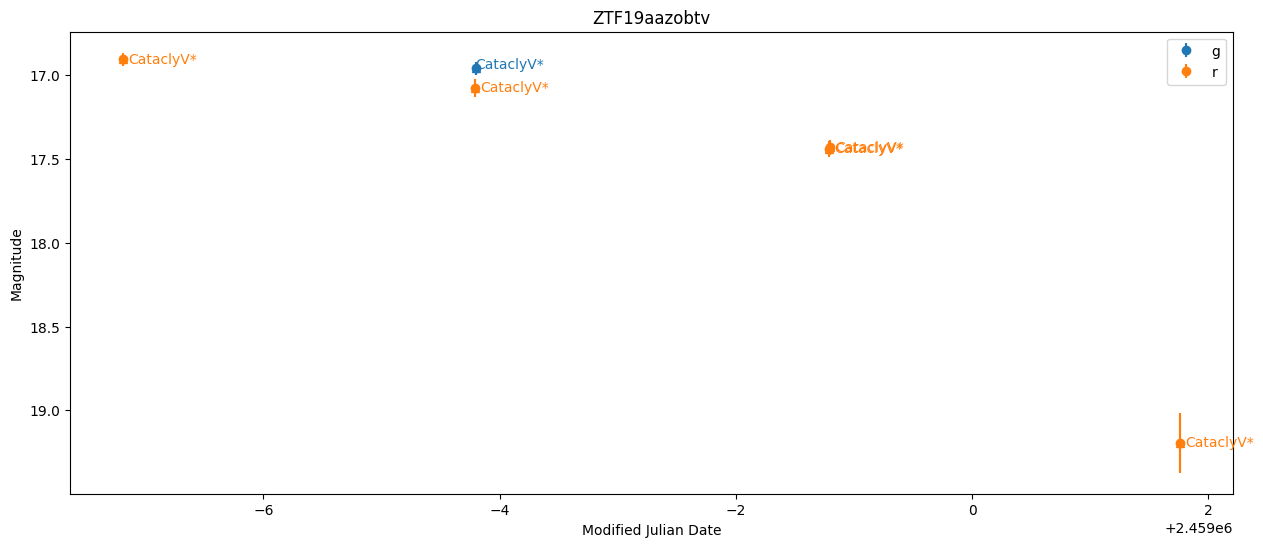

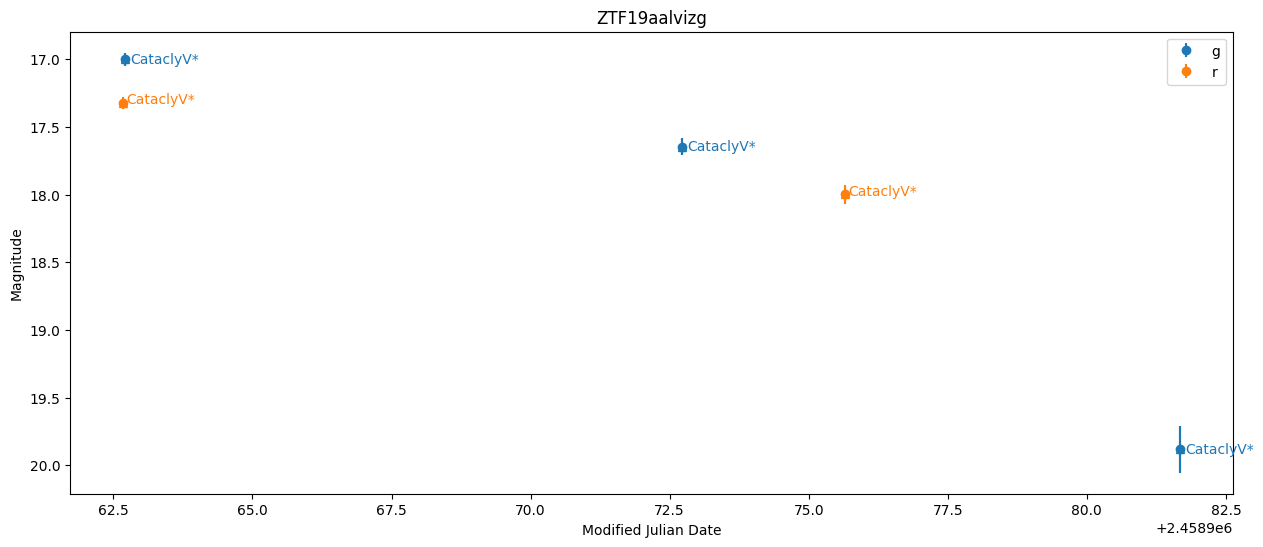

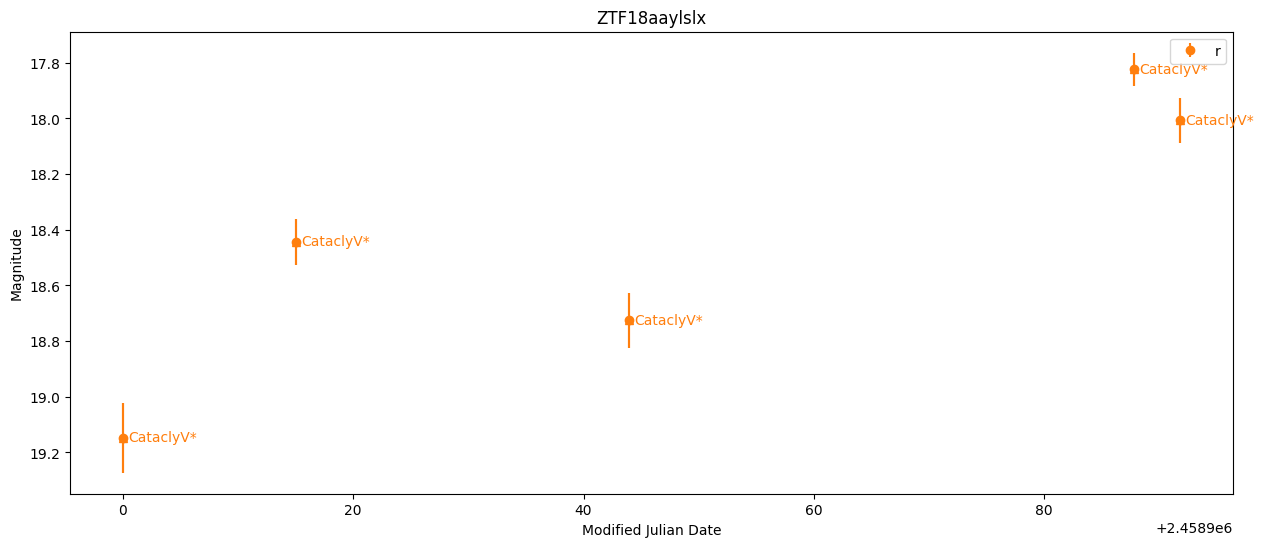

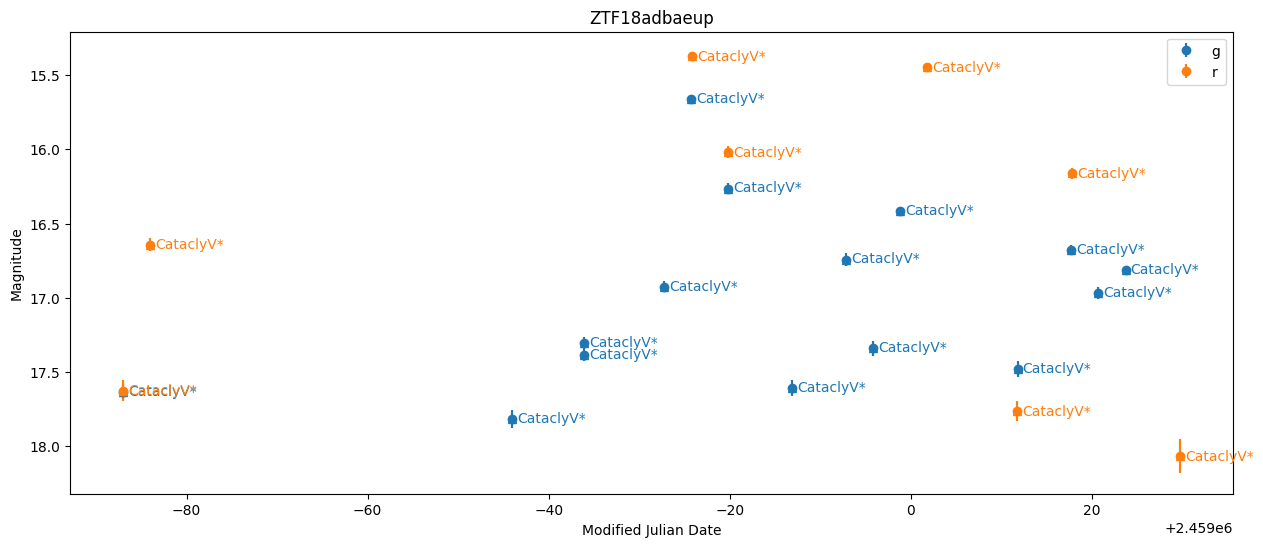

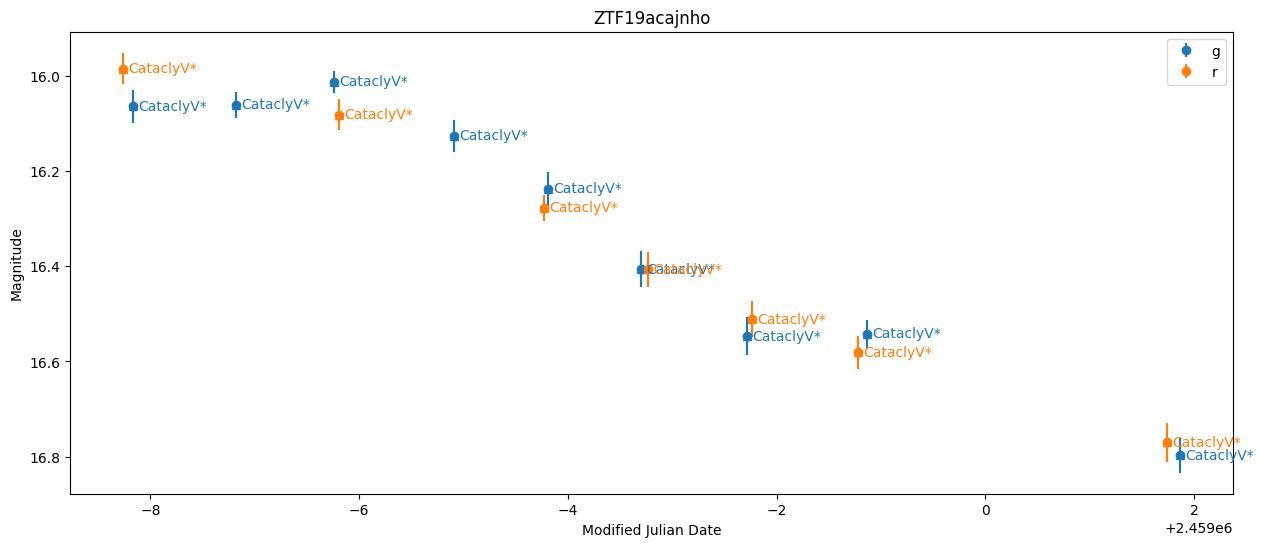

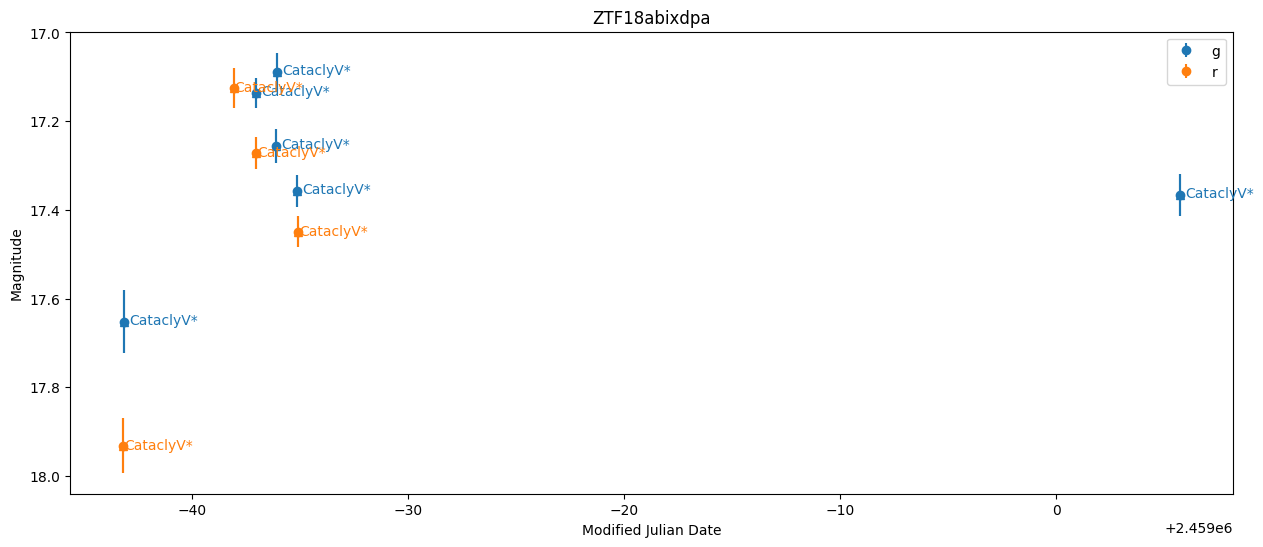

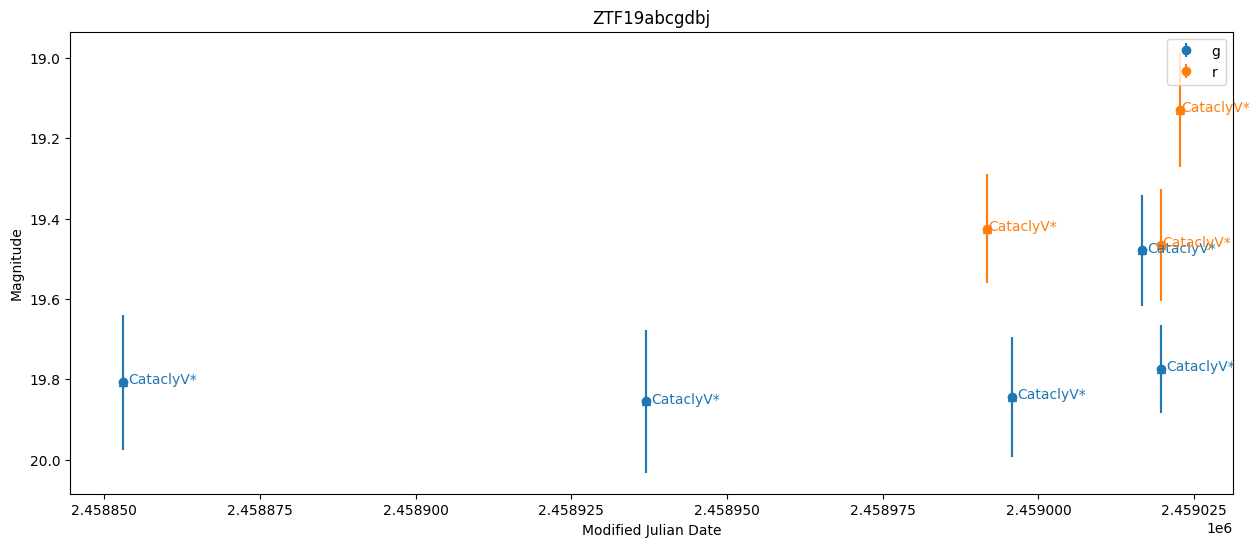

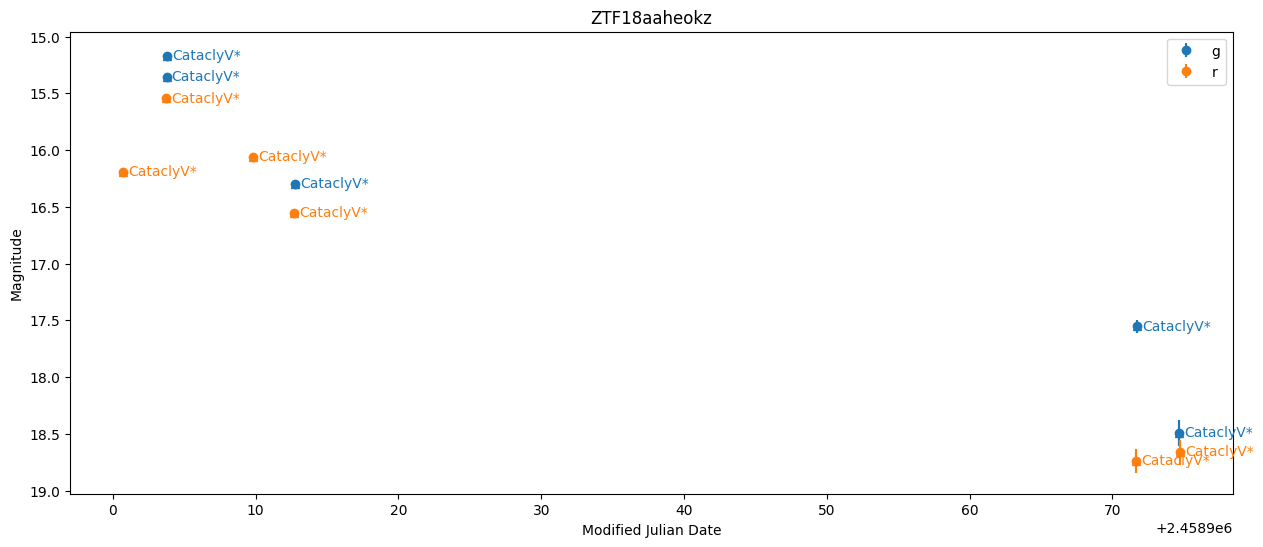

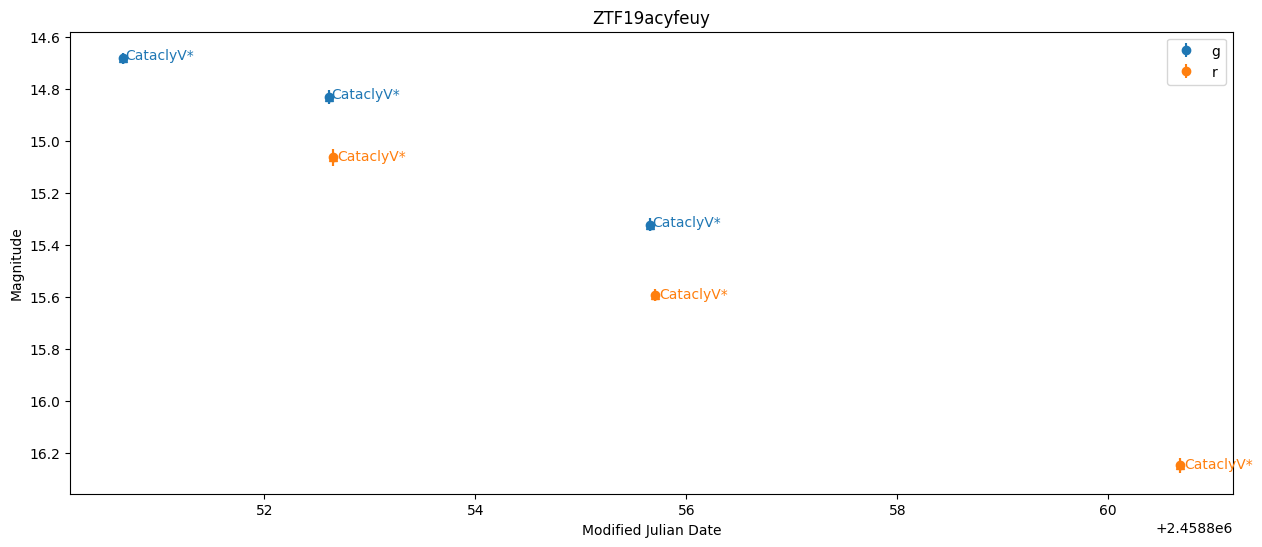

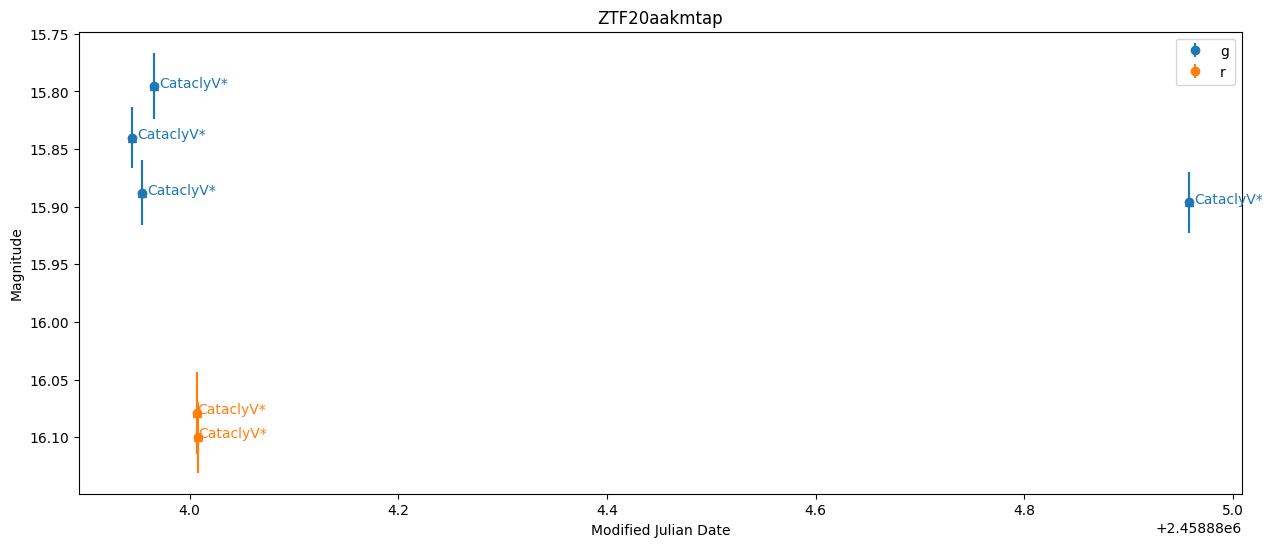

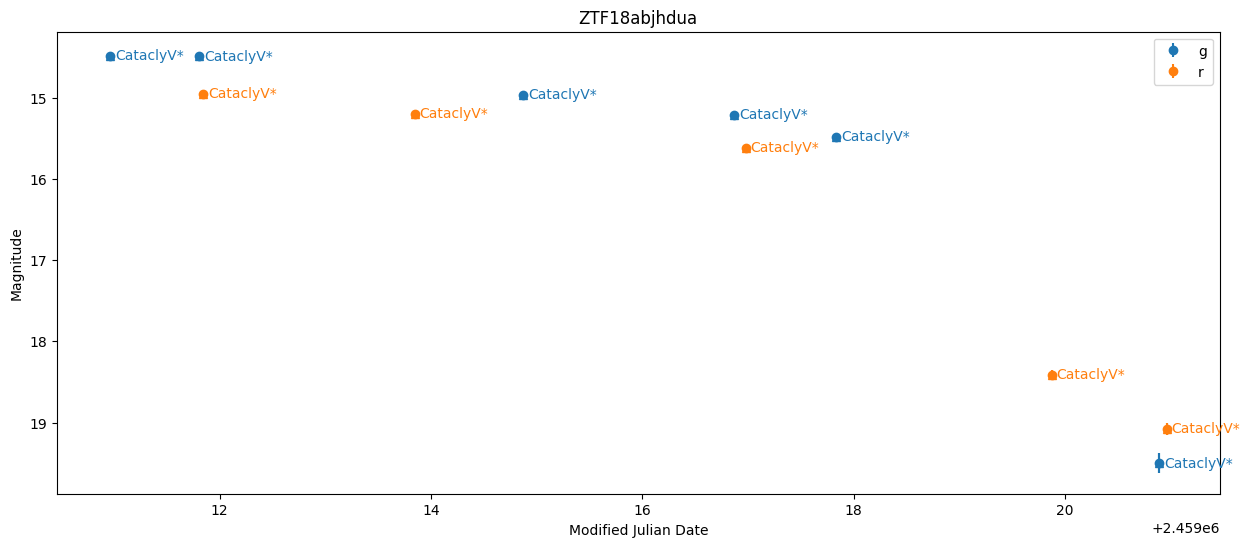

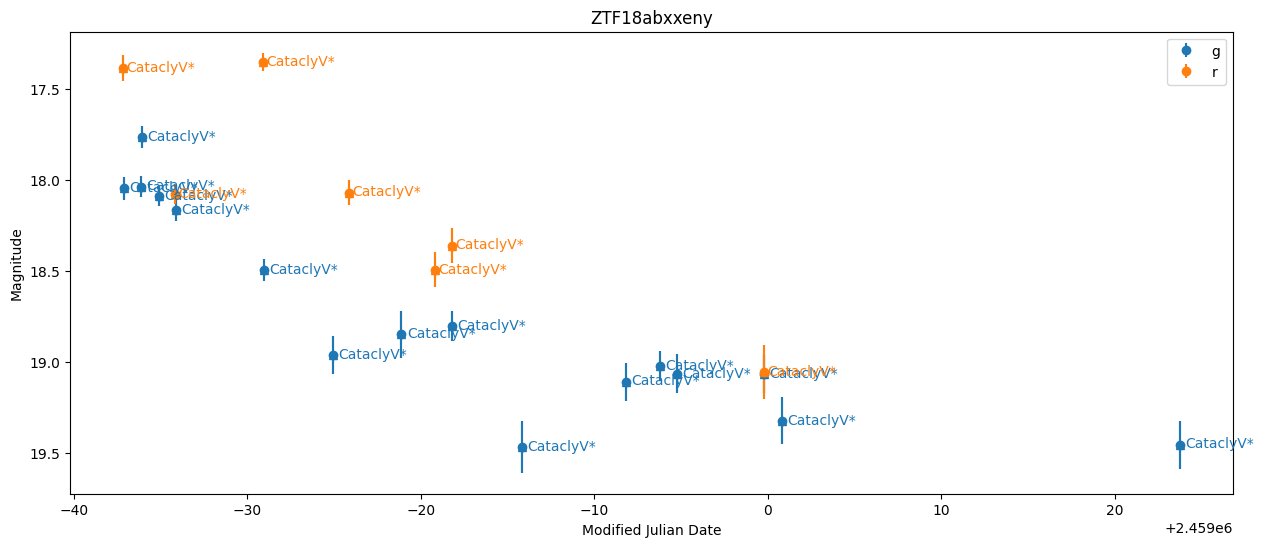

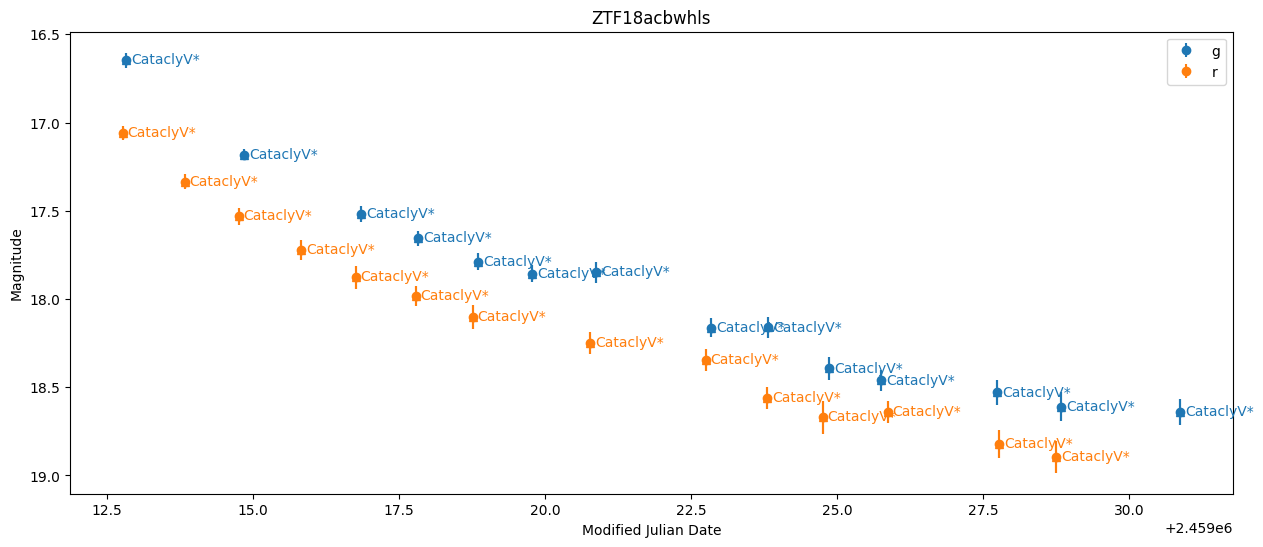

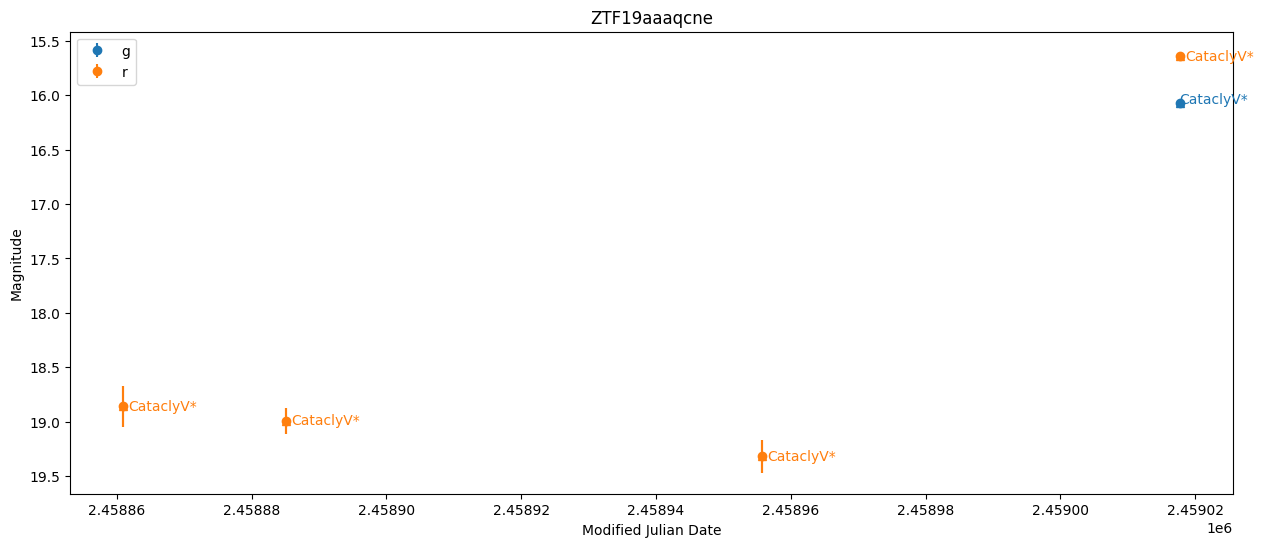

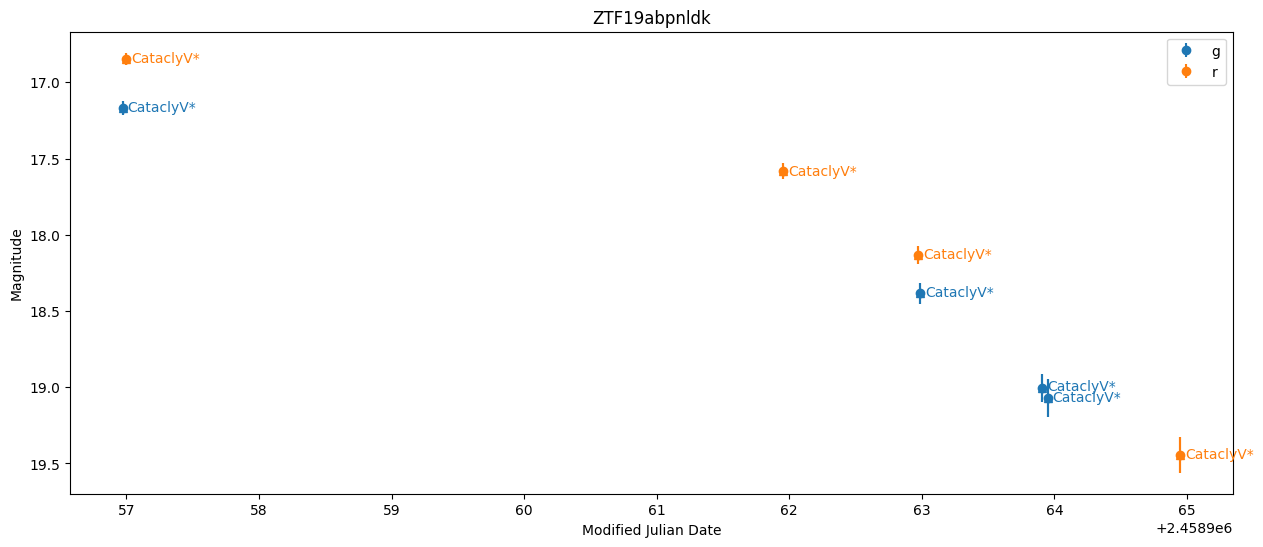

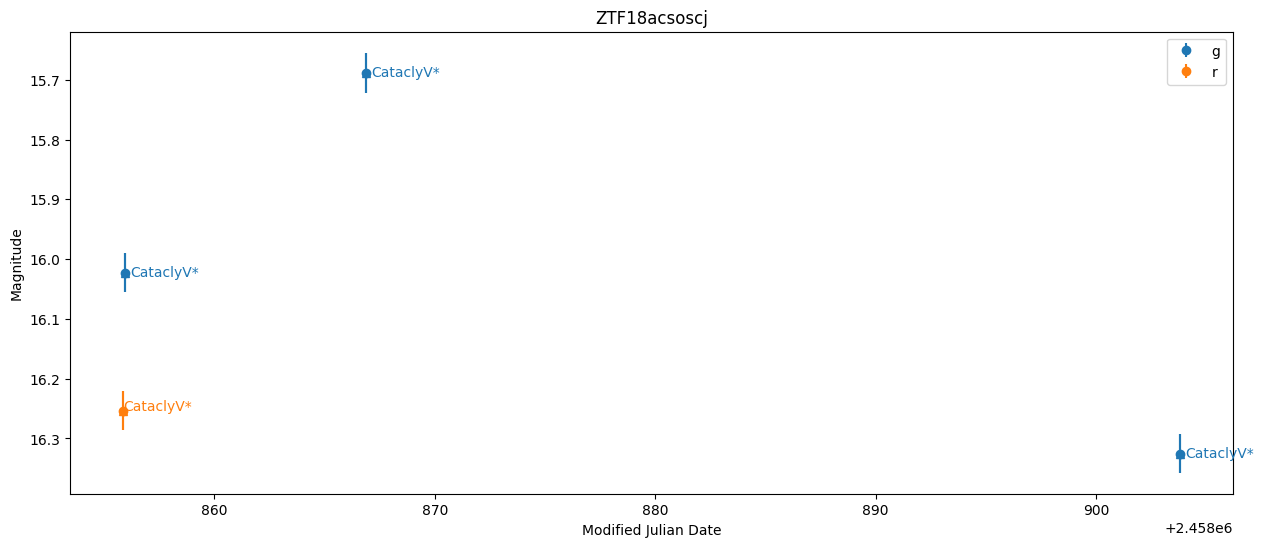

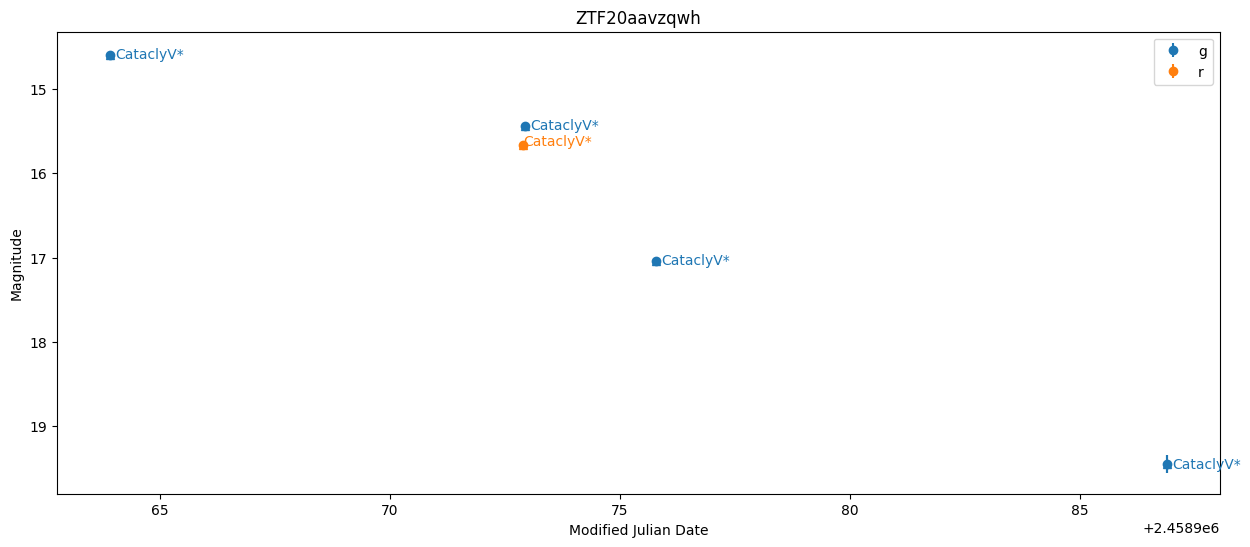

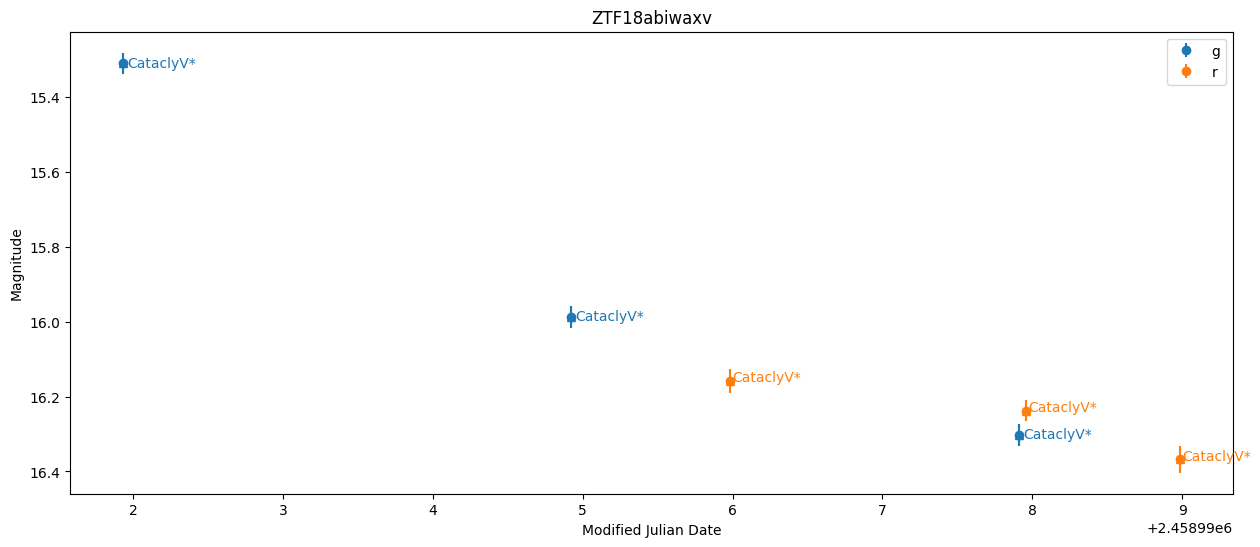

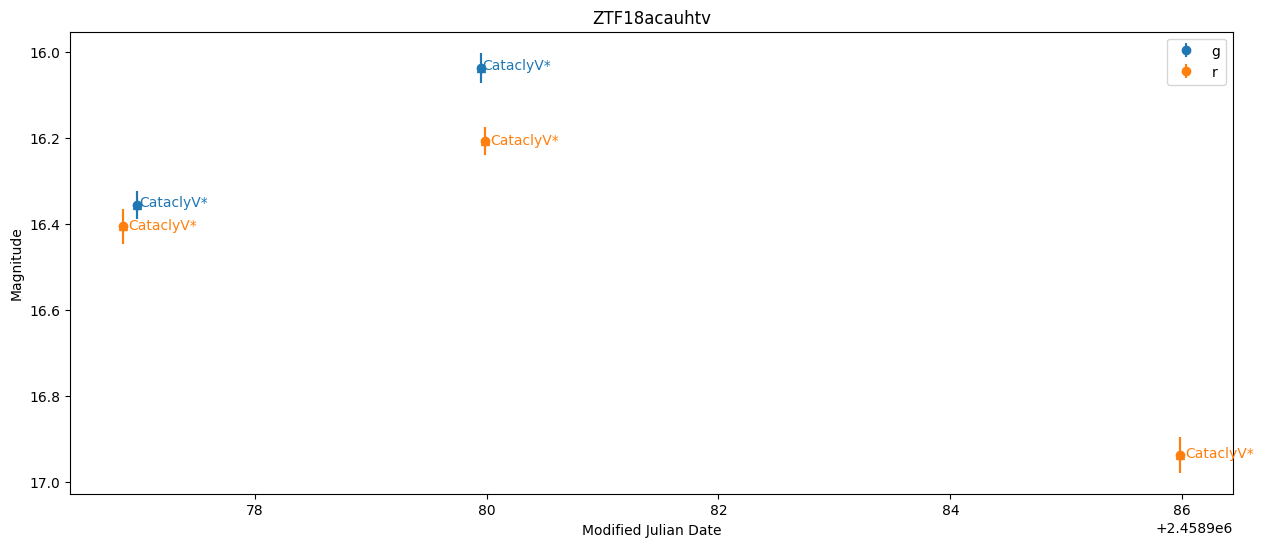

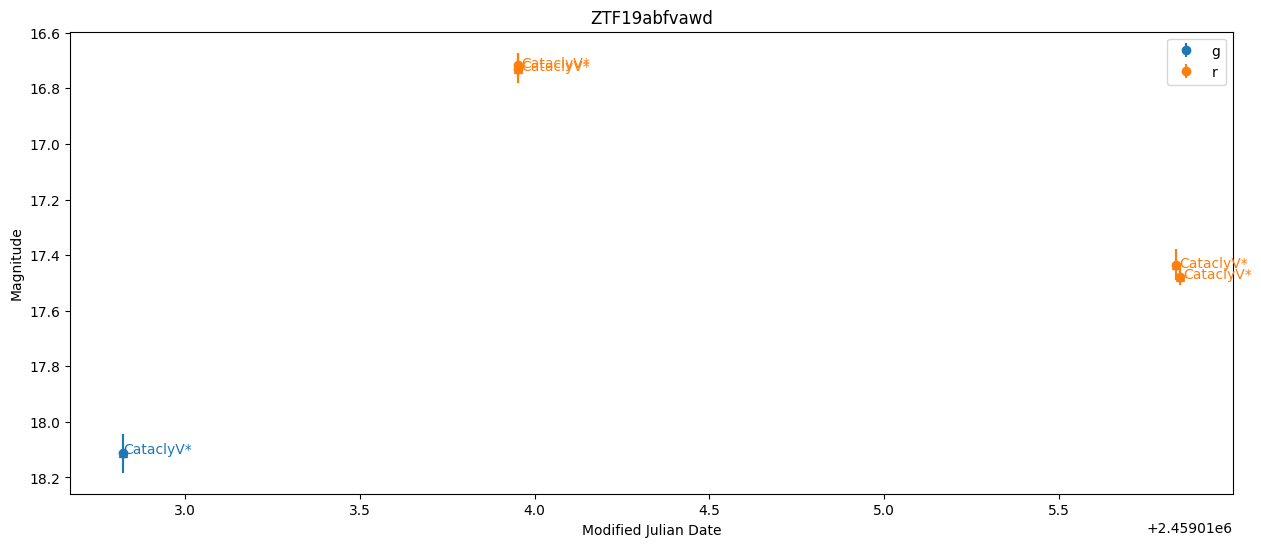

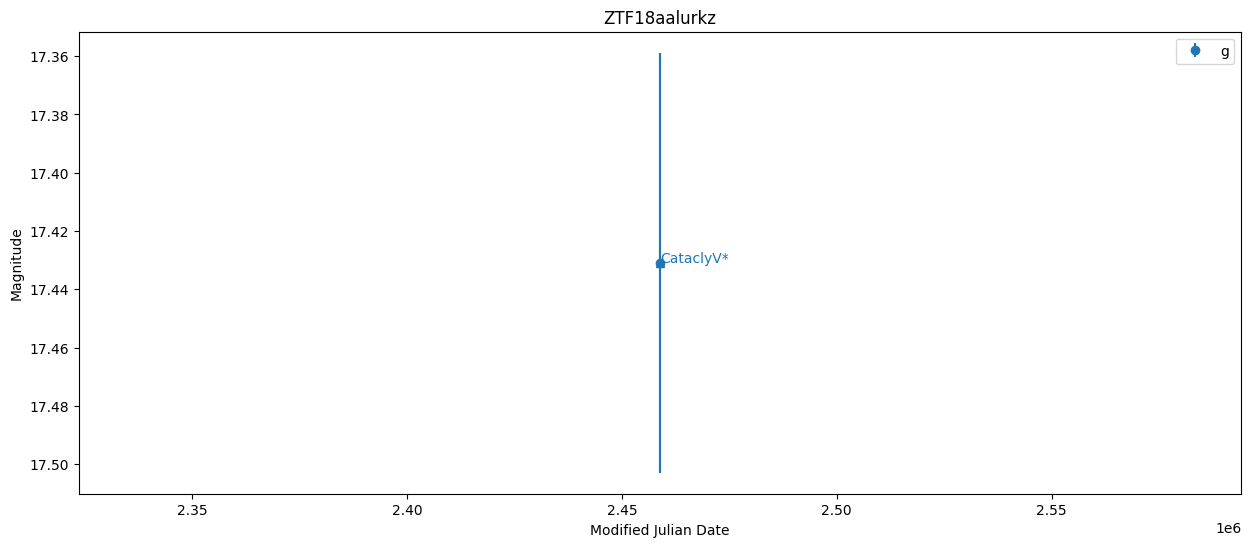

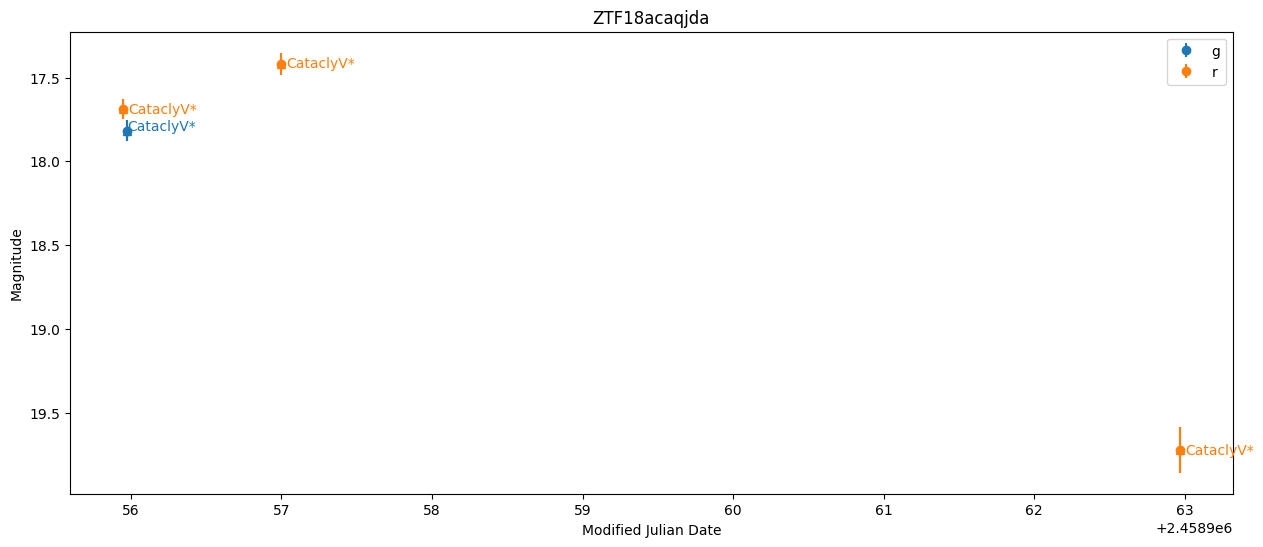

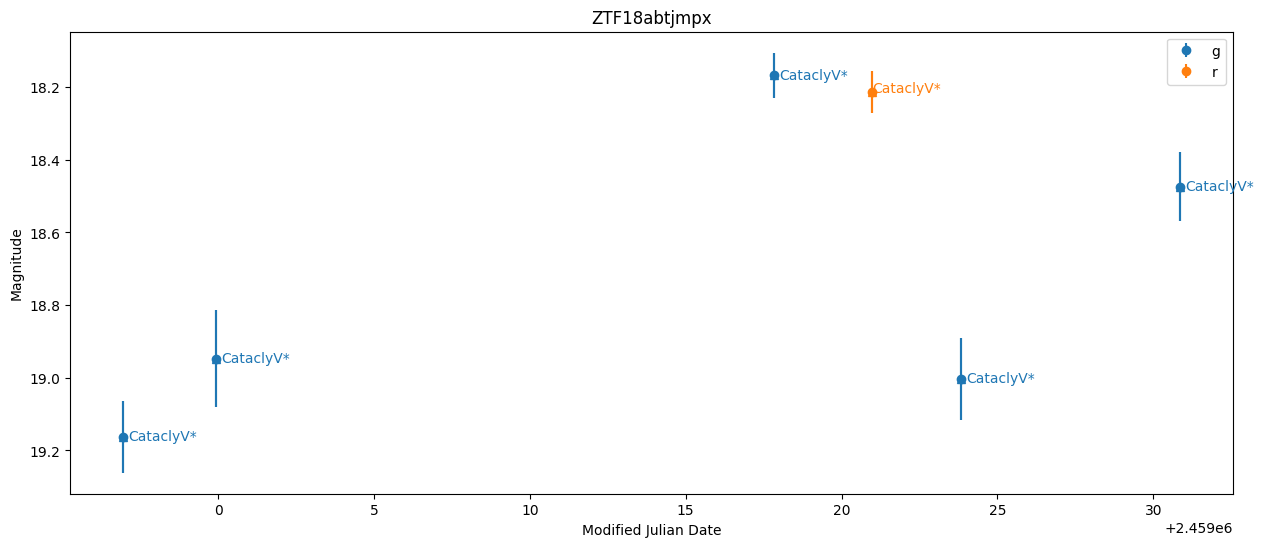

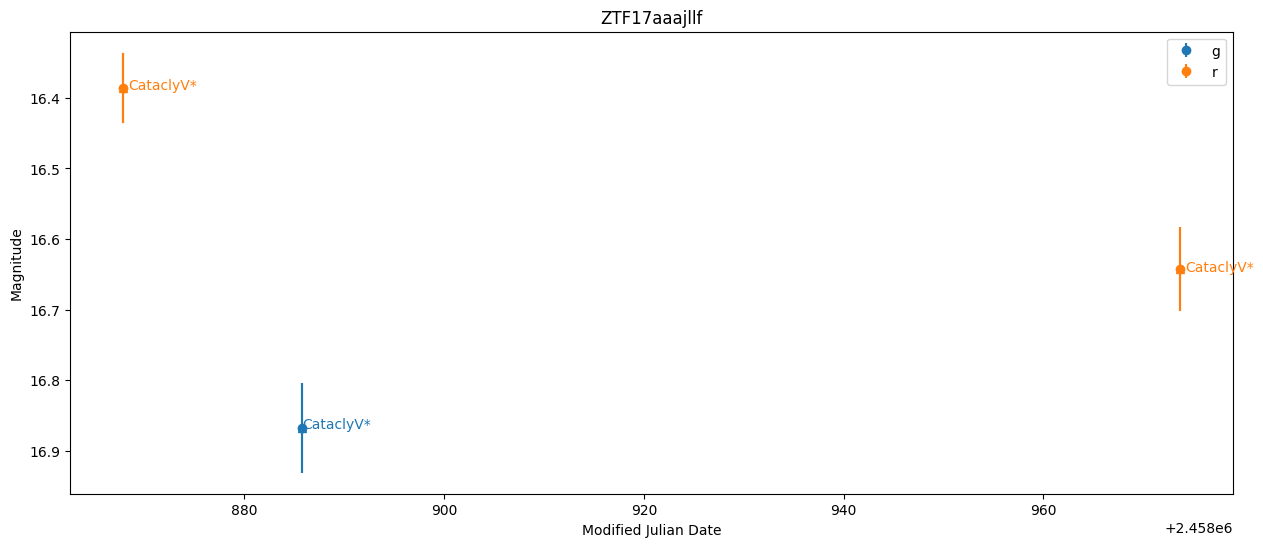

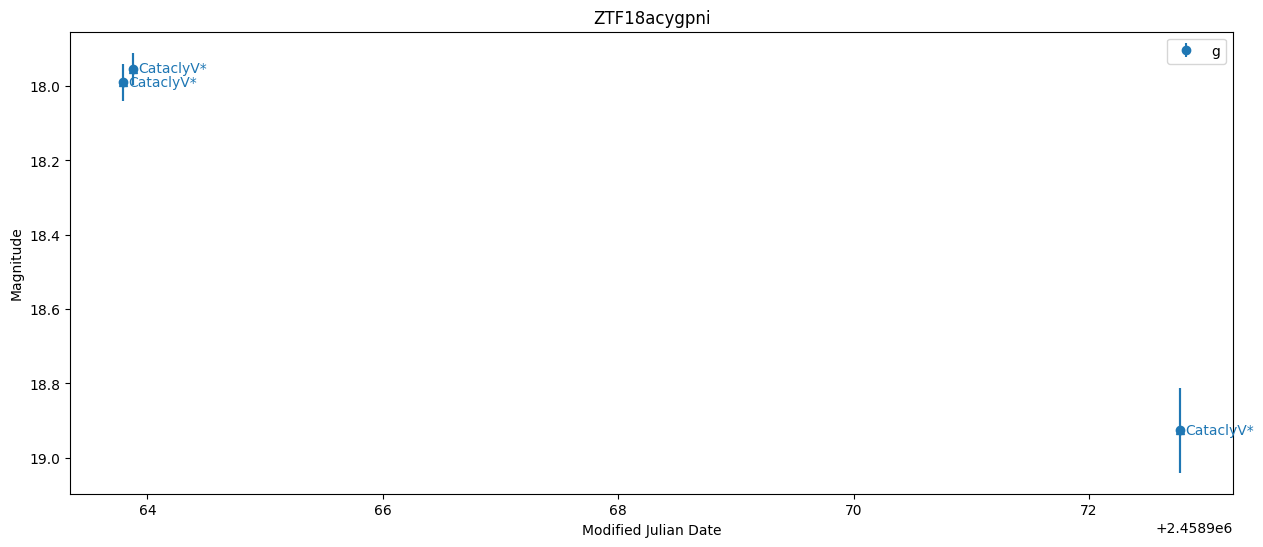

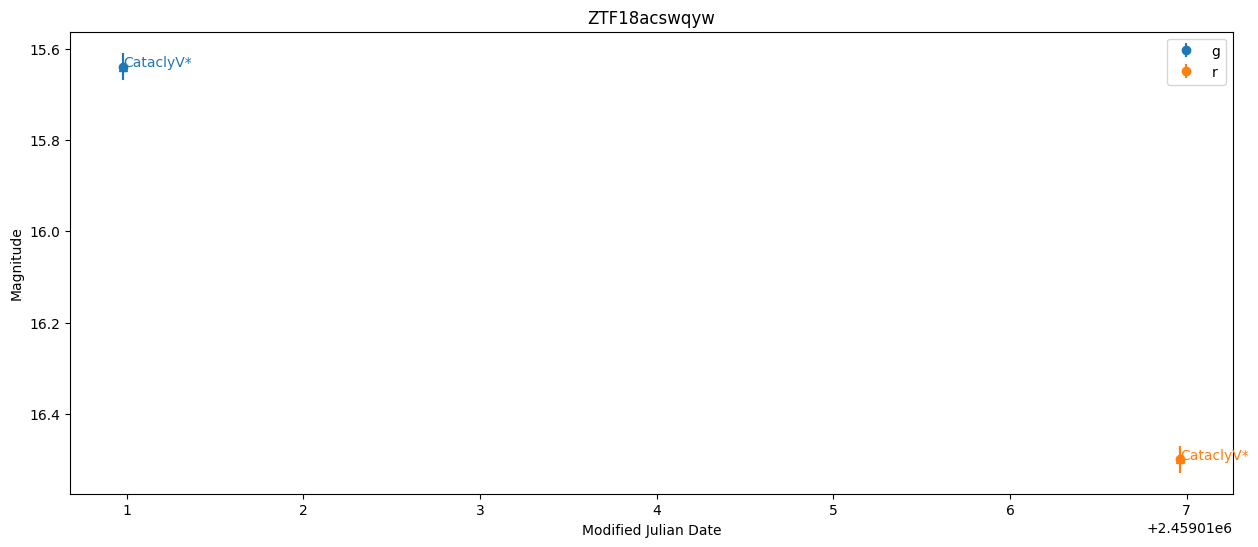

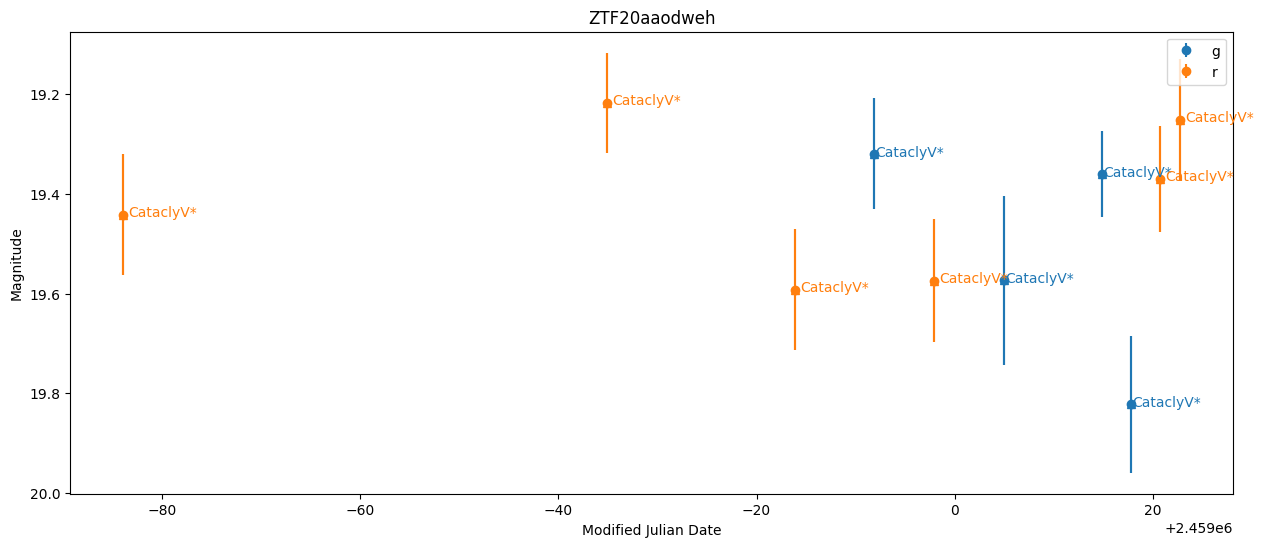

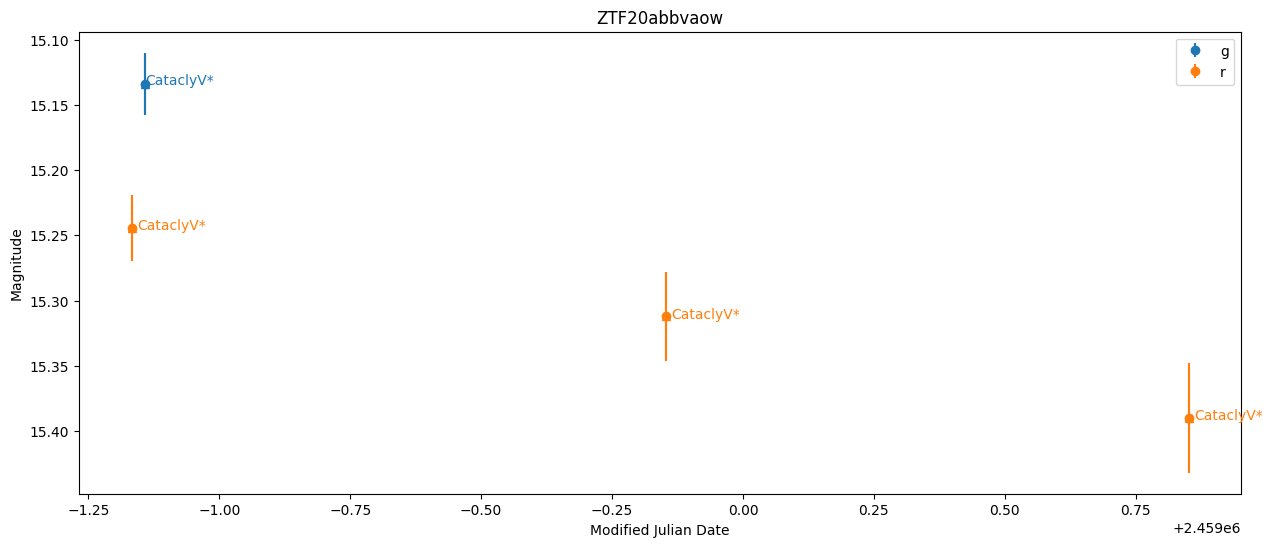

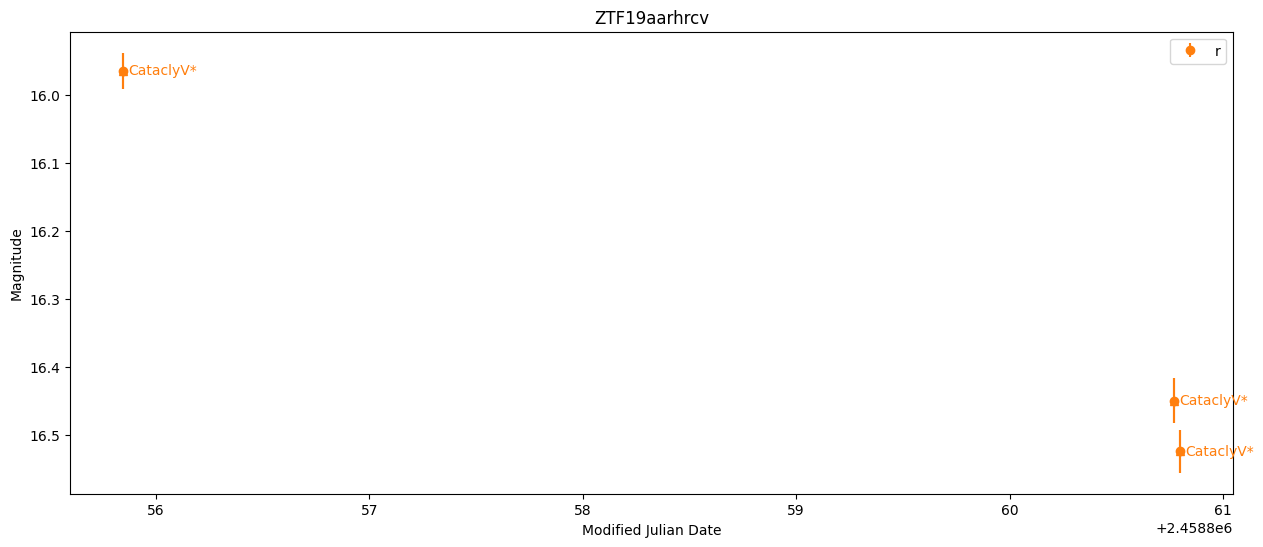

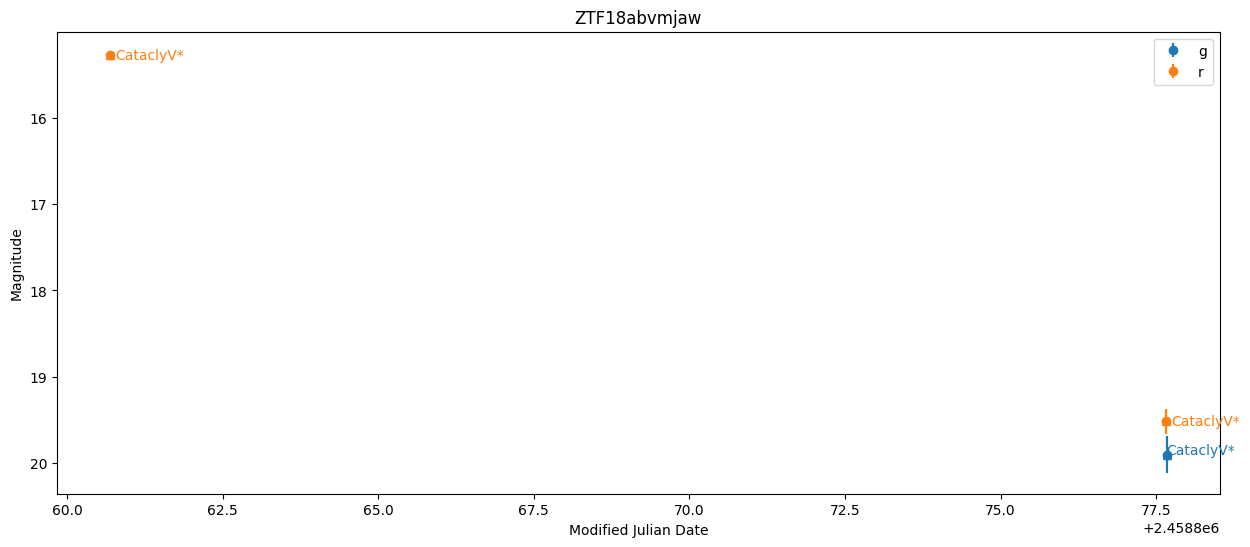

In [ ]:
df_alerts_cv = df_alerts[df_alerts['finkclass'] == 'CataclyV*']
for objectId in df_alerts_cv['objectId'].unique():
    df_alerts_cv_objectId = df_alerts_cv[df_alerts_cv['objectId'] == objectId]
    plot_lc(df_alerts_cv_objectId, name=objectId)

`ZTF18abxxeny`, for example (and many other CV light curves), show small bumps, which could be superhumps. Superhumps need to be periodic; however, it's difficult to note periodicity from this plot?

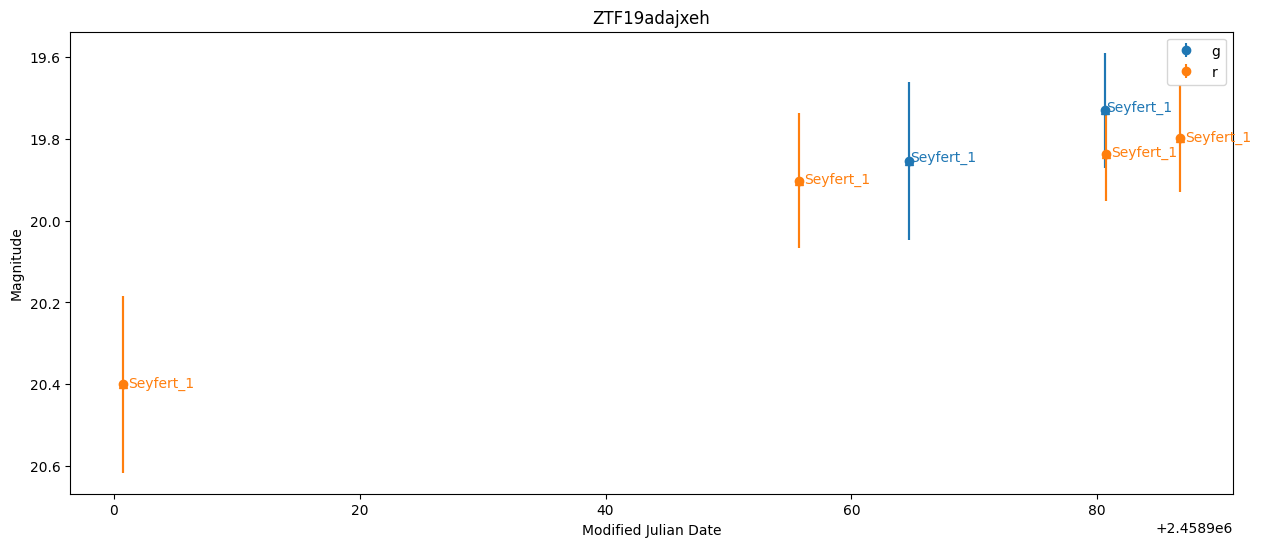

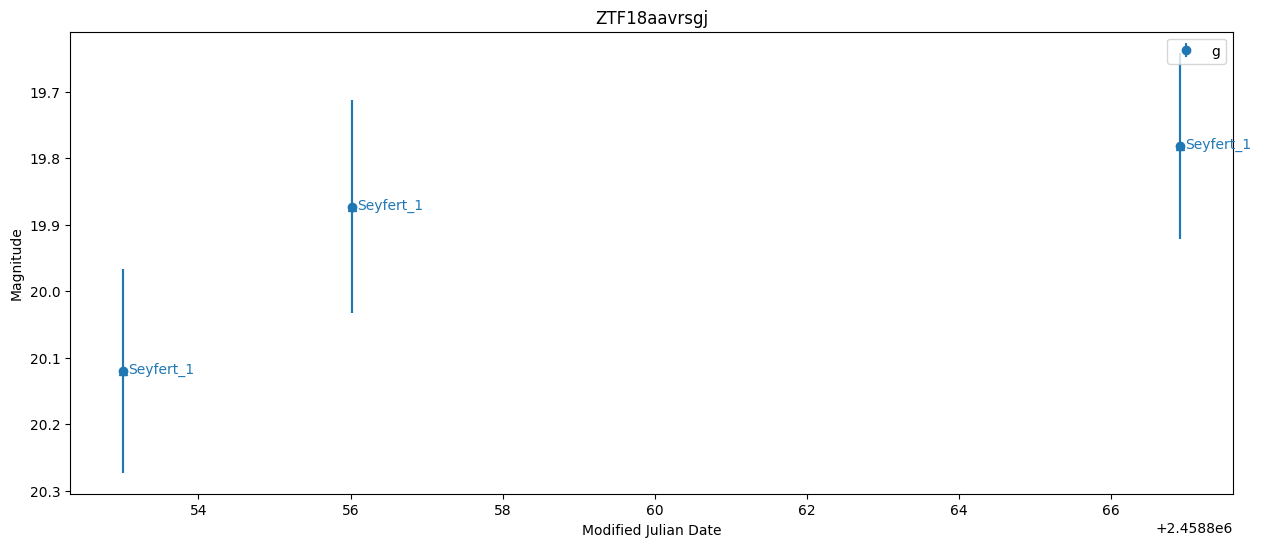

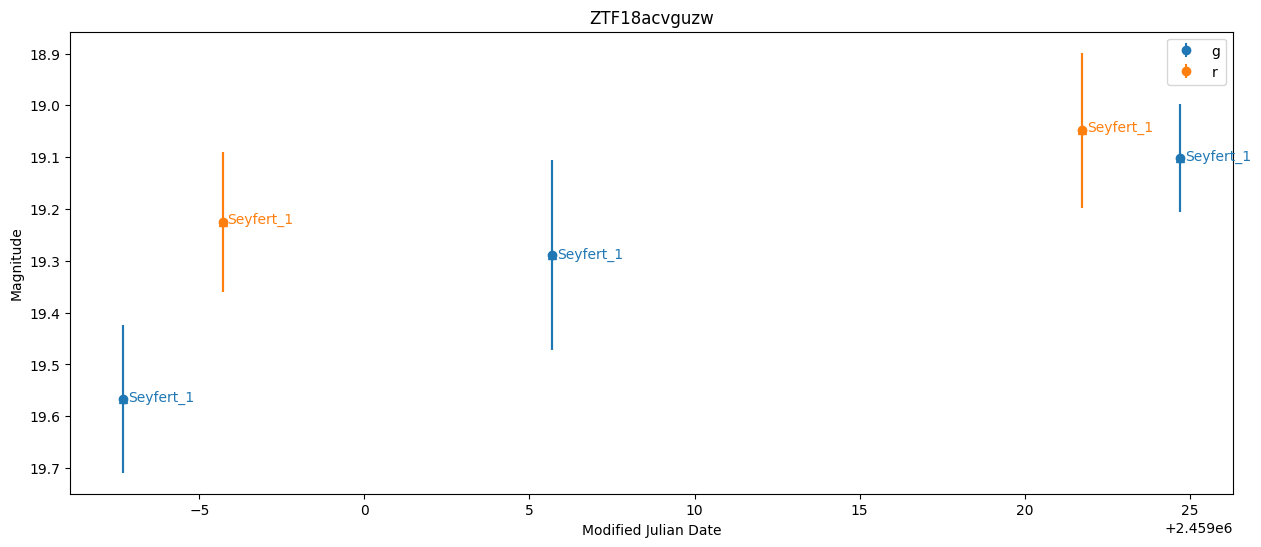

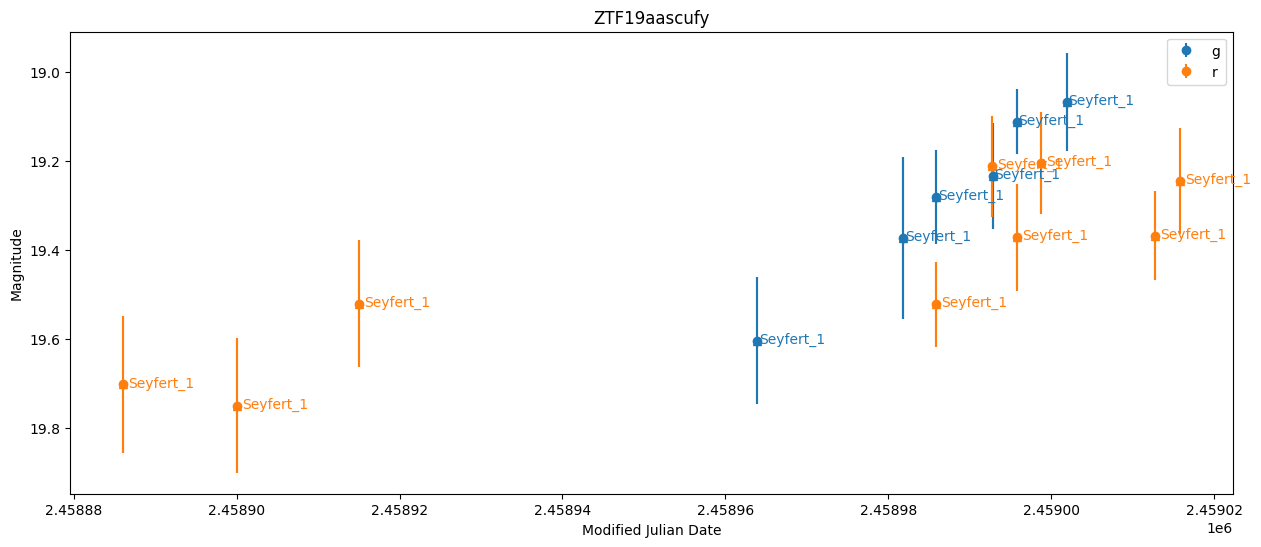

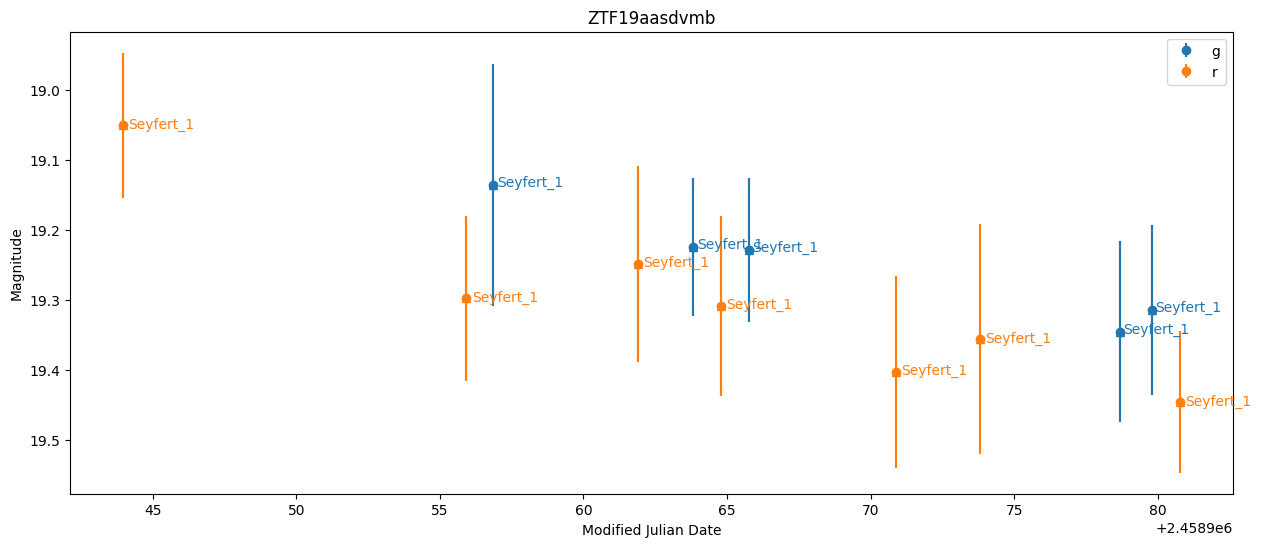

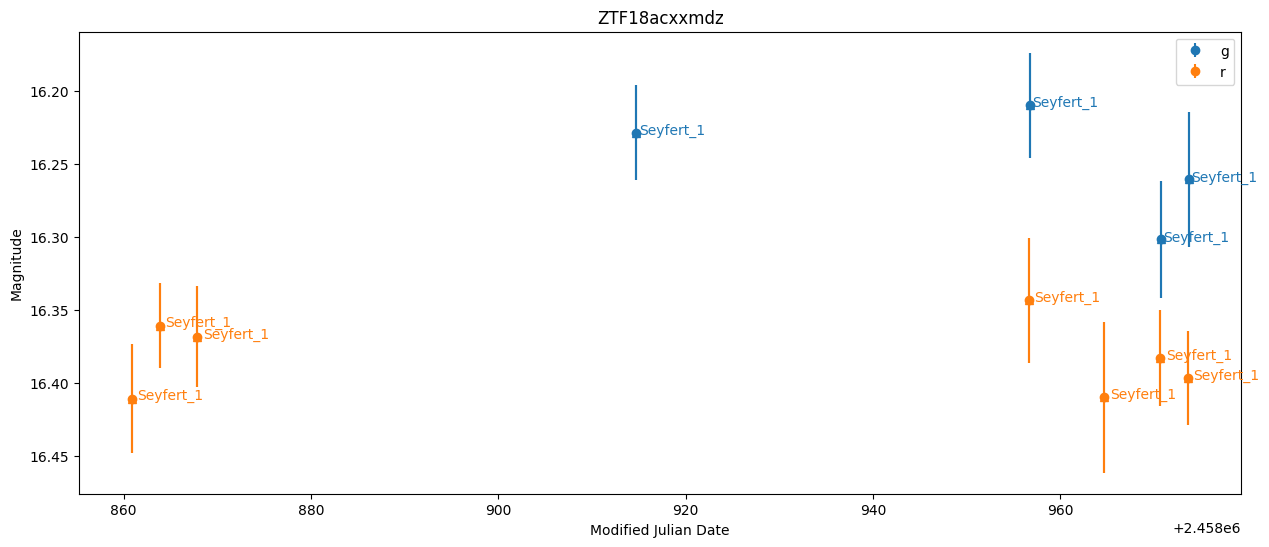

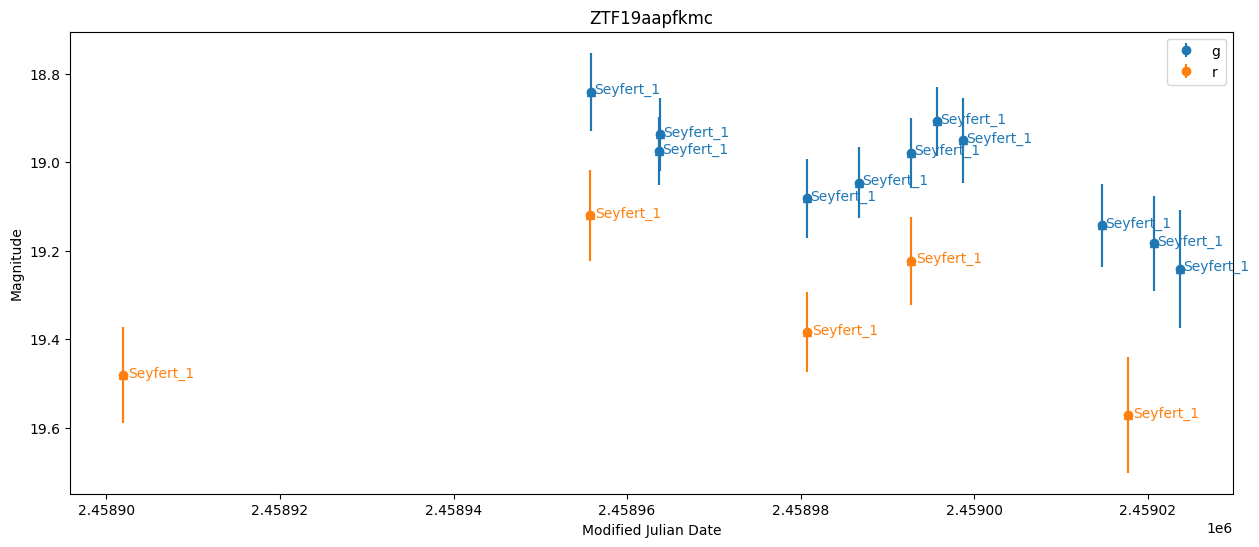

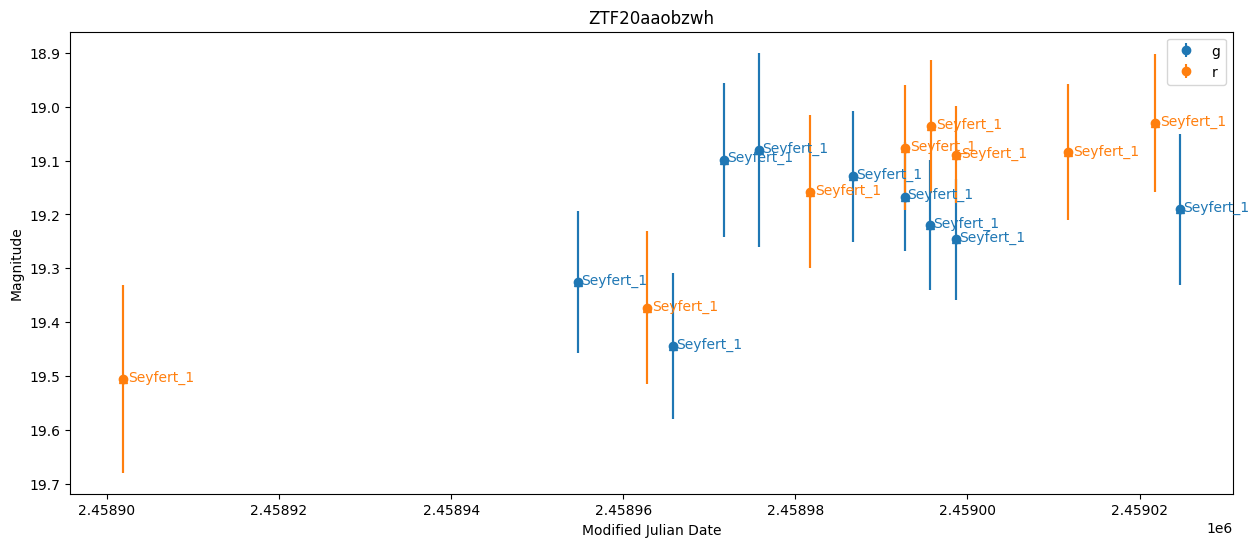

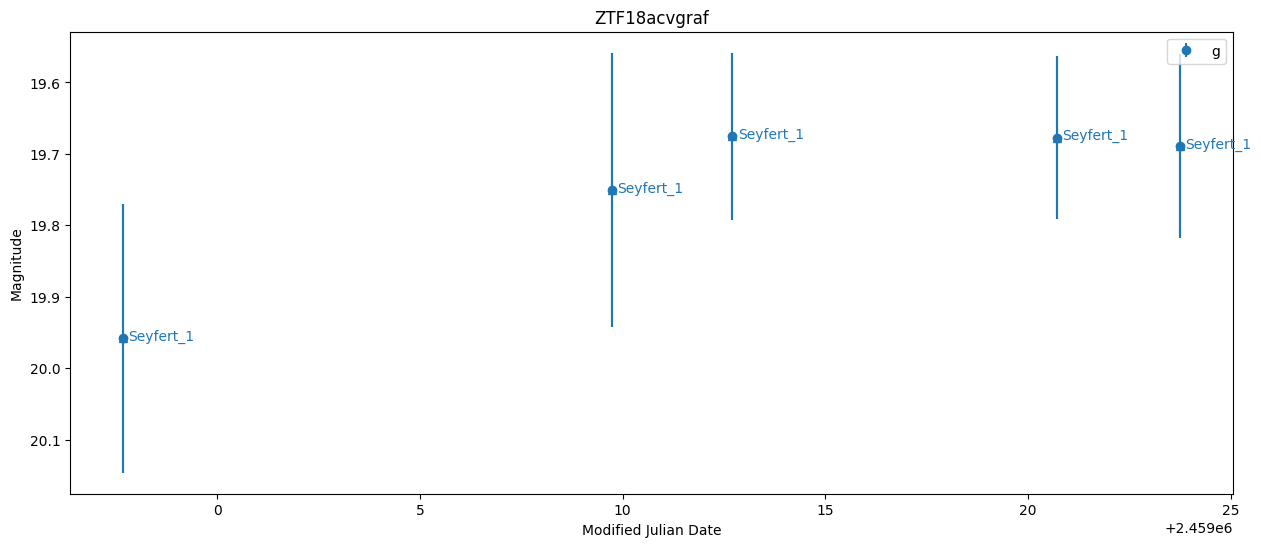

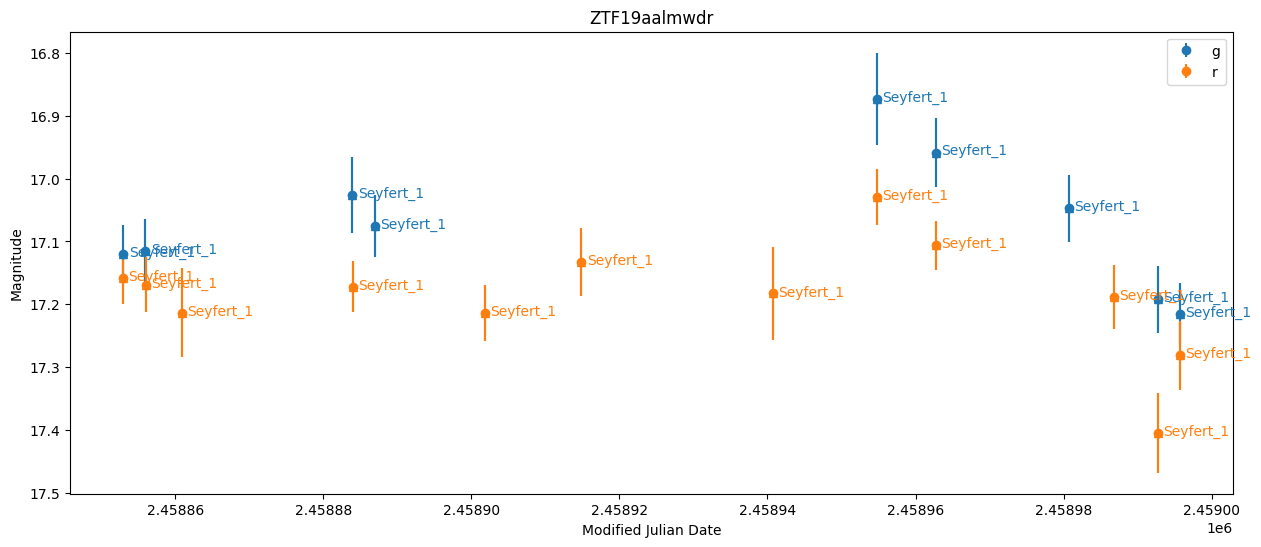

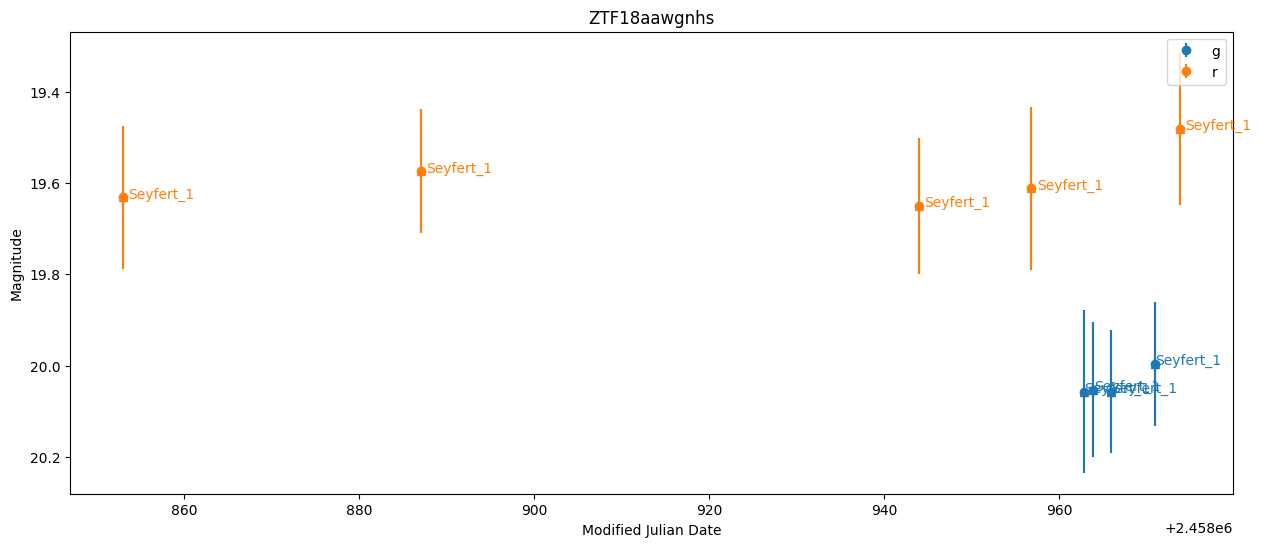

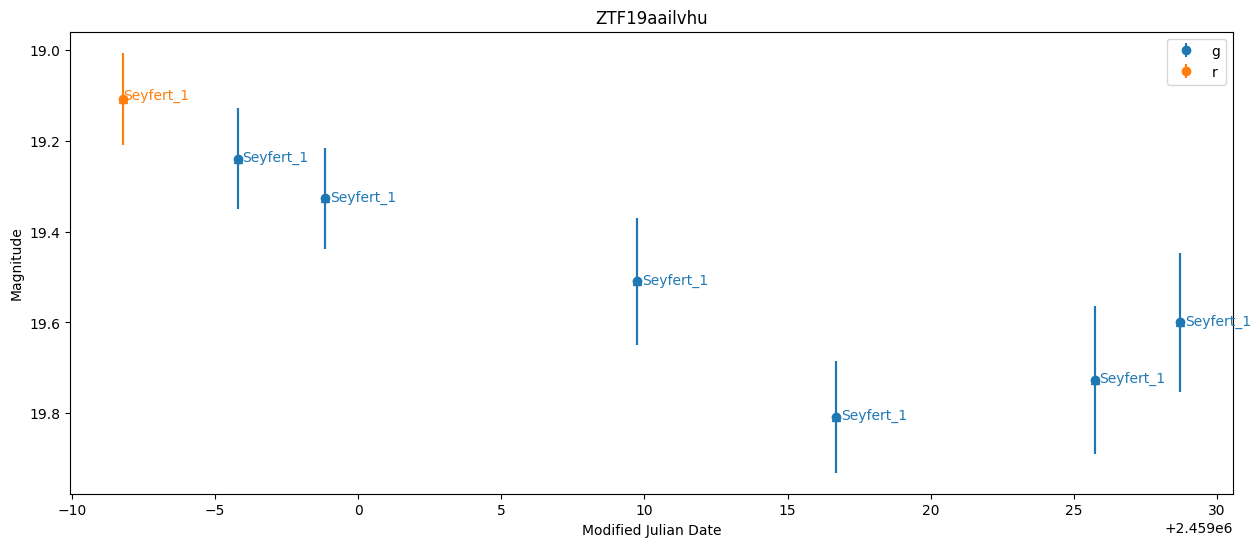

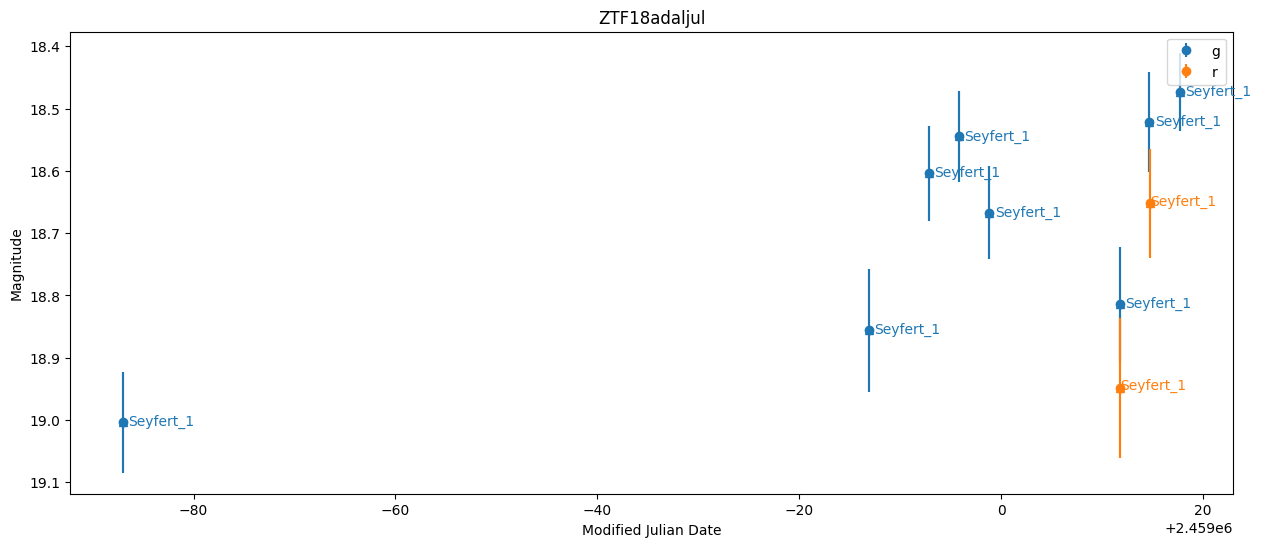

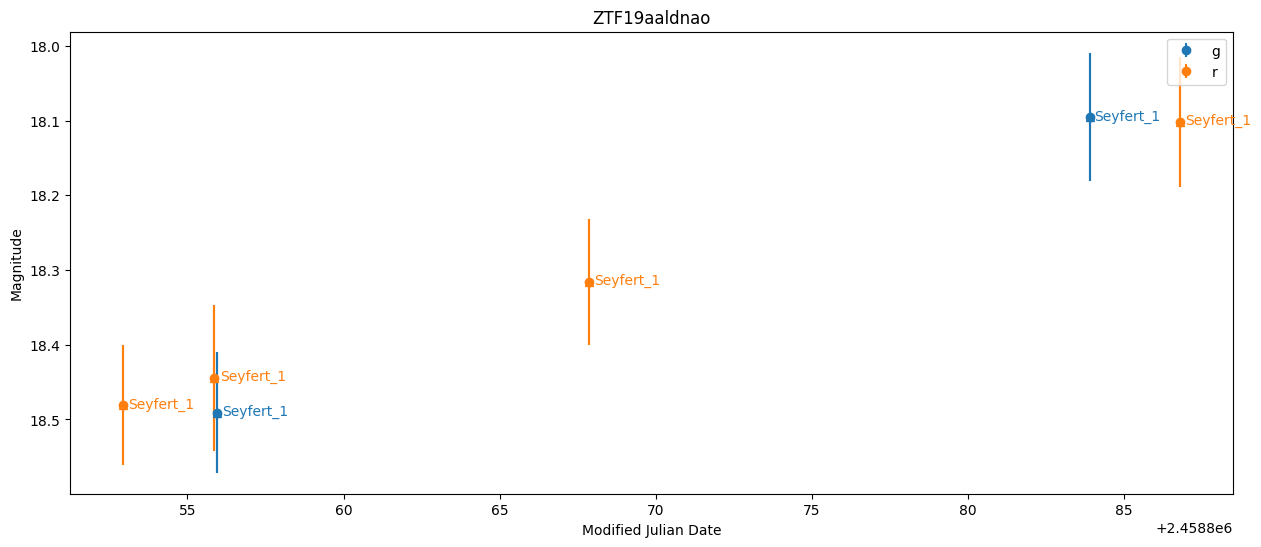

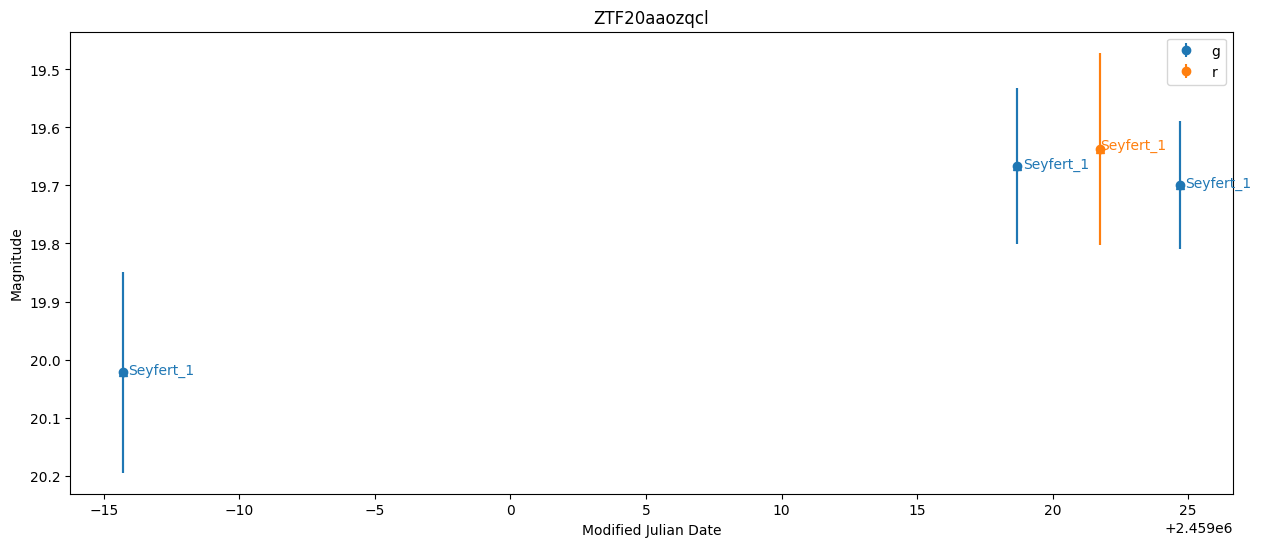

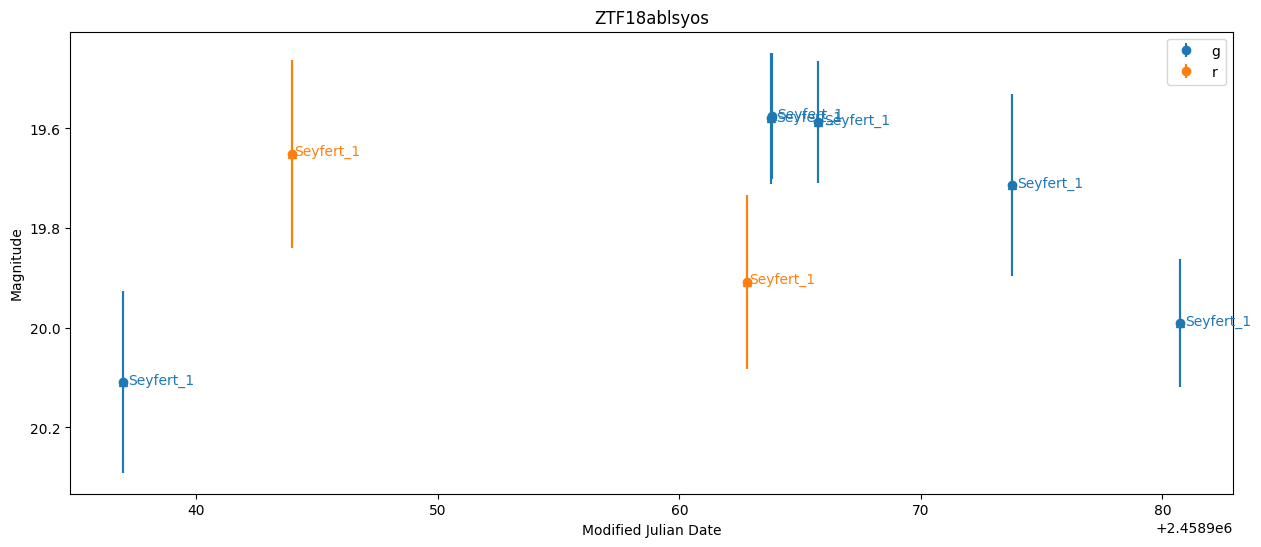

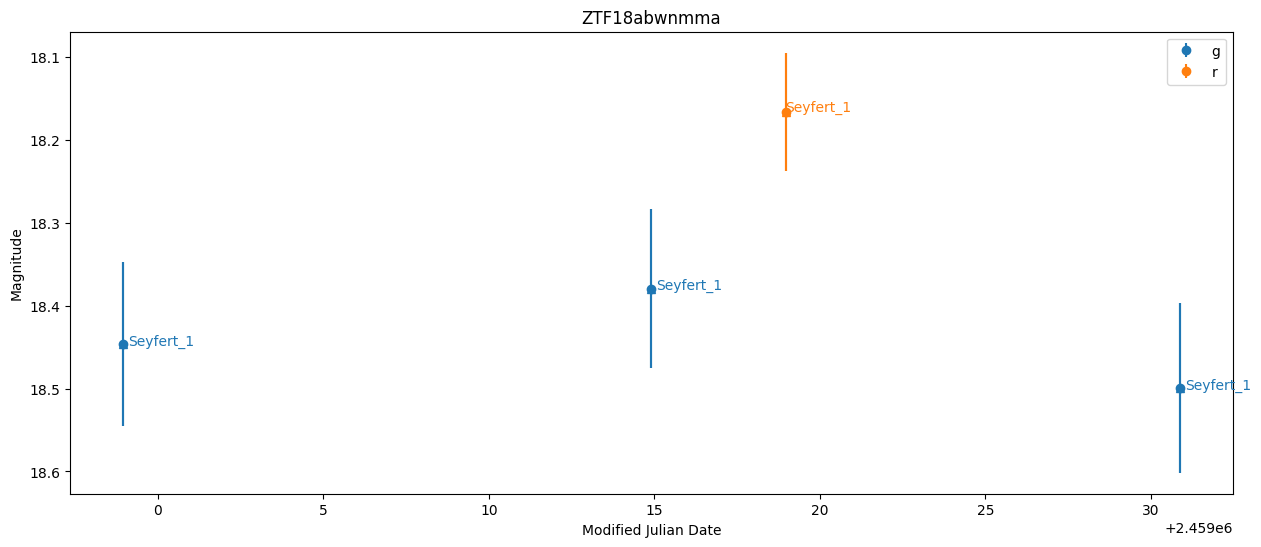

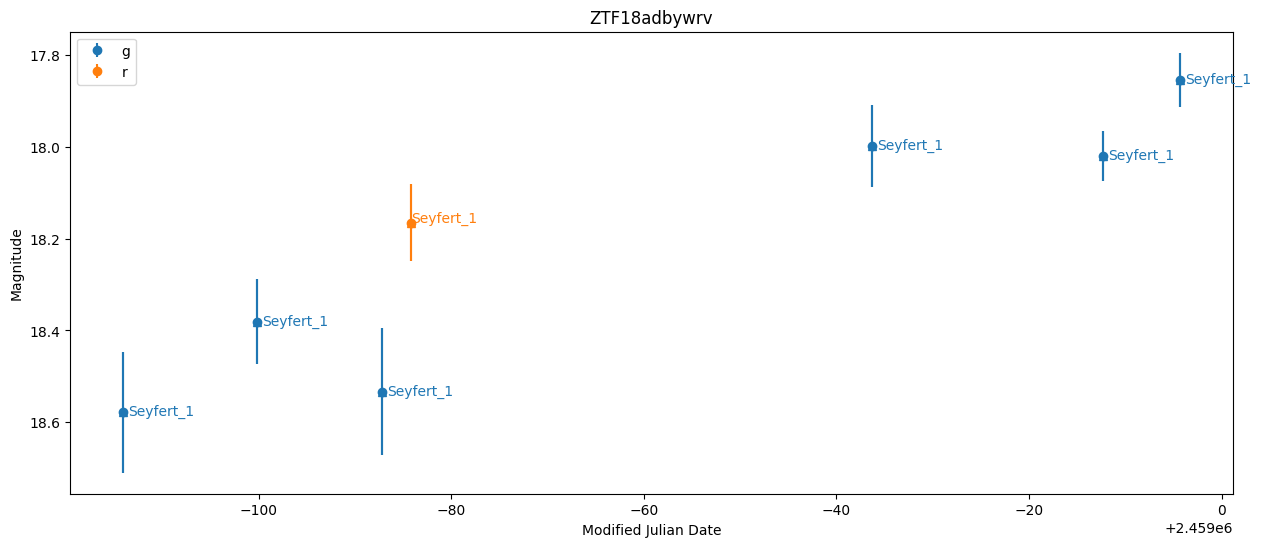

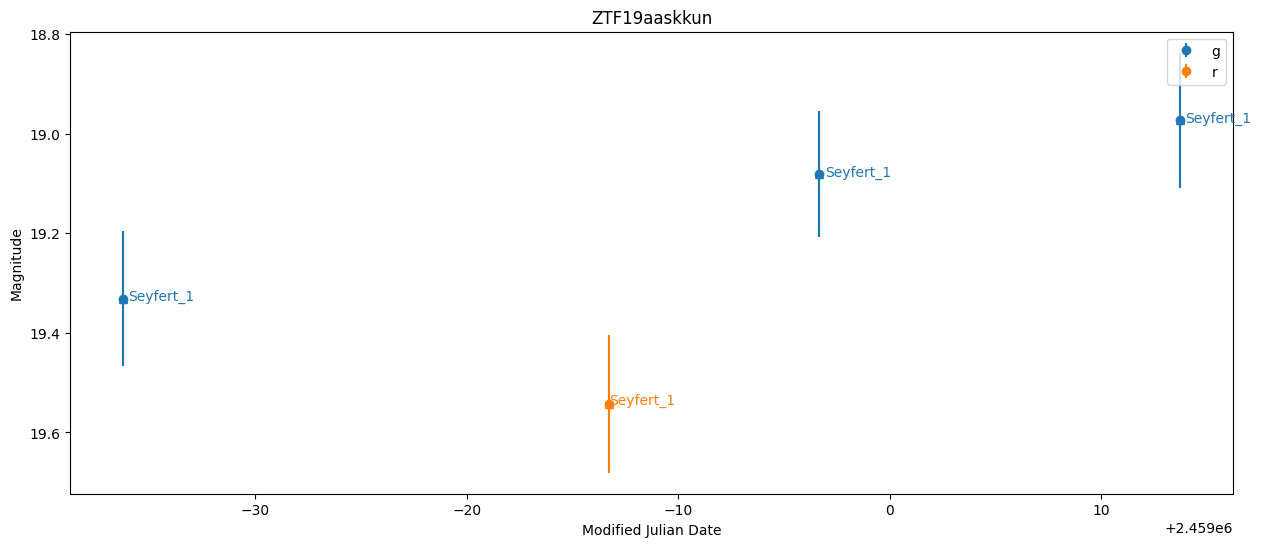

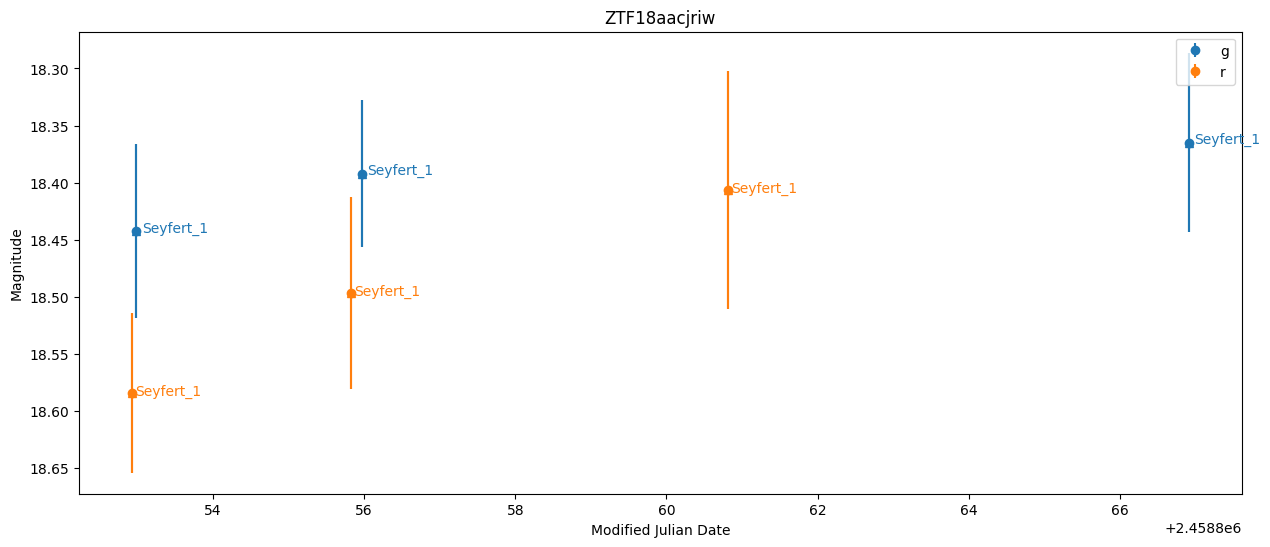

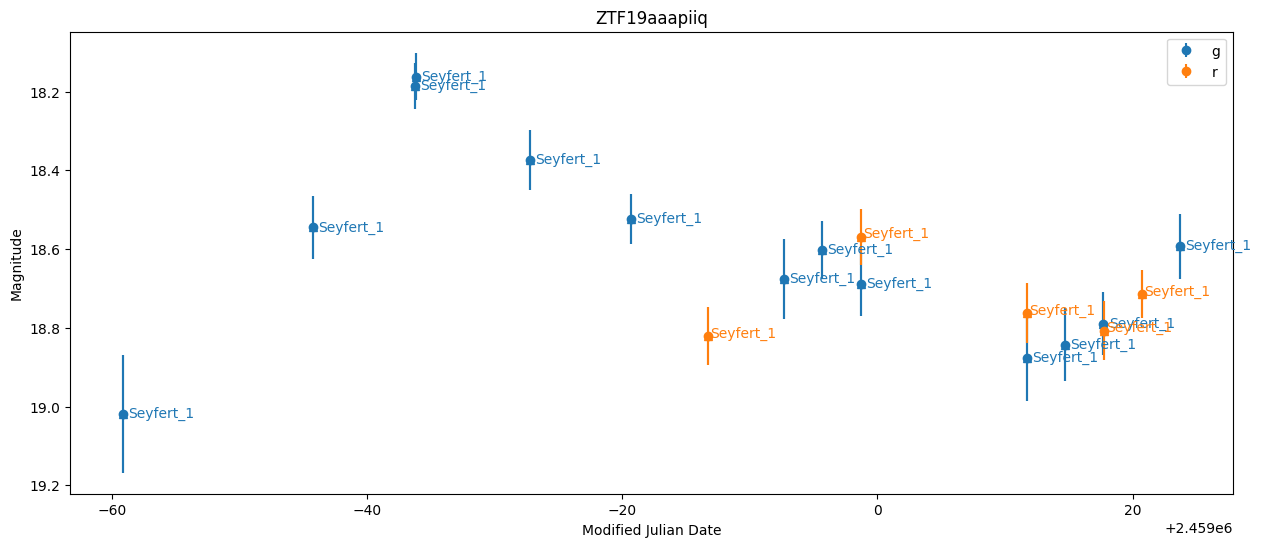

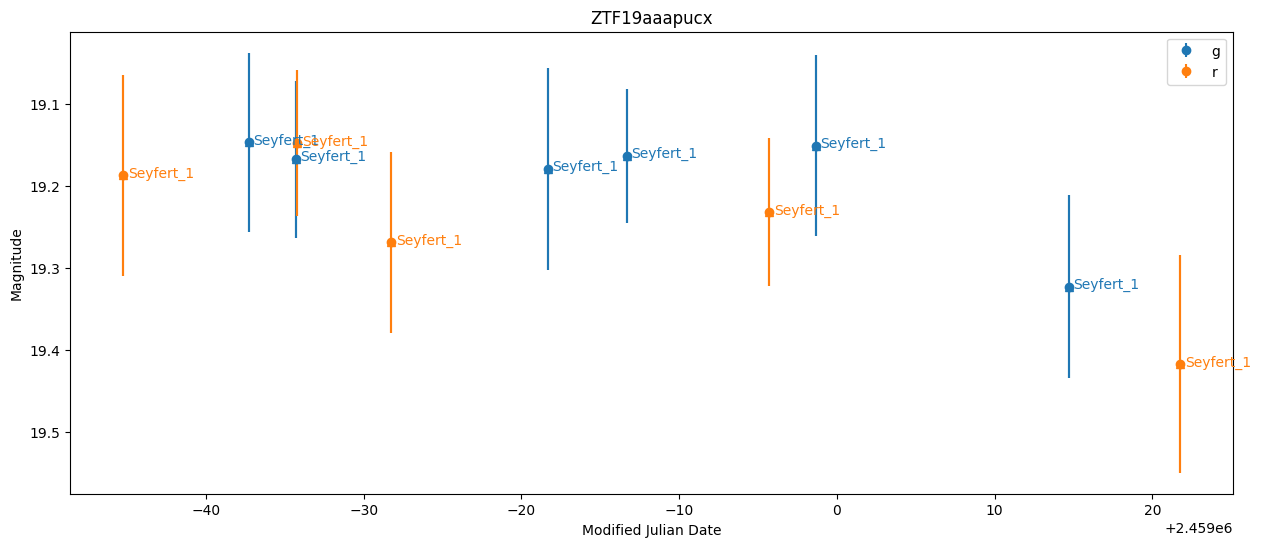

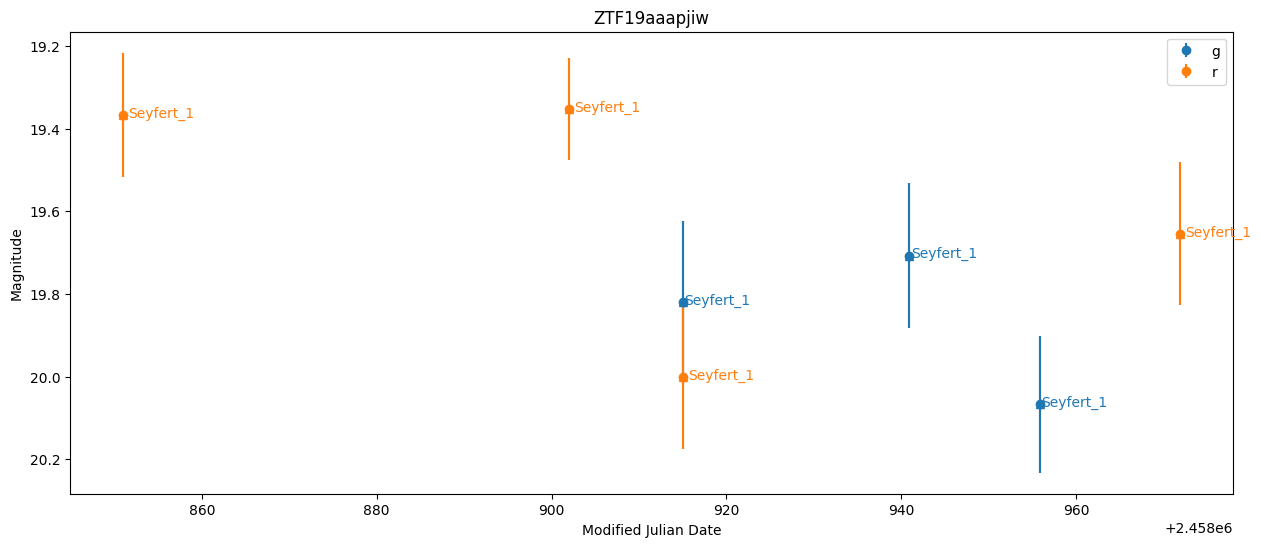

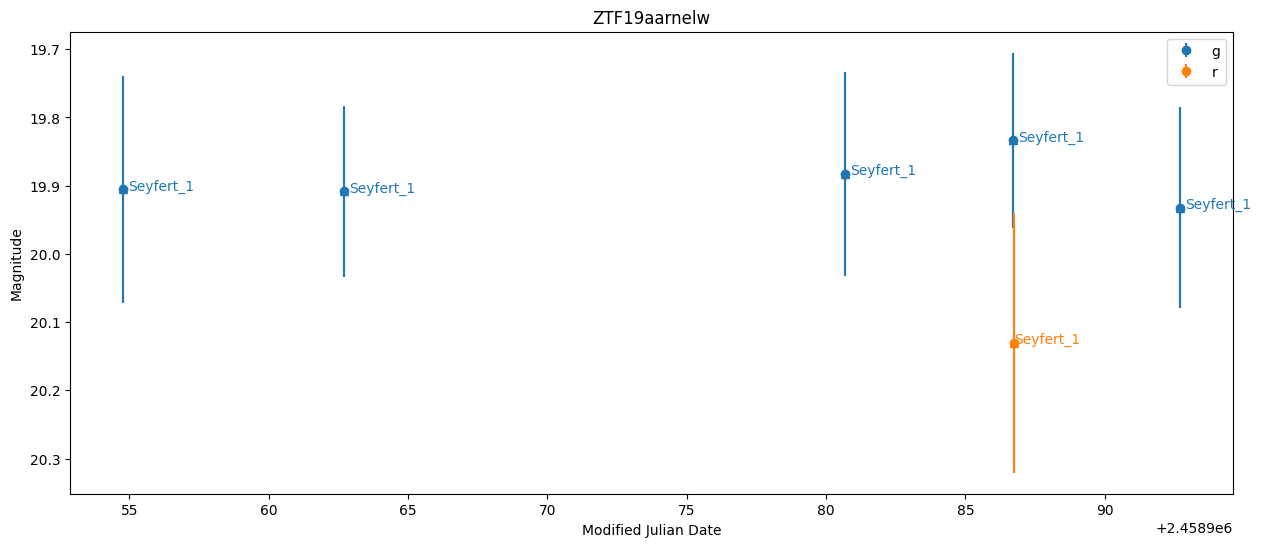

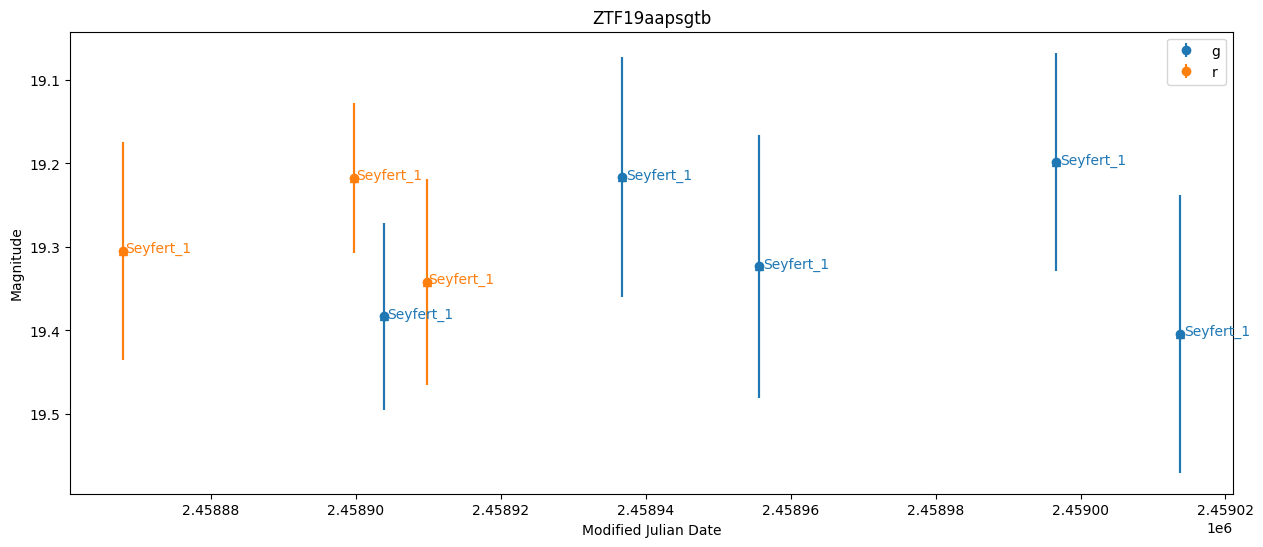

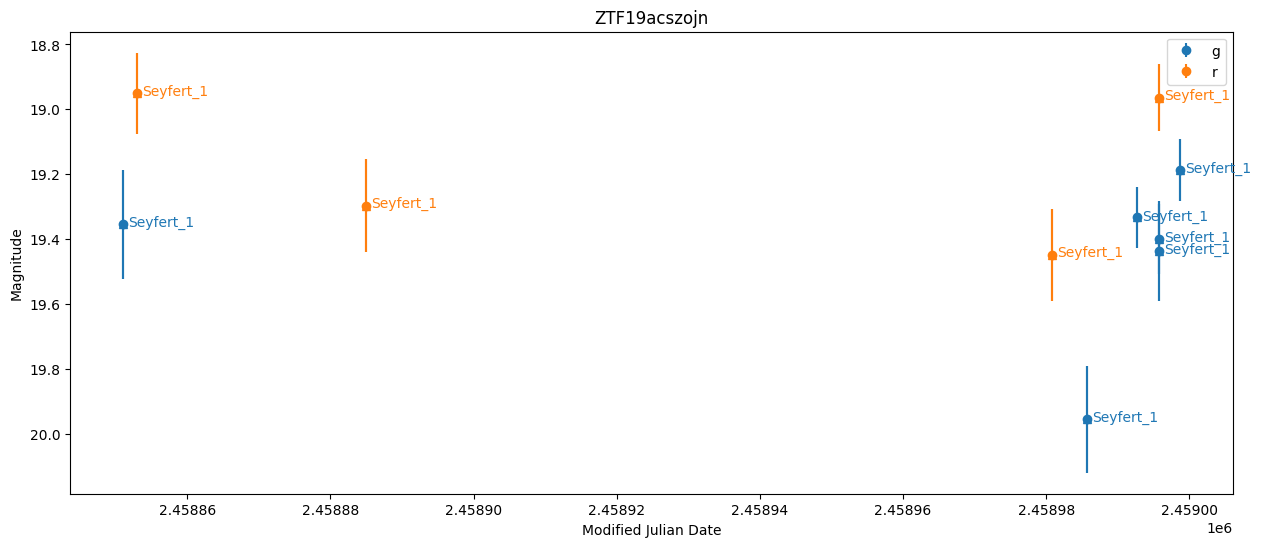

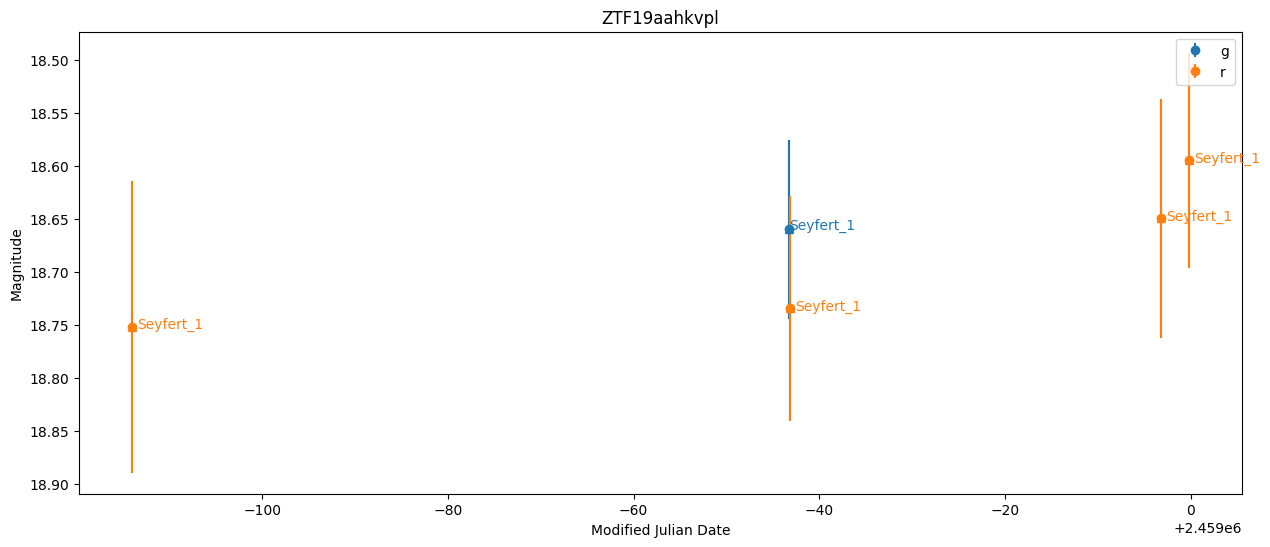

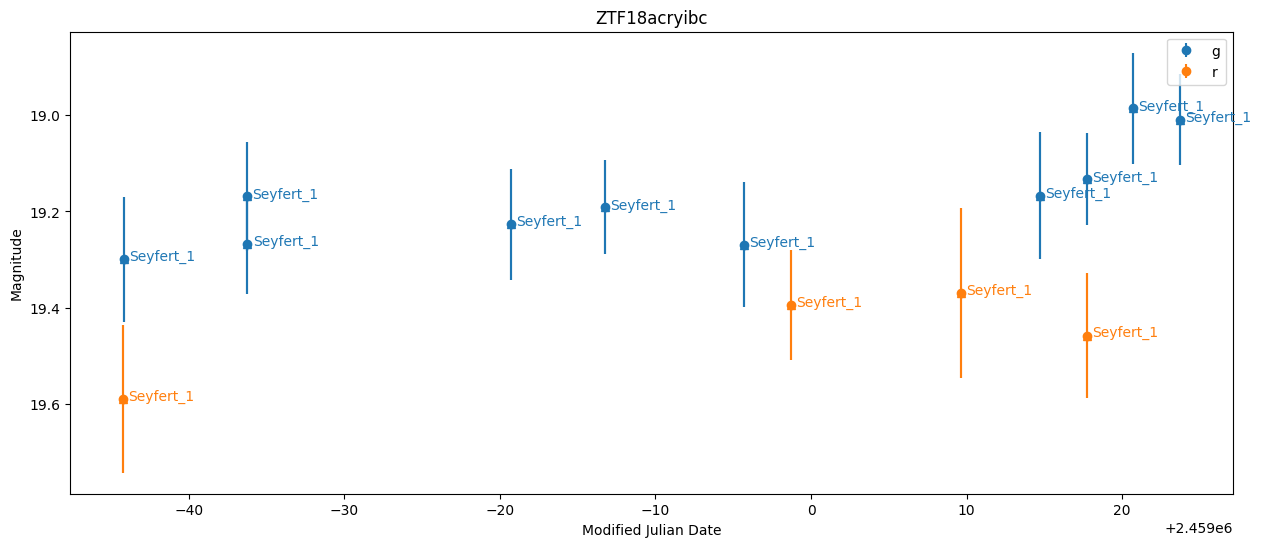

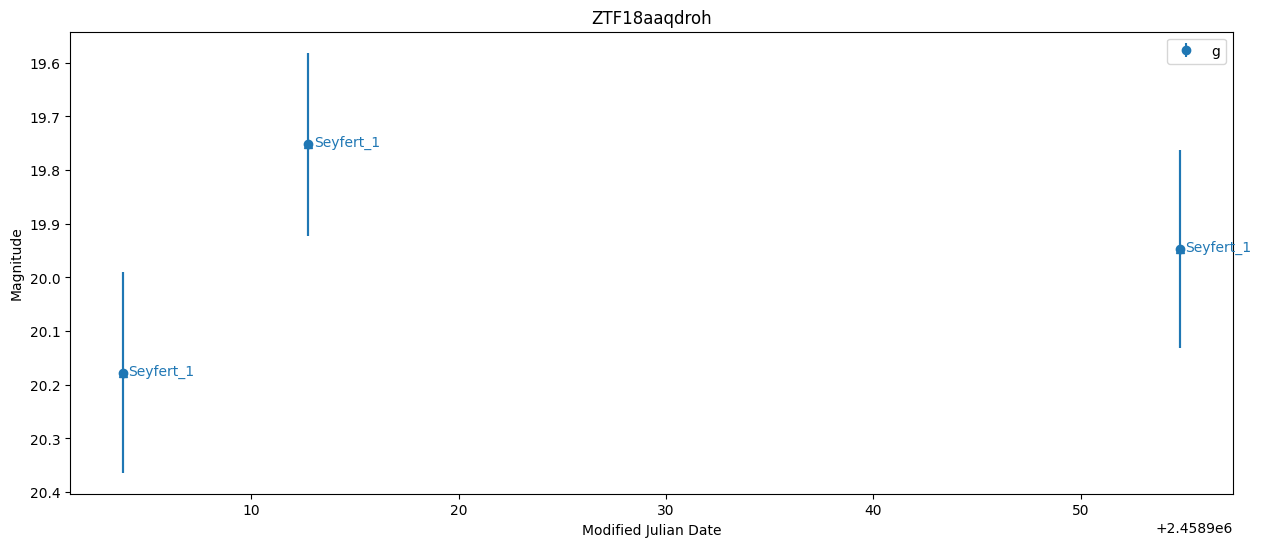

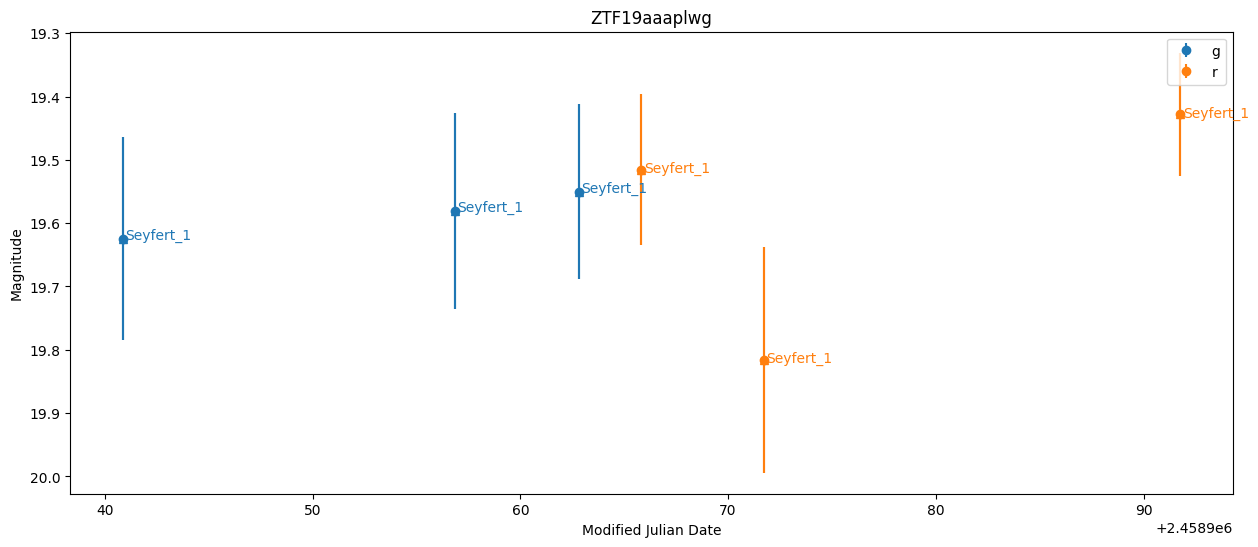

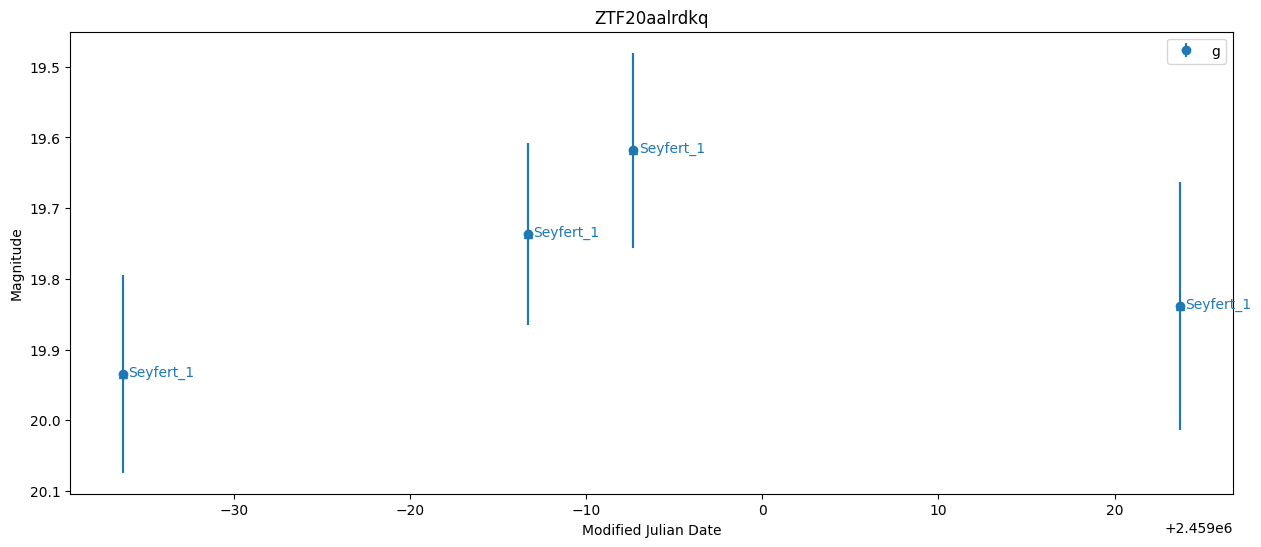

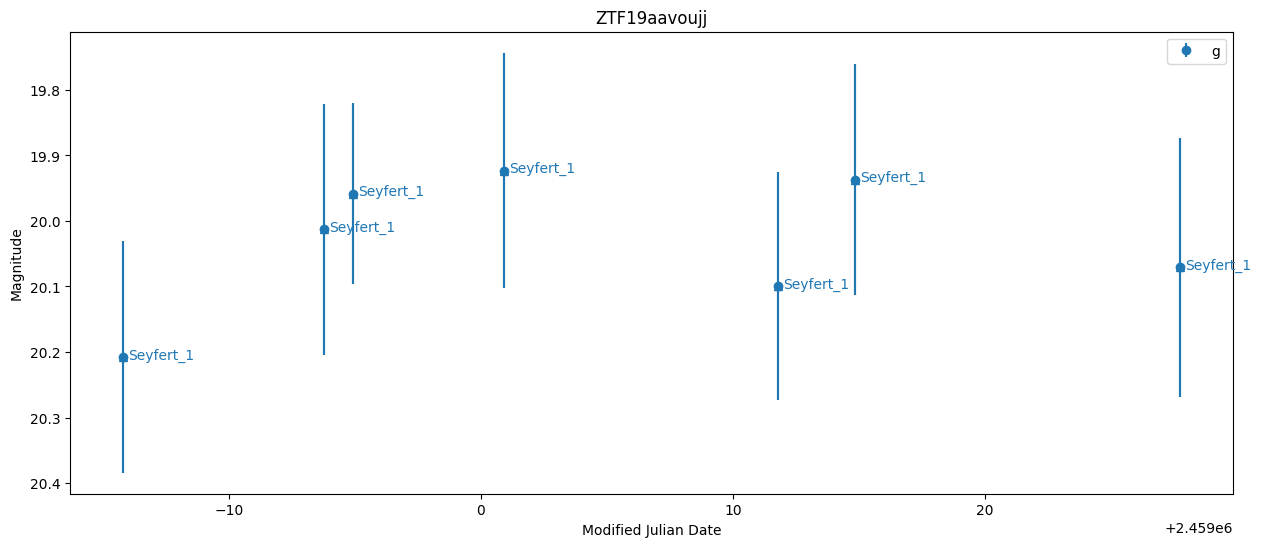

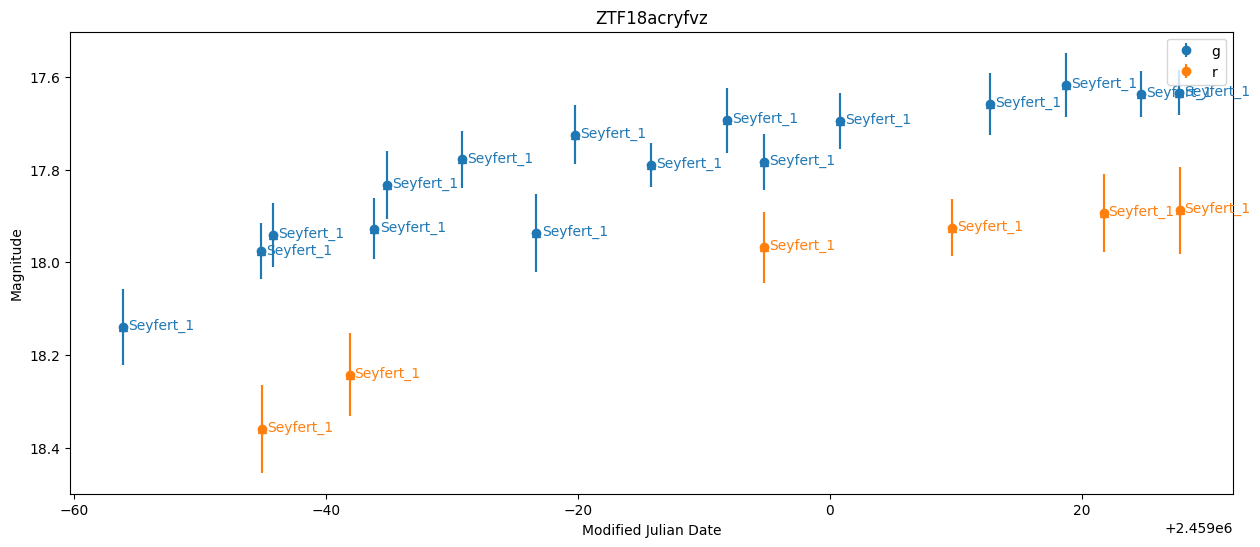

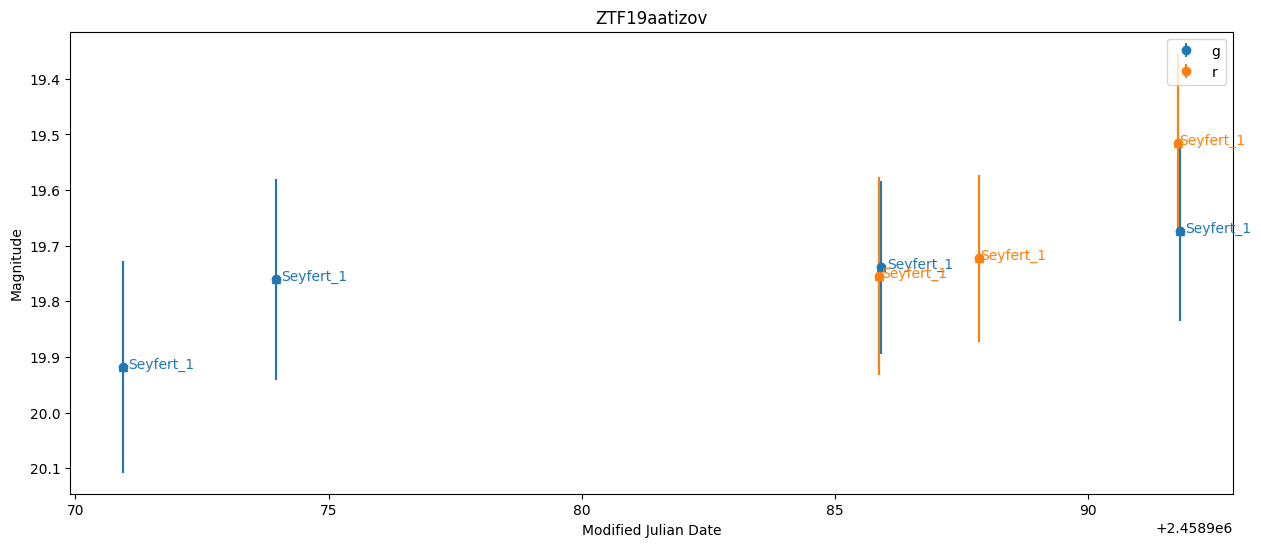

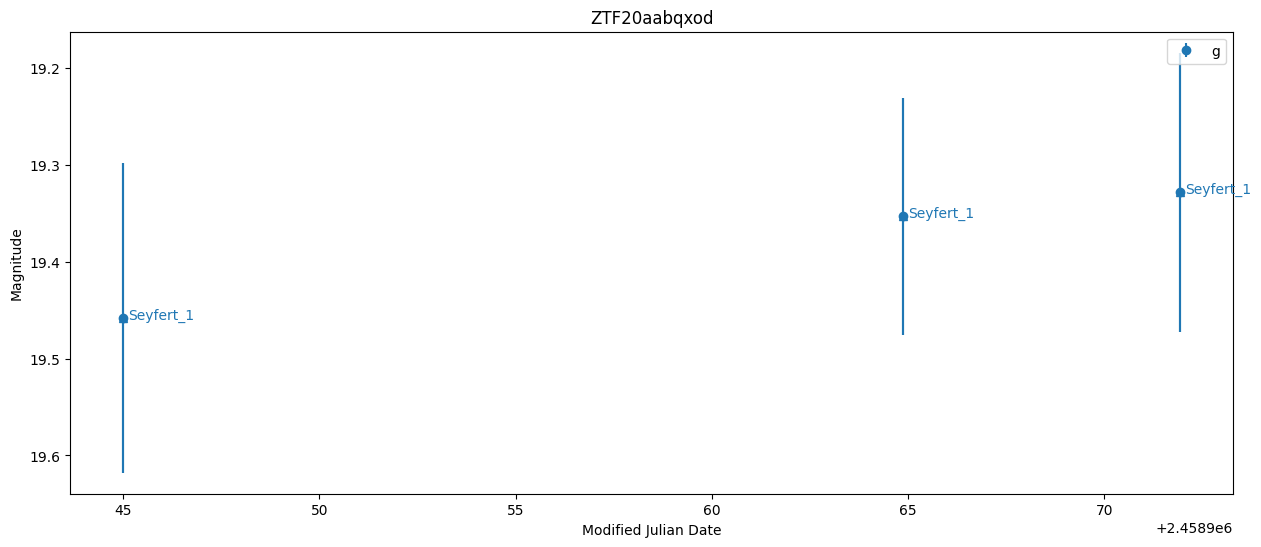

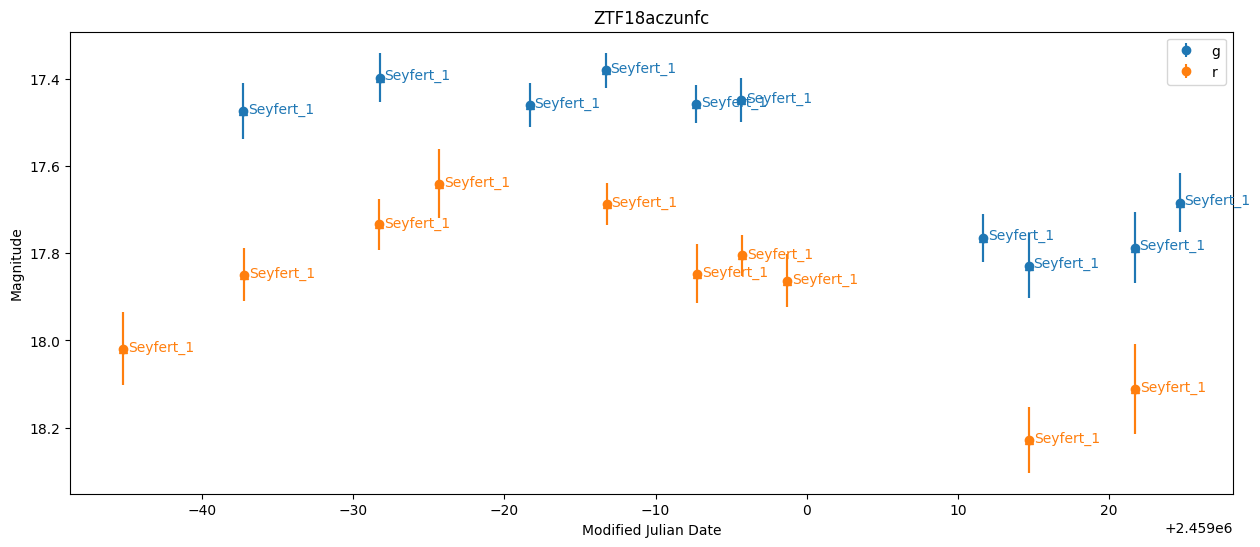

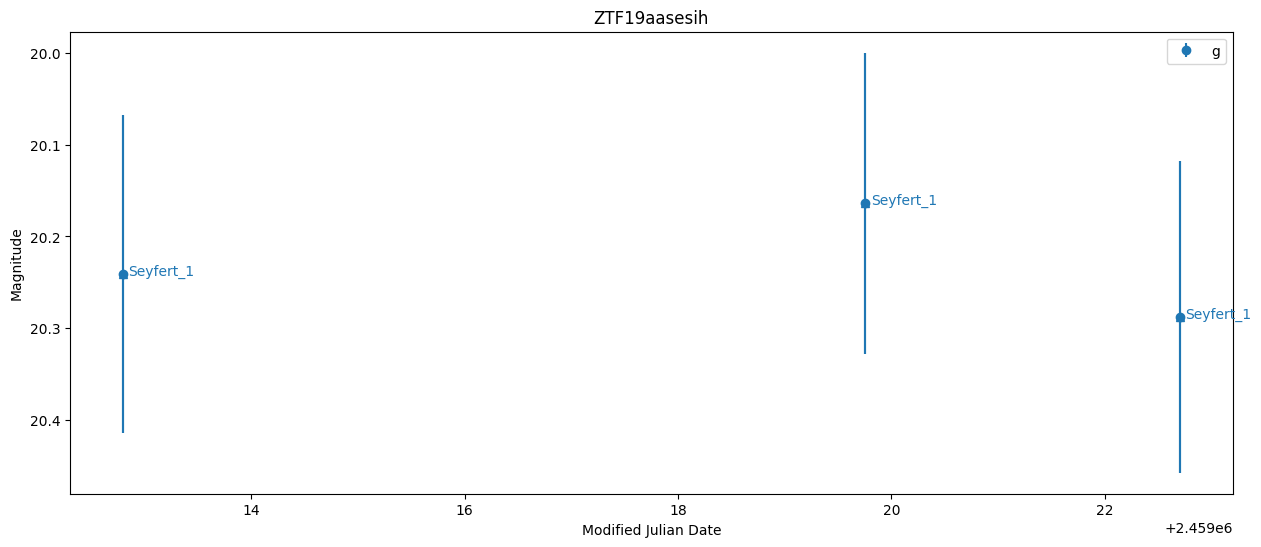

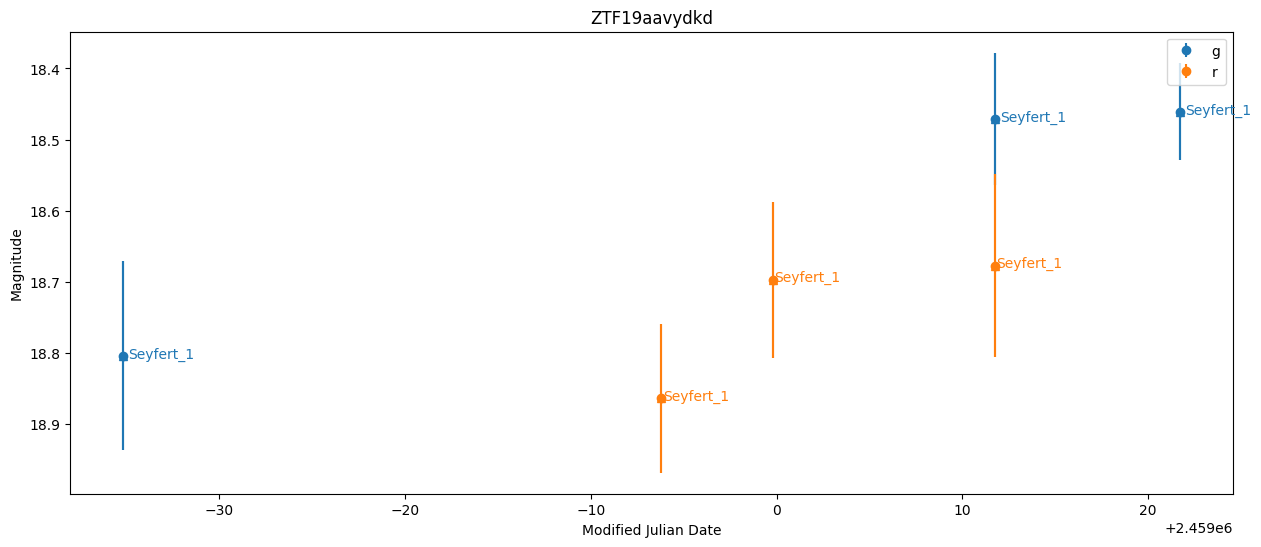

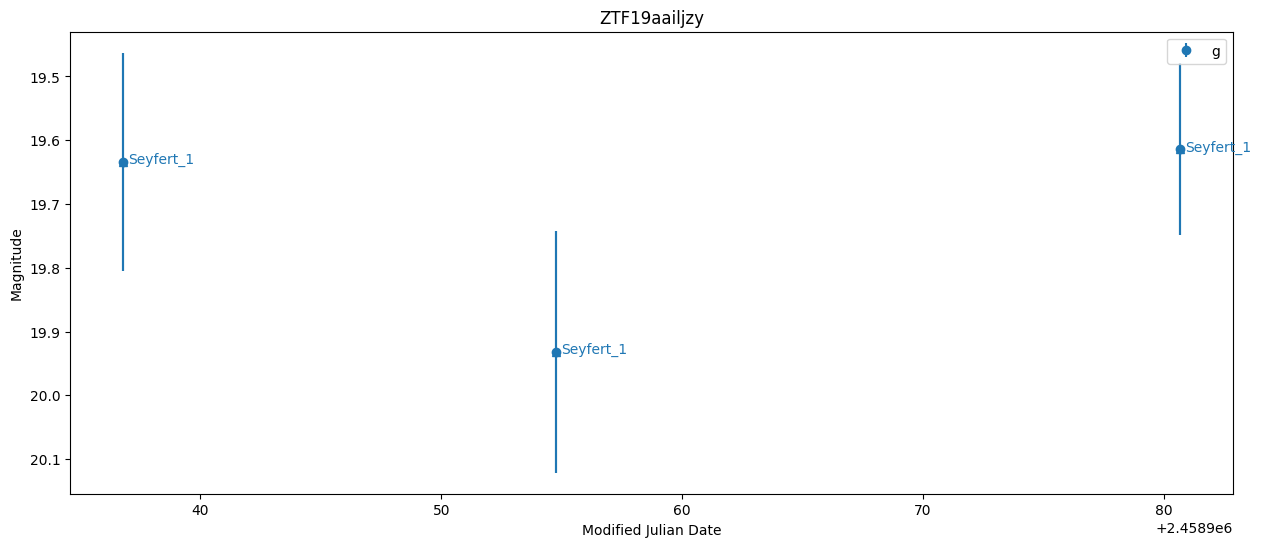

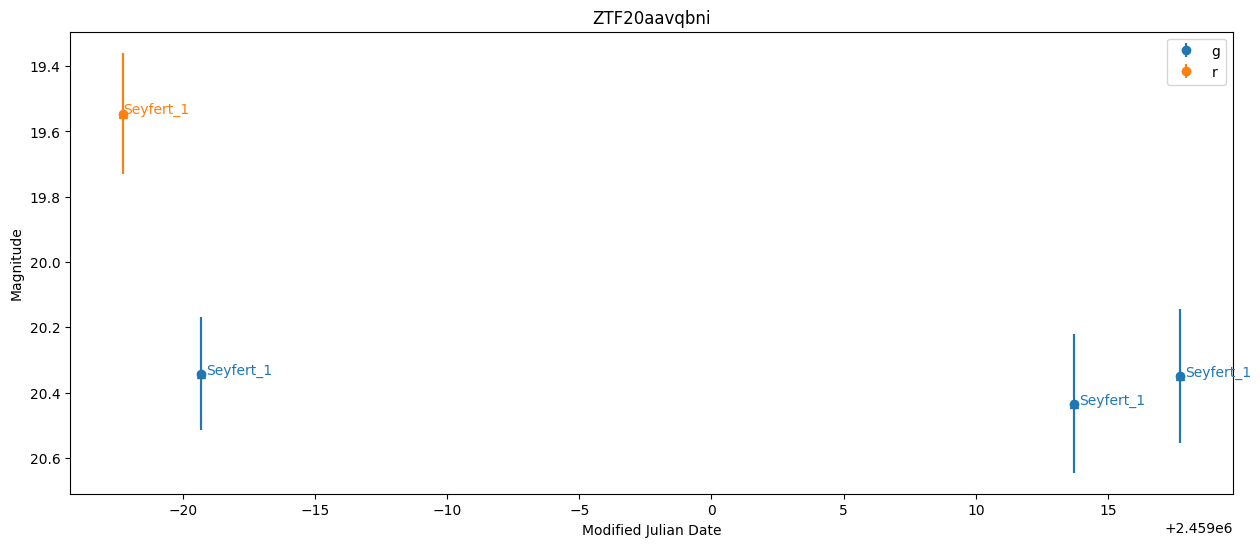

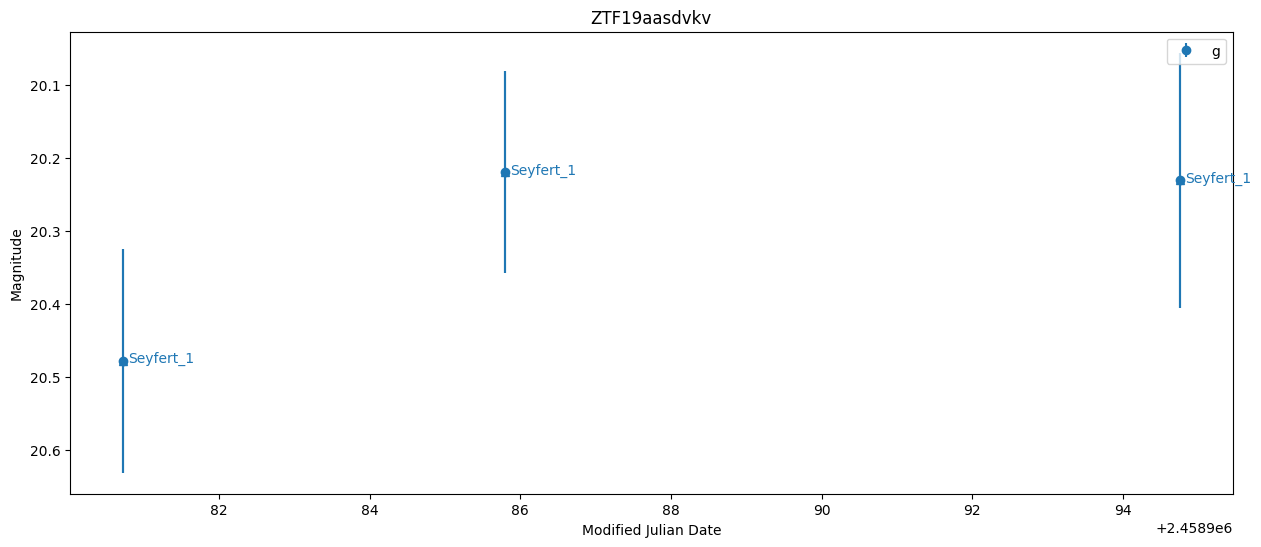

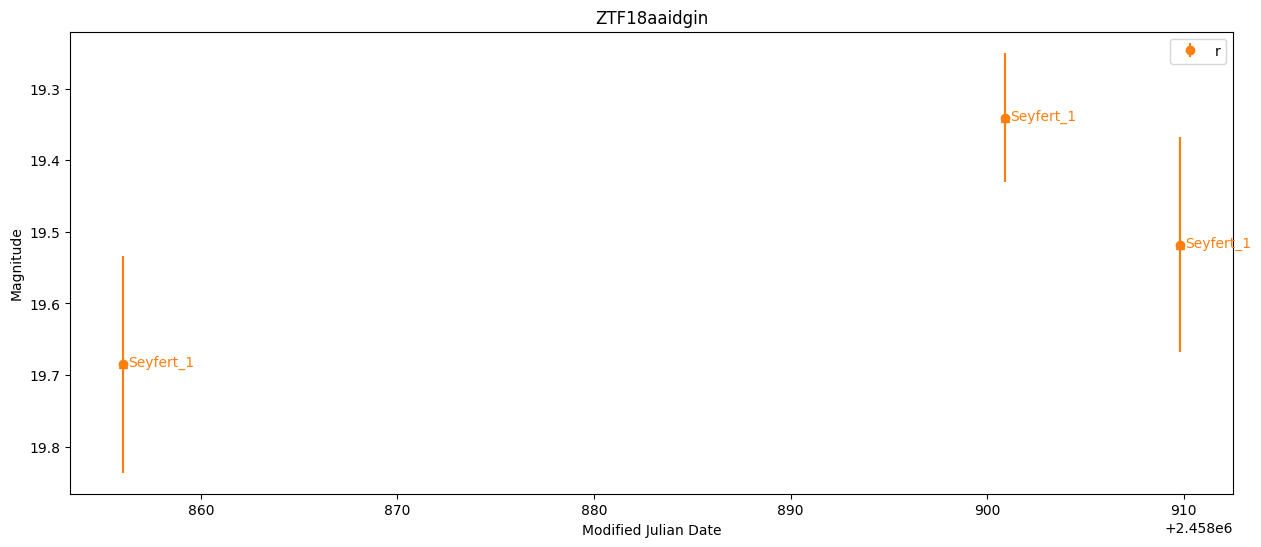

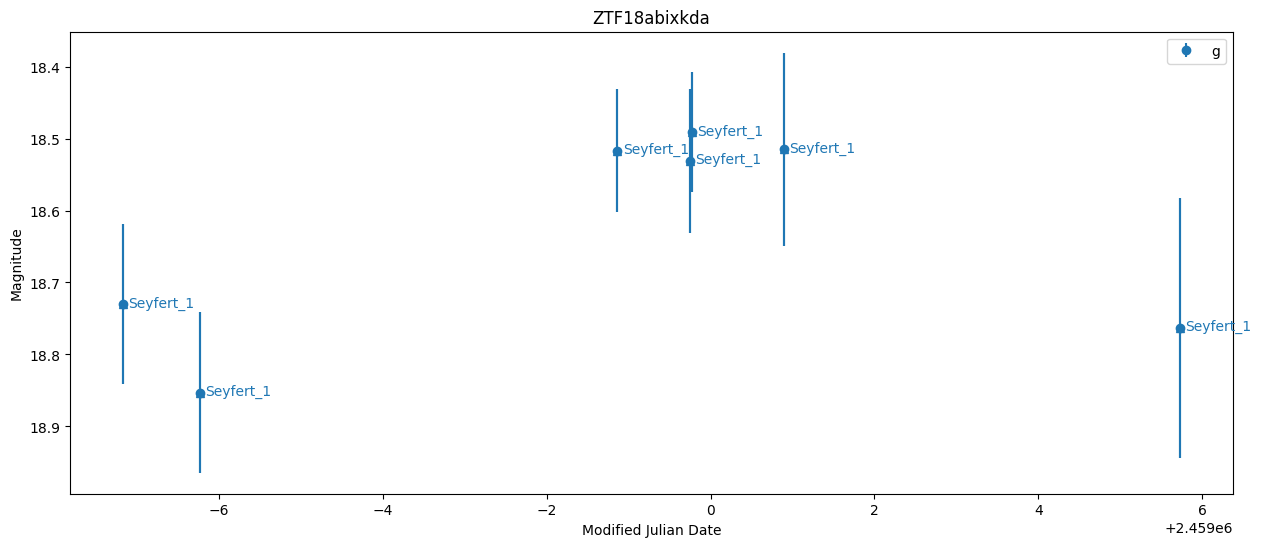

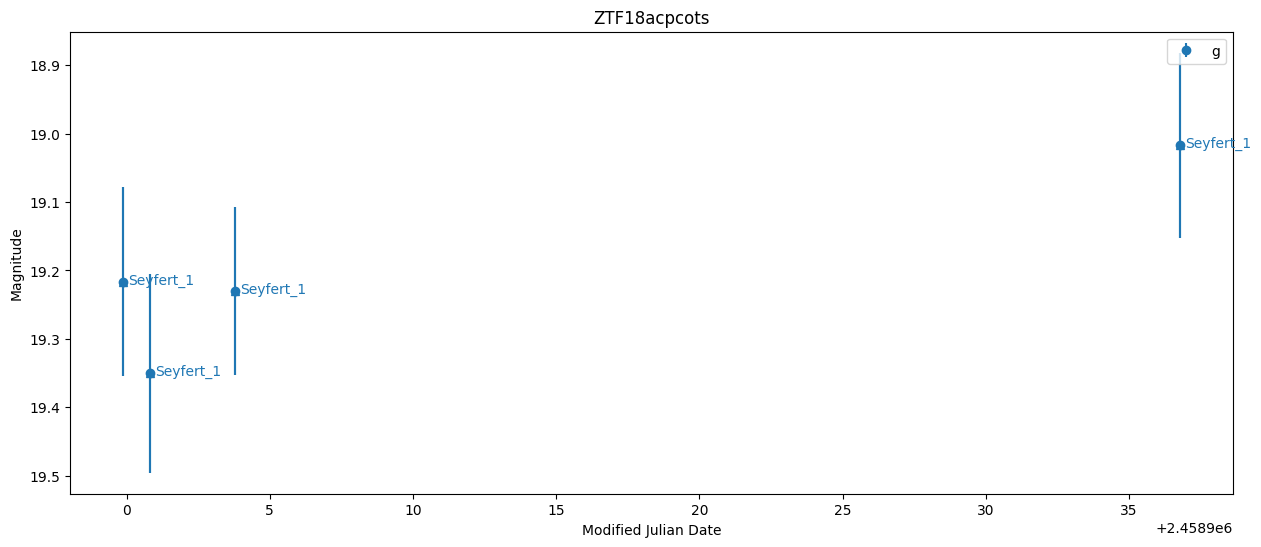

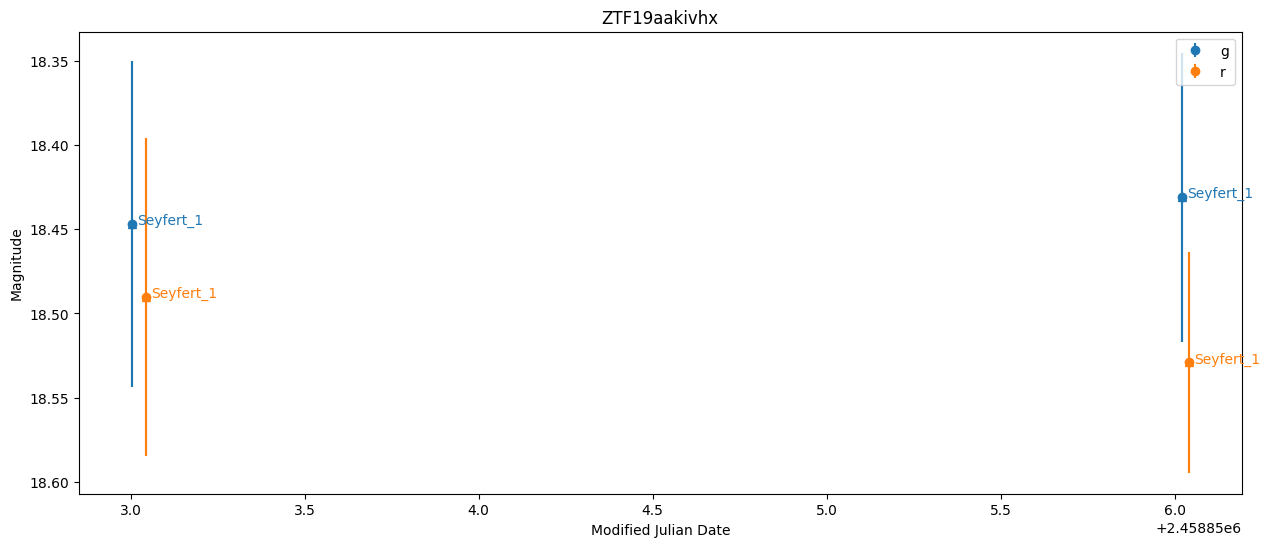

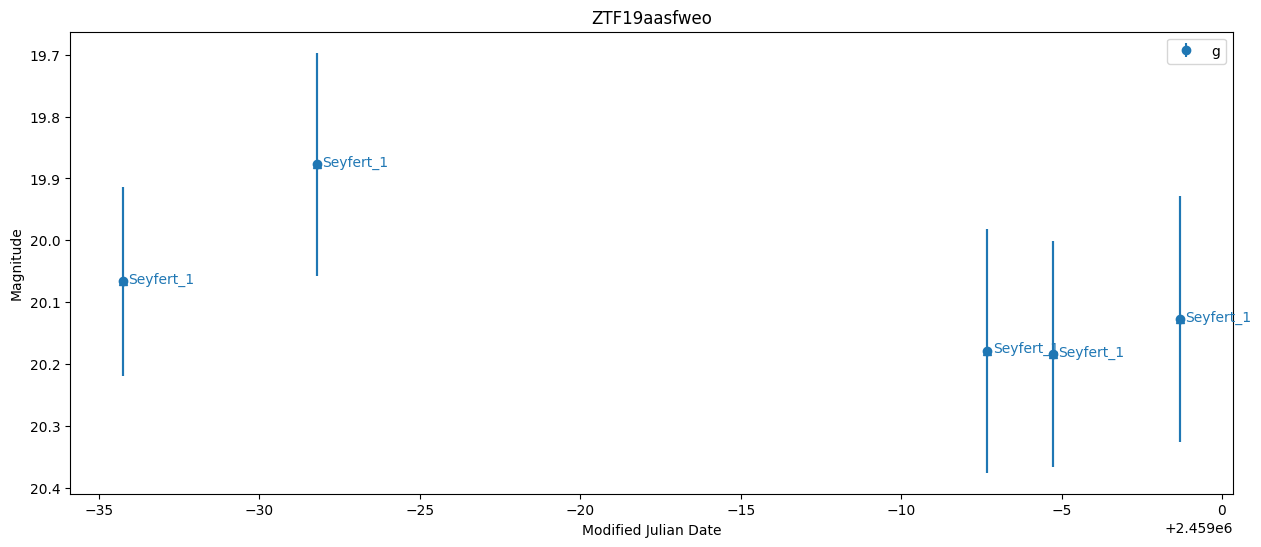

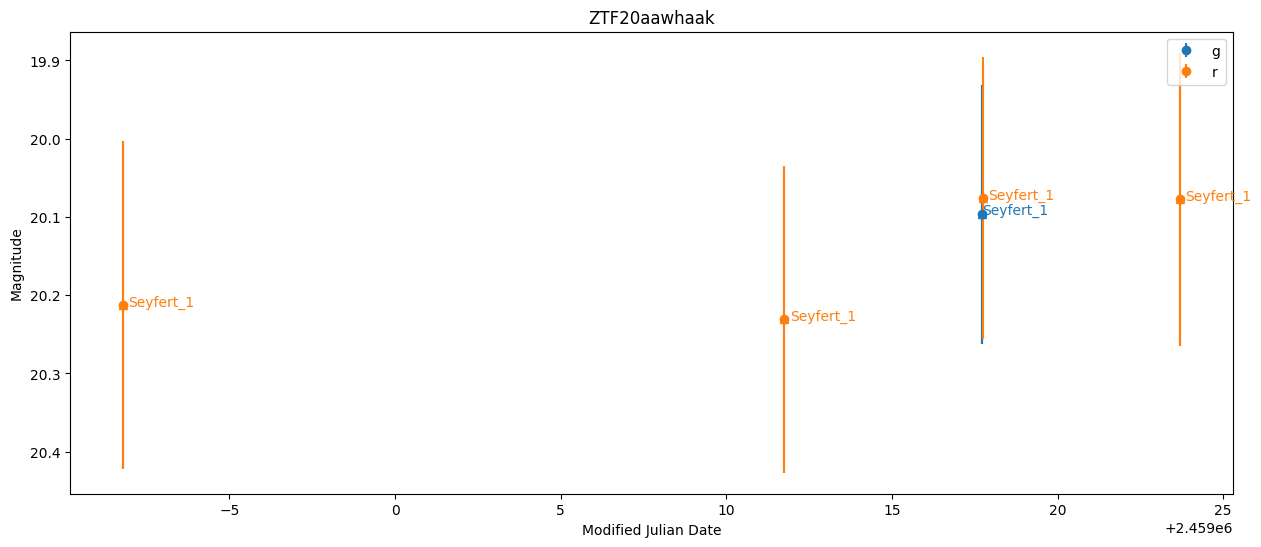

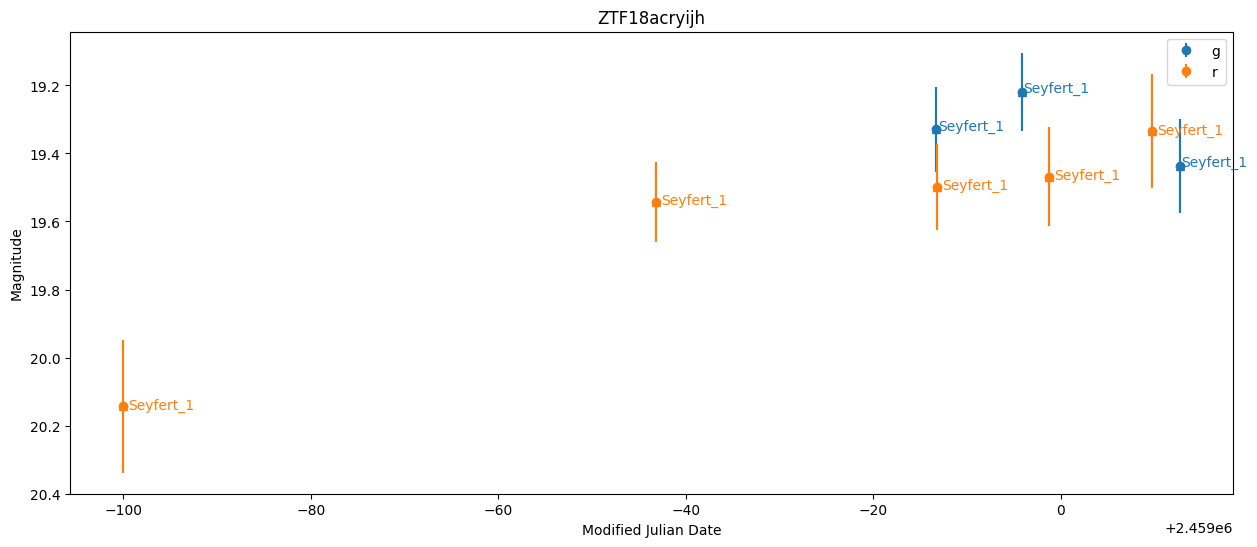

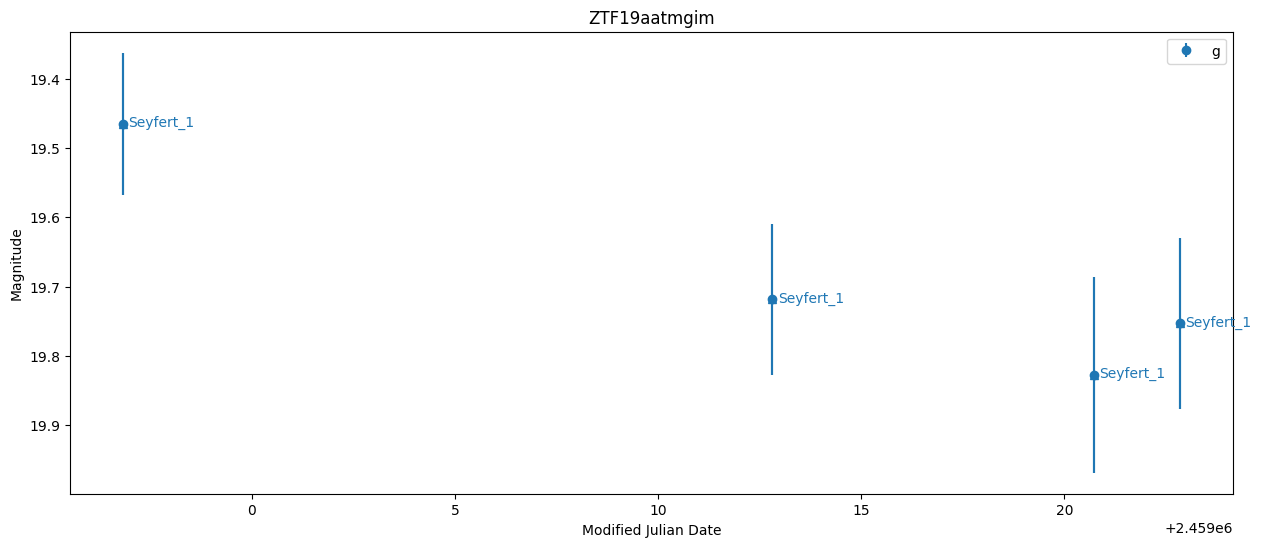

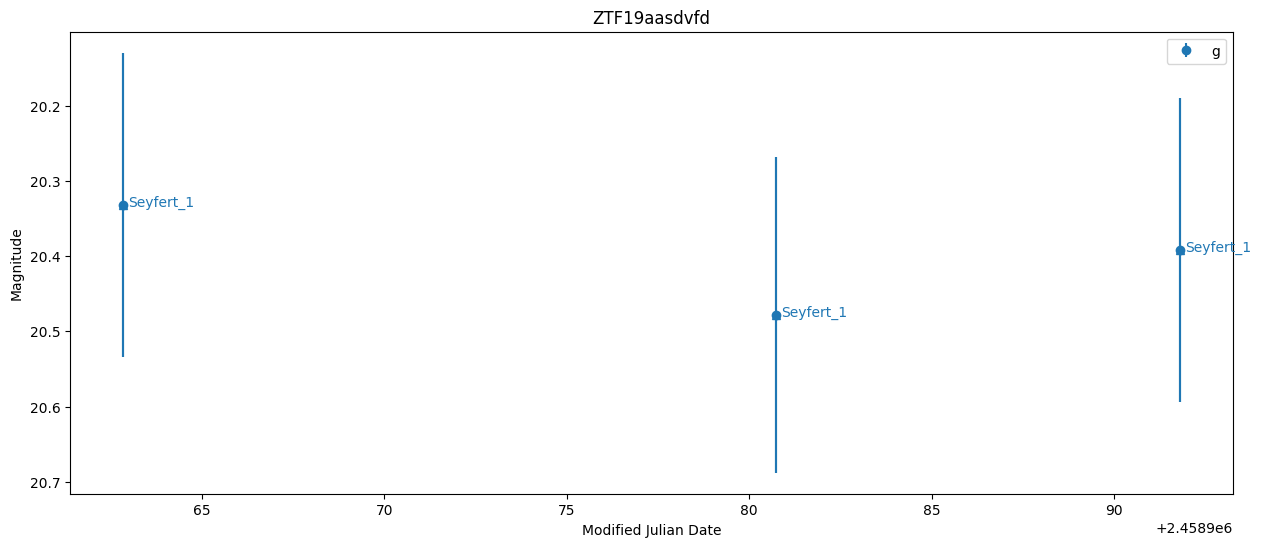

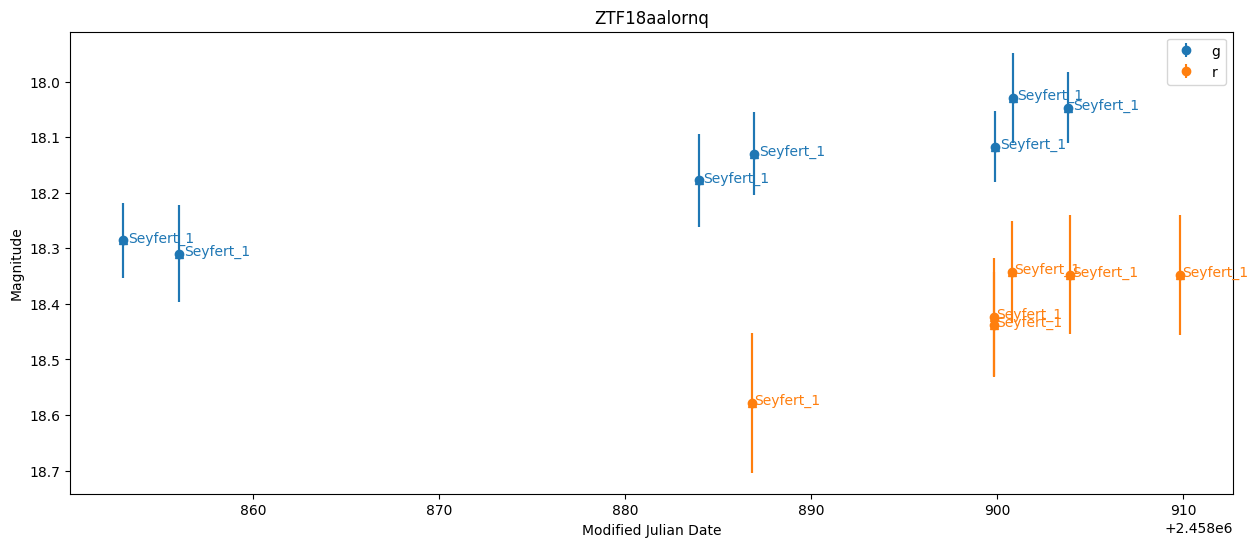

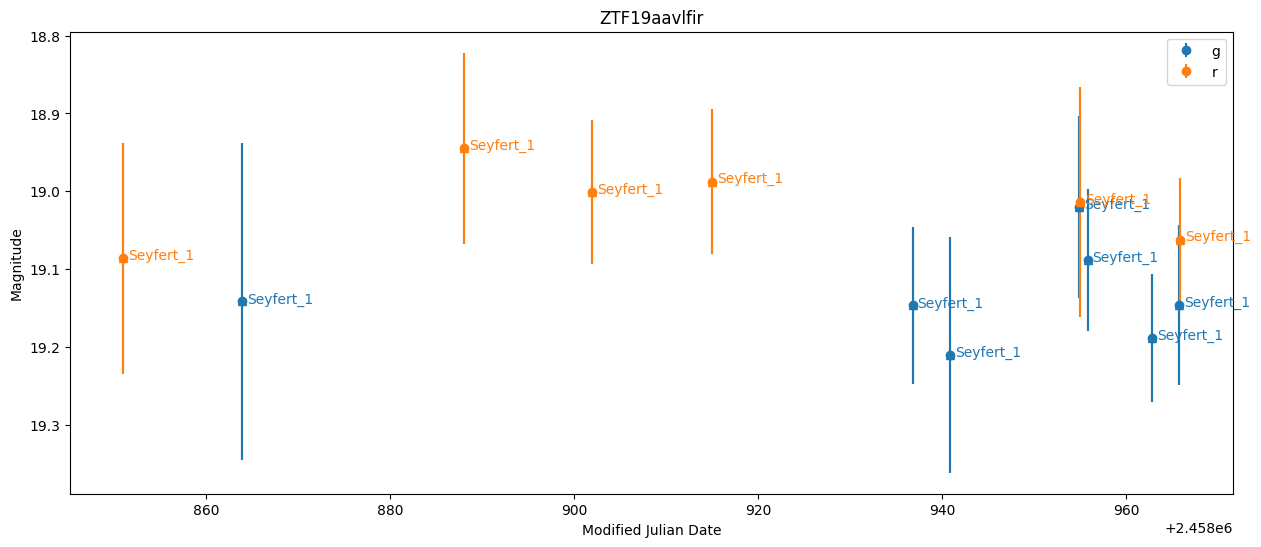

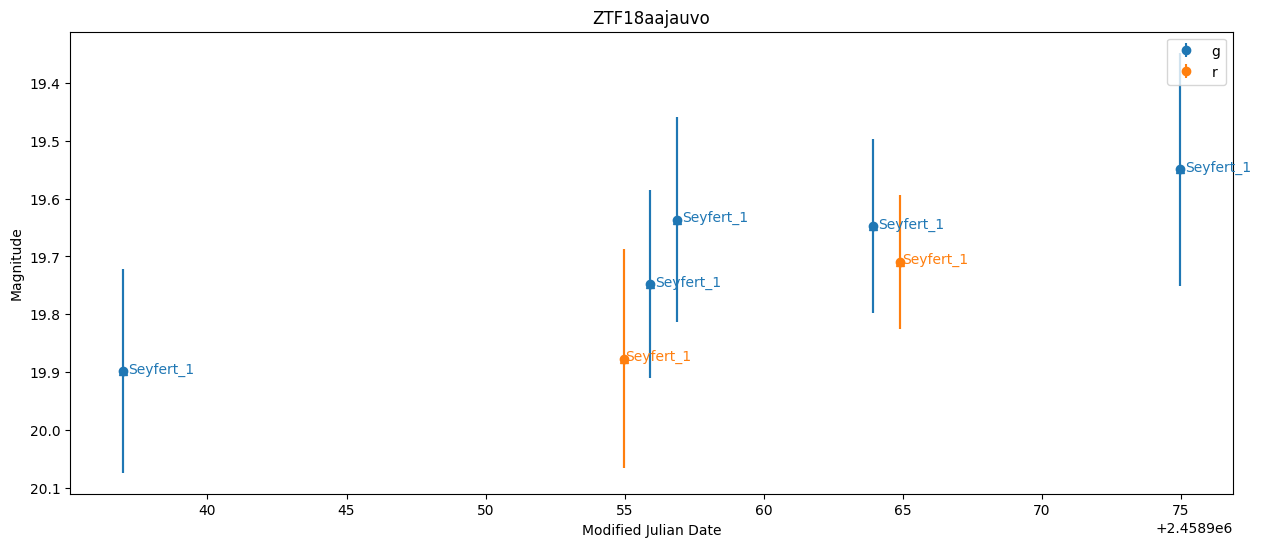

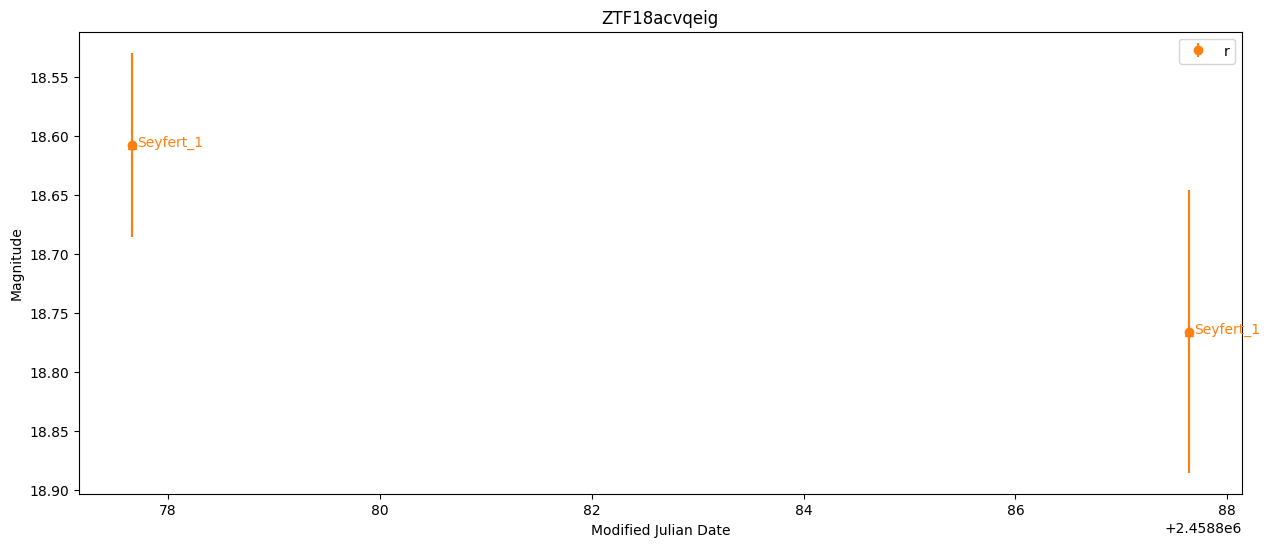

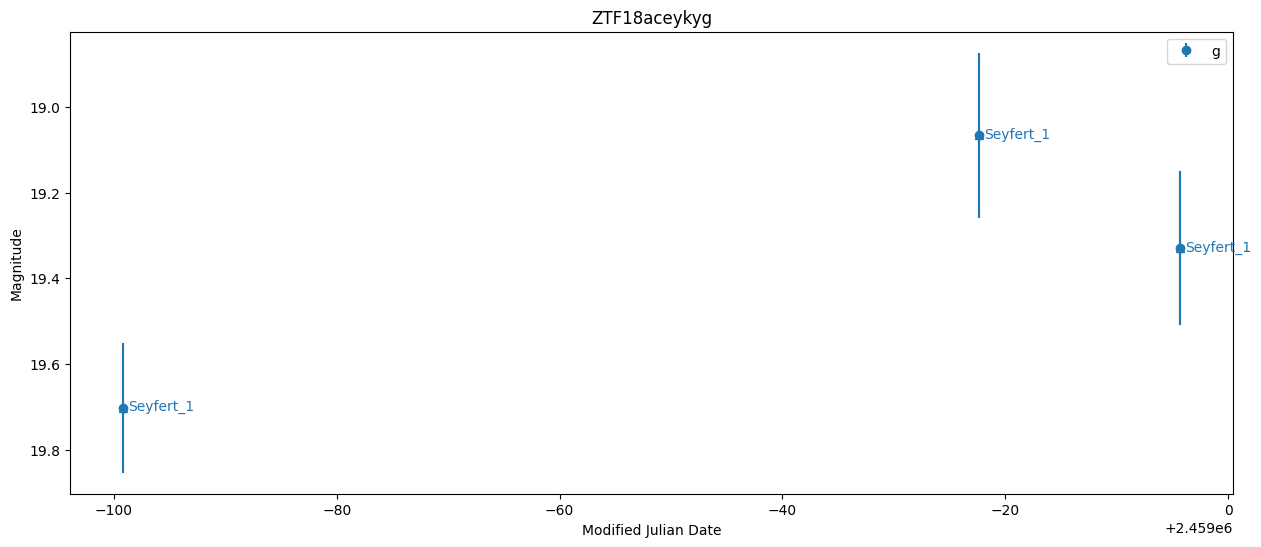

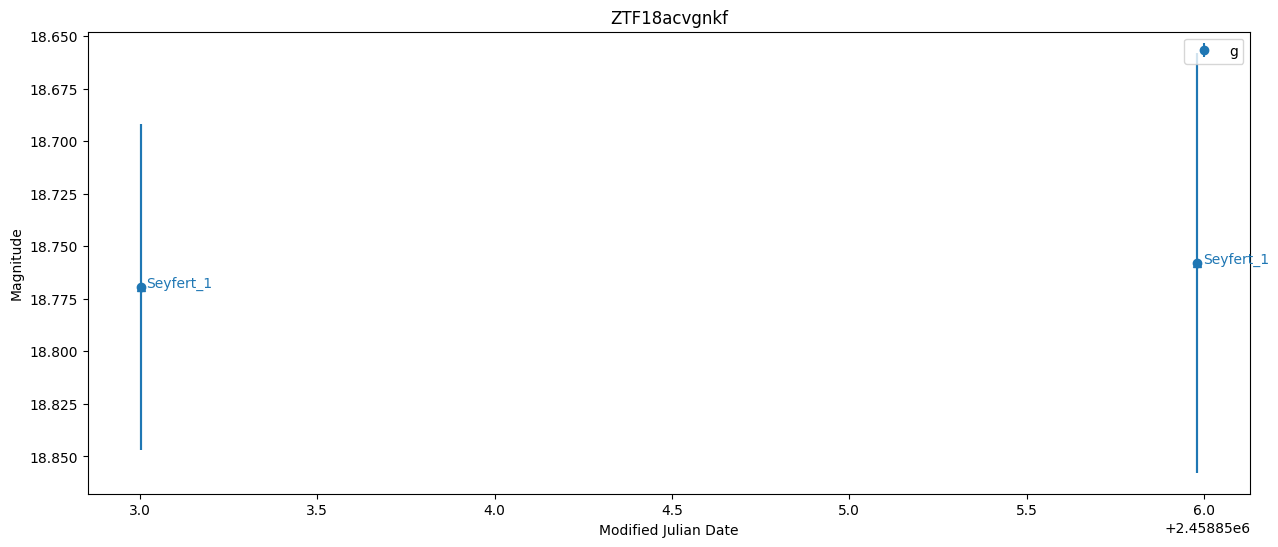

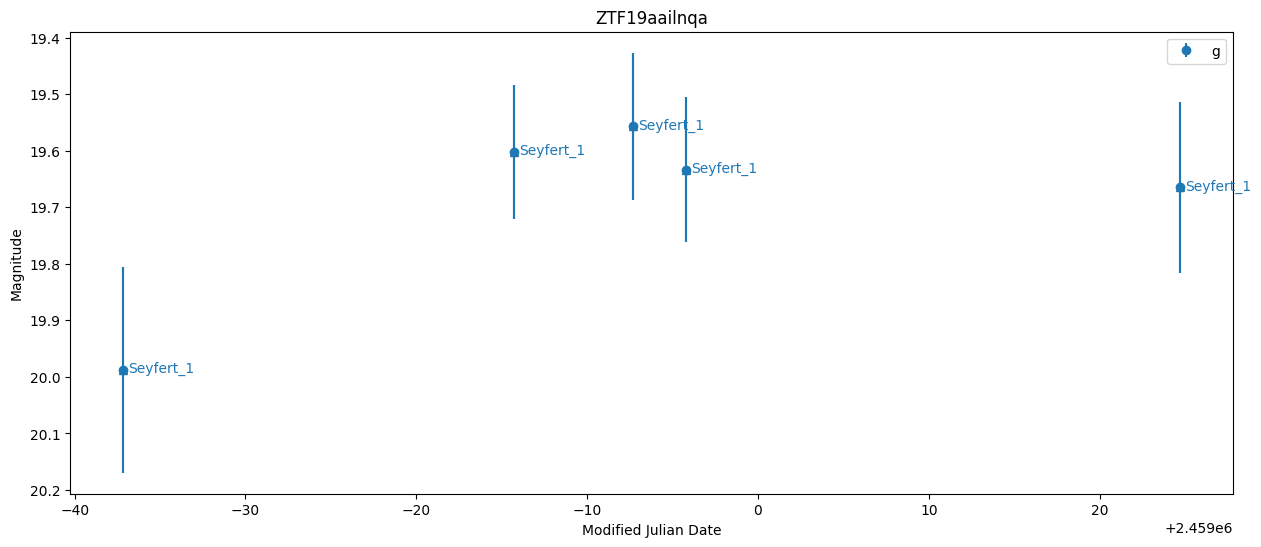

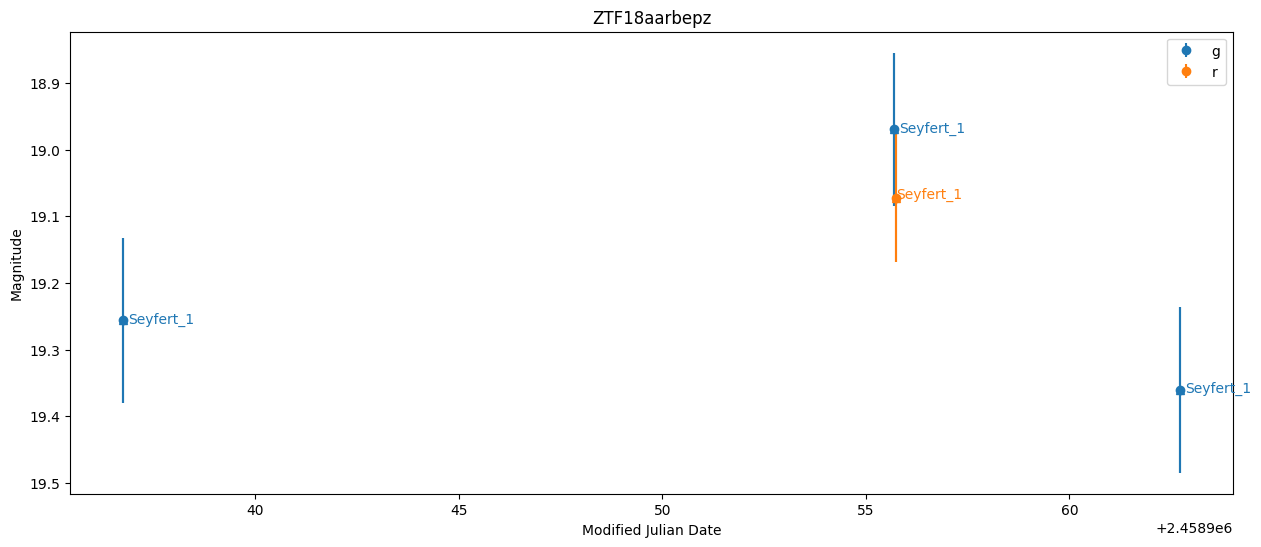

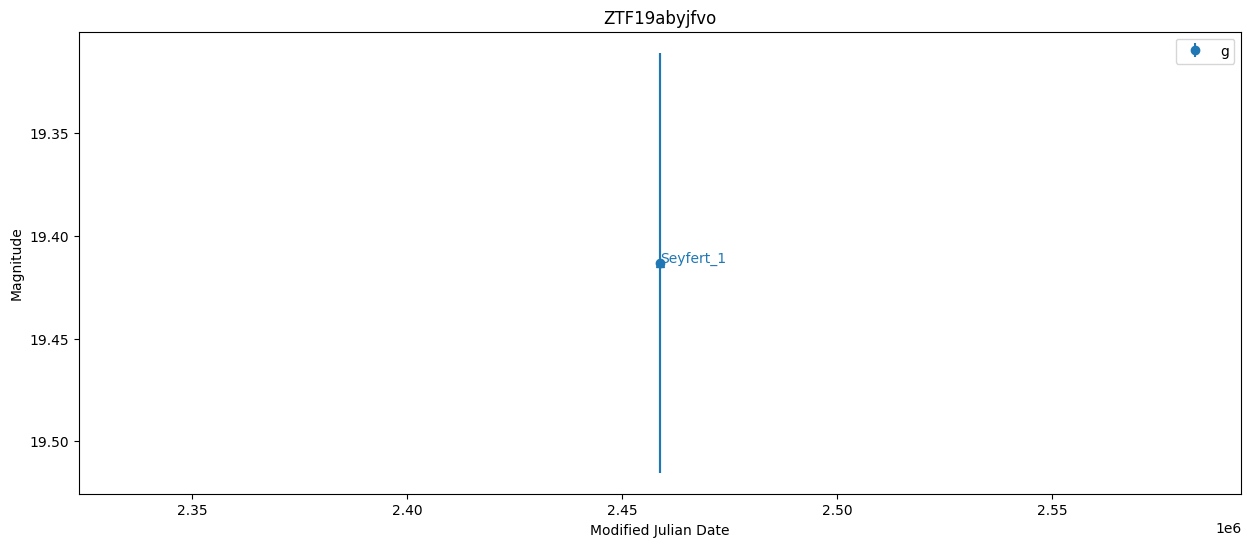

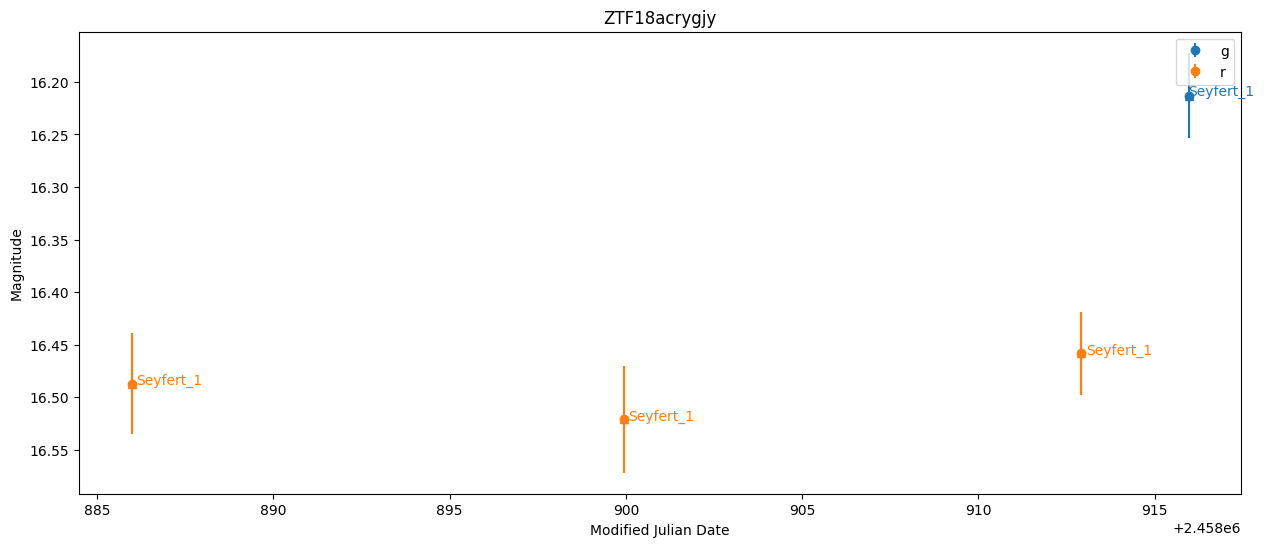

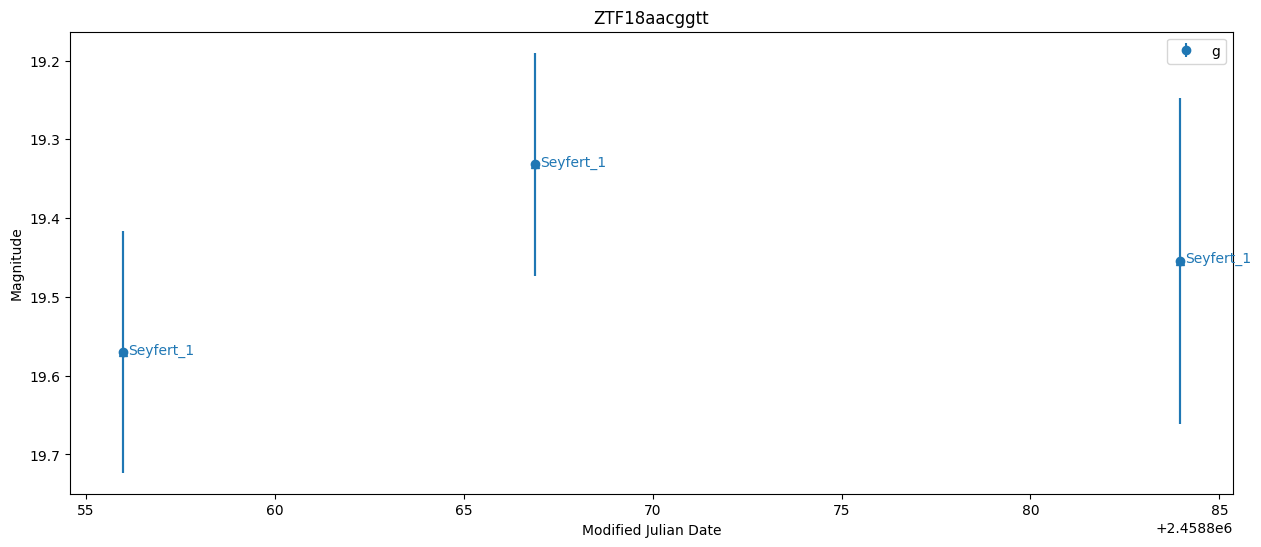

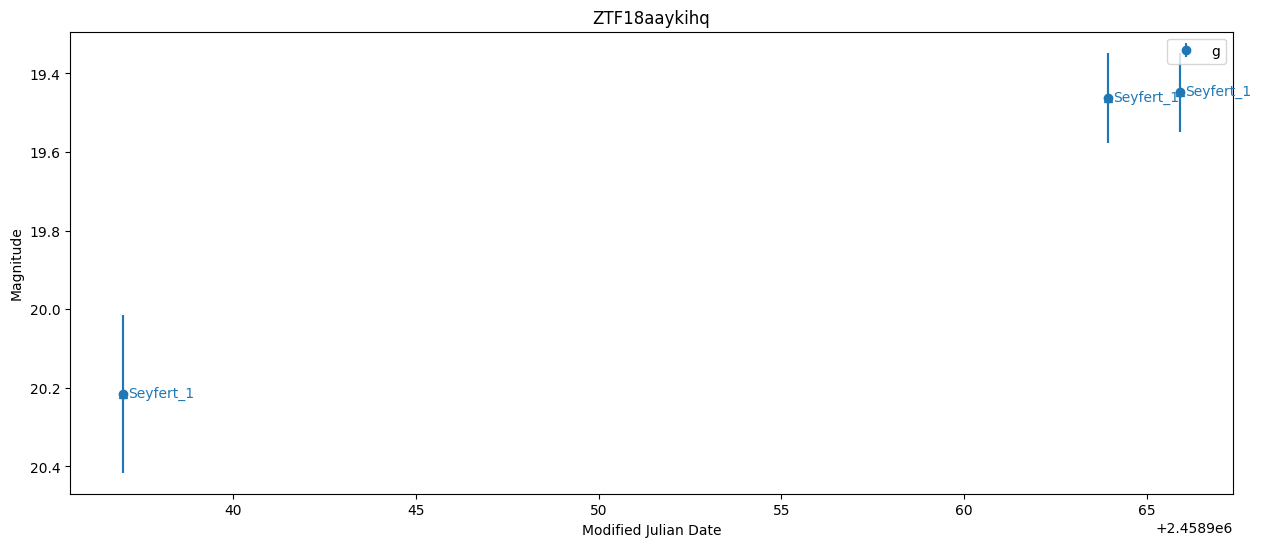

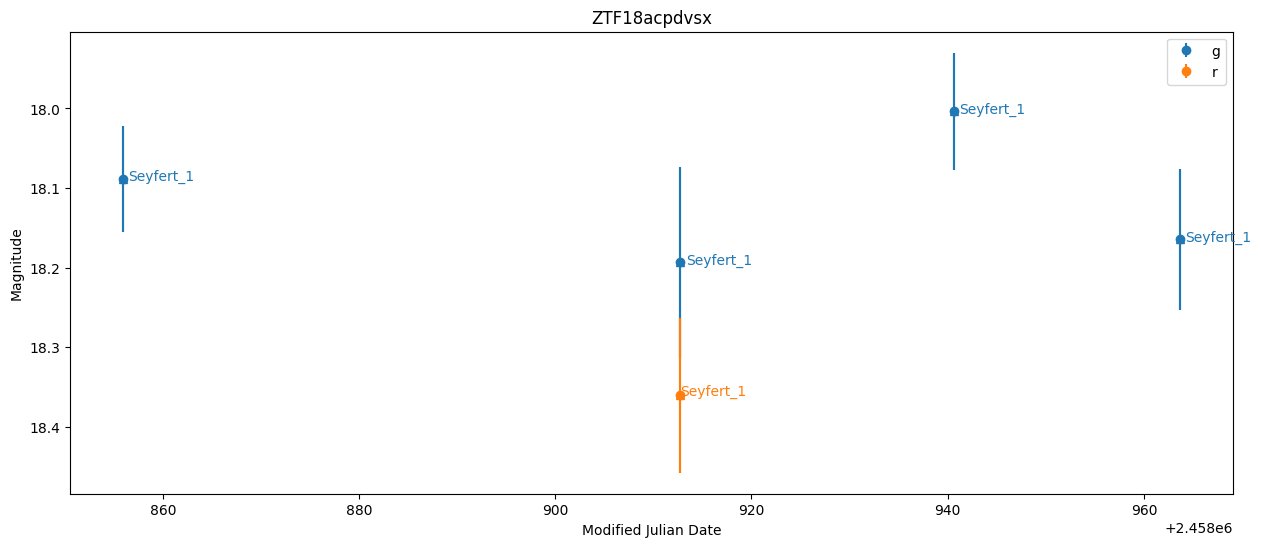

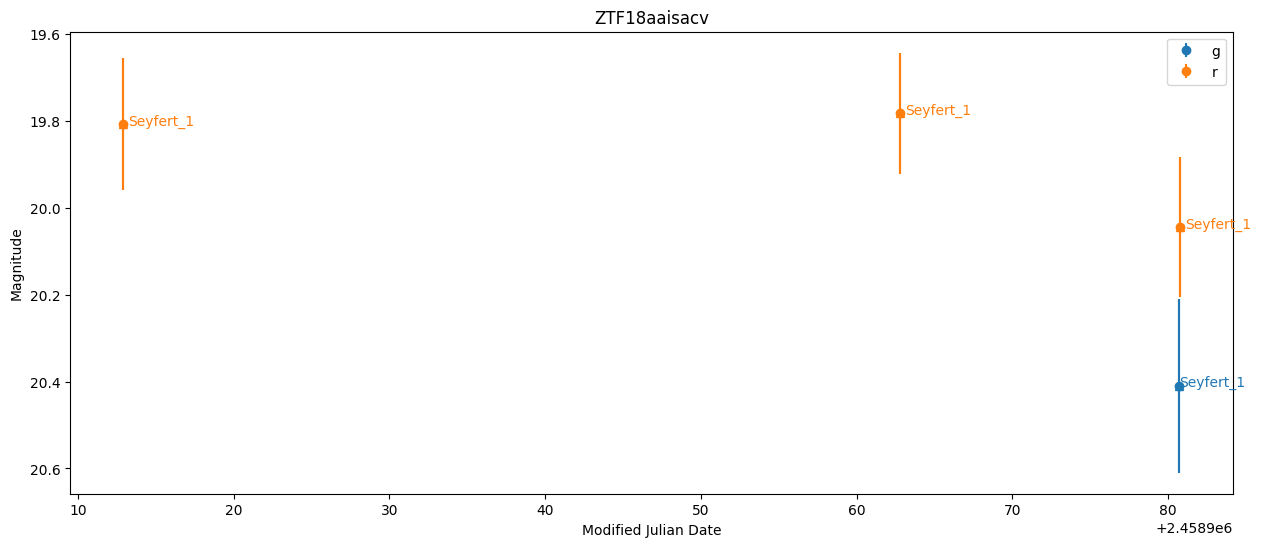

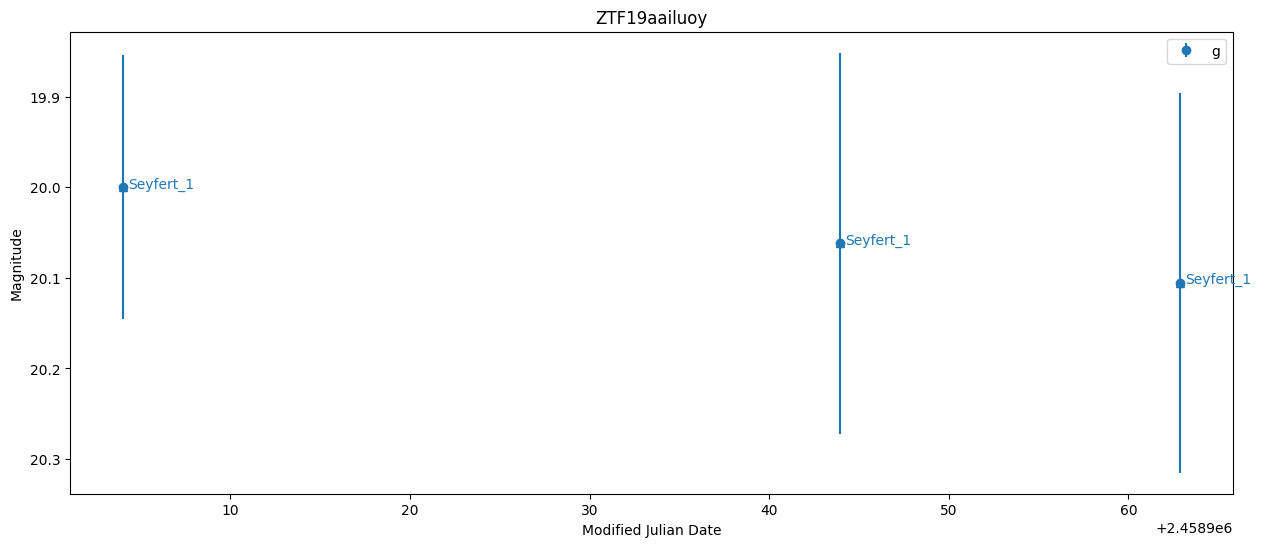

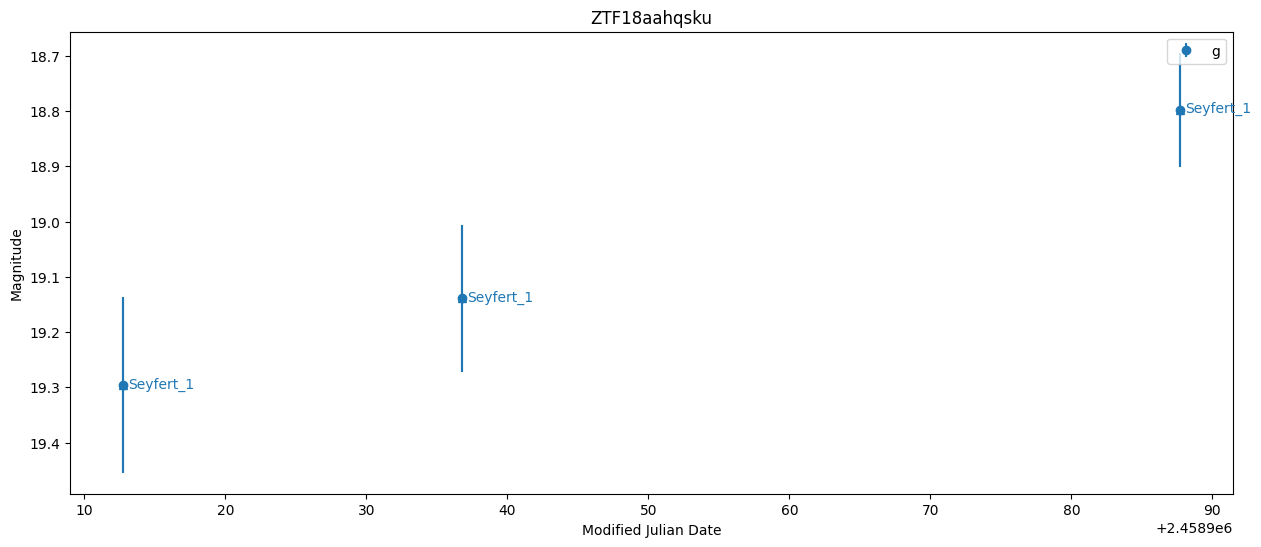

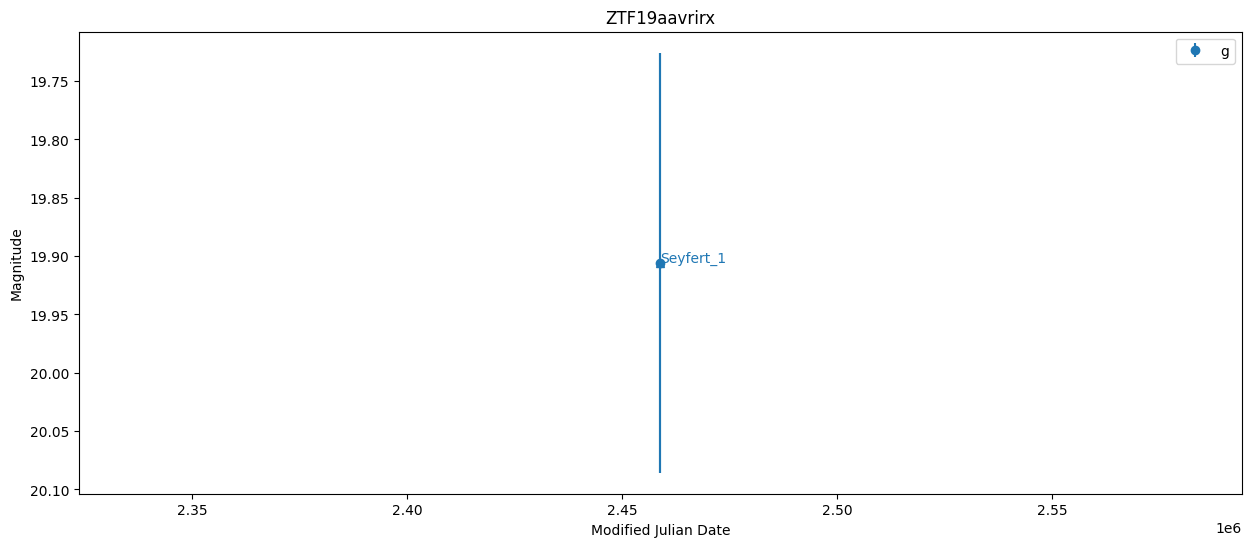

In [ ]:
df_alerts_seyfert = df_alerts[df_alerts['finkclass'] == 'Seyfert_1']
for objectId in df_alerts_seyfert['objectId'].unique():
    df_alerts_seyfert_objectId = df_alerts_seyfert[df_alerts_seyfert['objectId'] == objectId]
    plot_lc(df_alerts_seyfert_objectId, name=objectId)

In [ ]:
# Now plot the distribution of filterwise magpsf of the peak of the light curve.
# Is this one-point statistic able to distinguish between transients? TODO
# m = df_alerts.groupby(by=['objectId', 'fid'])[['fid', 'magpsf']].agg({'magpsf': 'min'})
# plt.hist(m[m['fid'] == 1]['magpsf'])

In [ ]:
# Now look at the mag evolution/day for each transient. TODO and probably use that to make cuts...very slow evolution then remove...

## Pre-machine learning data preparation

Add CVs, TDEs, and Novae.

In [14]:
import io
import requests
import pandas as pd

# Mine specific cases and add them to the data
# simbad_CataclyV_objId_list = ['ZTF18abucxou']
# tns_cv_objId_list = []
tns_tde_objId_list = [
    'ZTF24aaecooj', 'ZTF18aahqkbt', 'ZTF19accskvu', 'ZTF22aafujzv', 'ZTF18aabdajx', 'ZTF24aaahxwr',
    'ZTF23abvzeqp', 'ZTF18aabtxvd', 'ZTF20aahmtso', 'ZTF22aadesap', 'ZTF20abwtifz', 'ZTF21aanxhjv',
    'ZTF18achzddr', 'ZTF23abohtqf', 'ZTF19abzrhgq', 'ZTF23abgnxfv', 'ZTF22abegjtx', 'ZTF17aaazdba'
]  # These 18 objects are obtained from the fink portal (https://fink-portal.org/; class="(TNS) TDE"). TDEs are not present in SIMBAD.
tns_novae_objId_list = []
simbad_novae_objId_list = []

# get data for many objects
r = requests.post(
  'https://fink-portal.org/api/v1/objects',
  json={
    'objectId': ','.join(tns_tde_objId_list),
    'output-format': 'json'
  }
)

# Format output in a DataFrame
pdf = pd.read_json(io.BytesIO(r.content))
# pdf[['i:jd', 'i:magpsf', 'i:sigmapsf']]

# TODO: For each, we should ensure that there are atleast three points in atleast one passband.
# TODO: Also, we should ensure the conditions I use during the alert polling (not all of them, but relevant ones).

# TODO: Collate this data with main data

array(['ZTF24aaecooj', 'ZTF18aahqkbt', 'ZTF19accskvu', 'ZTF22aafujzv',
       'ZTF18aabdajx', 'ZTF24aaahxwr', 'ZTF23abvzeqp', 'ZTF18aabtxvd',
       'ZTF20aahmtso', 'ZTF20abwtifz', 'ZTF22aadesap', 'ZTF21aanxhjv',
       'ZTF18achzddr', 'ZTF23abohtqf', 'ZTF19abzrhgq', 'ZTF23abgnxfv',
       'ZTF22abegjtx', 'ZTF17aaazdba'], dtype=object)

## Machine learning

1. Create light curves from the alerts dataframe and store them

use days or hours as time units? I think hours since fast transients?

In [ ]:
seq_len_all = []  # stores the sequence length of all light curves.
for objId in df_alerts['objectId'].unique():
    # lc_data = get_lc(df_alerts, objId)  # of shape (n, 5), n is the total no. of alerts (including all bands) for that objectId
    pdf = df_alerts[df_alerts['objectId'] == objId]
    seq_len_all.append(len(pdf))

max_seq_len = max(seq_len_all)

In [ ]:
max_seq_len

30

In [ ]:
def pad_rows_to_match_columns(array, target_columns):
    """
    Pad each row of a 2D NumPy array with zeros to match a specified number of columns.

    Parameters:
    - array: 2D NumPy array
    - target_columns: Number of columns to match

    Returns:
    - Padded 2D NumPy array
    """
    # Get the number of columns in the original array
    original_columns = array.shape[1]

    # Calculate the number of columns to pad for each row
    pad_width = target_columns - original_columns

    # Pad each row with zeros
    padded_array = np.pad(array, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)

    return padded_array

dim = 2  # no. of channels/passbands in the light curve.

final_data, final_objIds = [], []

for objId in df_alerts['objectId'].unique():
    lc_data = get_lc(df_alerts, objId)  # of shape (n, 5), n is the total no. of alerts (including all bands) for that objectId
    obs_time = lc_data[:, -1]
    obs_mask = lc_data[:, dim:2*dim]
    obs_data = lc_data[:, :dim]
    # Make the first time to zero.
    obs_time = obs_time - obs_time[0]
    obs_time = obs_time * 24  # to convert times into hours.
    observed_tp_final = np.expand_dims(
        np.pad(obs_time, (0, max_seq_len-len(lc_data)), 'constant'),  # pad the time array with zero elements before the first time, and `max_seq_len-len(lc_data)` zeros after the last datapoint.
        1
    )
    observed_mask_final = pad_rows_to_match_columns(obs_mask.T, max_seq_len).T
    observed_data_final = pad_rows_to_match_columns(obs_data.T, max_seq_len).T
    data = np.concatenate((observed_data_final, observed_mask_final, observed_tp_final), axis=1)

    final_data.append(data)
    final_objIds.append(objId)

final_data = np.array(final_data)
final_data.shape, len(final_objIds)

((8026, 30, 5), 8026)

2. Prepare dataset and dataloader

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn import preprocessing
# import torch
# from torch.utils.data import TensorDataset, DataLoader

In [ ]:
# train_data, test_data = train_test_split(final_data, train_size=0.8, random_state=42, shuffle=True)

# le = preprocessing.LabelEncoder()
# final_objIds = le.fit_transform(final_objIds)  # use le.inverse_transform to get the string from the encoded value.

# train_data_objId, test_data_objId = train_test_split(final_objIds, train_size=0.8, random_state=42, shuffle=True)
# train_data_objId = torch.as_tensor(train_data_objId)
# test_data_objId = torch.as_tensor(test_data_objId)

# train_data = torch.as_tensor(train_data)
# test_data = torch.as_tensor(test_data)

# train_data.shape, test_data.shape, train_data_objId.shape, test_data_objId.shape

In [ ]:
# train_dataset = TensorDataset(train_data, train_data_objId)
# test_dataset = TensorDataset(test_data, test_data_objId)

# train_loader = DataLoader(train_dataset, num_workers=2, shuffle=True)
# test_loader = DataLoader(test_dataset, num_workers=2, shuffle=True)

In [ ]:
import torch
from create_data import get_data
data_obj = get_data(topic, train_size=0.1)

torch.save(data_obj["train_dataloader"], 'train_dataloader.pth')
torch.save(data_obj["test_dataloader"], 'test_dataloader.pth')

       objectId               candid     magpsf  sigmapsf  fid            jd  \
0  ZTF19aawfxge  1262464245615015003  18.745361  0.079393    2  2.459017e+06   
1  ZTF18aadijyg  1145223834215015029  19.354258  0.123969    1  2.458900e+06   

           ra        dec tnsclass cdsxmatch  roid  mulens  snn_snia_vs_nonia  \
0  322.679684   7.877787  Unknown       AGN     0     0.0                0.0   
1  100.296835  33.749905  Unknown       AGN     0     0.0                0.0   

   snn_sn_vs_all  rf_snia_vs_nonia  rf_kn_vs_nonkn tracklet  \
0            0.0               0.0             0.0     None   
1            0.0               0.0             0.0     None   

                                       lc_features_g  \
0  {'amplitude': 0.07329940795898438, 'anderson_d...   
1  {'amplitude': 0.05305004119873047, 'anderson_d...   

                                       lc_features_r finkclass  
0  {'amplitude': 0.09364986419677734, 'anderson_d...       AGN  
1  {'amplitude': None, 'ander

3. Training

In [ ]:
# todo: remove --dataset option since it has no meaning now.
# todo: is KL divergence, when doing unsupervised learning, used for reconstruction loss? If so, we may not need that and can instead replace it with self-supervised contrastive learning.
import subprocess
from subprocess import Popen, PIPE, CalledProcessError, STDOUT

def execute(cmd):
    """This function is taken from
    https://stackoverflow.com/a/28319191
    """
    with Popen(cmd, stdout=PIPE, bufsize=1, universal_newlines=True, stderr=STDOUT) as p:
        for line in p.stdout:
            print(line, end='') # process line here

    if p.returncode != 0:
        raise CalledProcessError(p.returncode, p.args)

command = ['python3', 'tan_unsupervised.py', '--niters', '2', '--lr', '0.001', '--batch-size', '32', '--rec-hidden', '64',
    '--latent-dim', '16', '--quantization', '0.016', '--enc', 'mtan_rnn', '--dec', 'mtan_rnn', '--n', '8000', '--gen-hidden', '50',
    '--learn-emb', '--kl', '--seed', '0', '--num-ref-points', '64', '--dataset', 'physionet', '--sample-tp', '0.9',
    '--save', '1', '--k-iwae', '5', '--std', '0.01', '--norm', '--topic', f'{topic}', '--dim', f'{dim}'
]
execute(command)

Namespace(niters=2, lr=0.001, std=0.01, latent_dim=16, rec_hidden=64, gen_hidden=50, embed_time=128, k_iwae=5, save=1, enc='mtan_rnn', dec='mtan_rnn', fname=None, seed=0, n=8000, batch_size=32, quantization=0.016, classif=False, norm=True, kl=True, learn_emb=True, enc_num_heads=1, dec_num_heads=1, length=20, num_ref_points=64, dataset='physionet', enc_rnn=True, dec_rnn=True, sample_tp=0.9, only_periodic=None, dropout=0.0, topic='ftransfer_ztf_2024-03-18_636039', dim=2) 90442
parameters: 91602 68932
Iter: 1, avg elbo: 1349717.2581, avg reconst: 1353659.8750, avg kl: 205.9556, mse: 271.677582
Iter: 2, avg elbo: 68178.0088, avg reconst: 68519.1641, avg kl: 2442.0430, mse: 13.692949


In [ ]:
from models import enc_mtan_rnn
from utils import subsample_timepoints

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_ref_points = 64
latent_dim = 16
learn_emb = True
rec_hidden = 64
enc_num_heads = 1
sample_tp = 0.9
num_sample = 10

rec = enc_mtan_rnn(
    dim, torch.linspace(0, 1., num_ref_points), latent_dim, rec_hidden,
    embed_time=128, learn_emb=learn_emb, num_heads=enc_num_heads, device=device
).to(device)

outputs = []
with torch.no_grad():
    for batch in data_obj["test_dataloader"]:
        test_batch = batch[0]  # batch[1] contains the objectIds in numerical form.
        test_batch = test_batch.to(device)
        observed_data, observed_mask, observed_tp = (
            test_batch[:, :, :dim],
            test_batch[:, :, dim: 2 * dim],
            test_batch[:, :, -1],
        )
        if sample_tp and sample_tp < 1:
            subsampled_data, subsampled_tp, subsampled_mask = subsample_timepoints(
                observed_data.clone(), observed_tp.clone(), observed_mask.clone(), sample_tp)
        else:
            subsampled_data, subsampled_tp, subsampled_mask = \
                observed_data, observed_tp, observed_mask
        out = rec(torch.cat((subsampled_data, subsampled_mask), 2), subsampled_tp)
        qz0_mean, qz0_logvar = (
            out[:, :, : latent_dim],
            out[:, :, latent_dim:],
        )
        epsilon = torch.randn(
            num_sample, qz0_mean.shape[0], qz0_mean.shape[1], qz0_mean.shape[2]
        ).to(device)
        z0 = epsilon * torch.exp(0.5 * qz0_logvar) + qz0_mean
        z0 = z0.view(-1, qz0_mean.shape[1], qz0_mean.shape[2])
        outputs.append((batch[1], z0))

In [ ]:
len(outputs)

7224

In [ ]:
# last dimension is 2*latent_dim. First latent_dim entries show the mean, and the latter show the logvar.
# second dimension contains `num_ref_points` entries.
# first dimension is `num_sample`.
outputs[0][1].shape

torch.Size([10, 64, 16])

In [ ]:
subsampled_data.shape, subsampled_mask.shape, torch.cat((subsampled_data, subsampled_mask), 2).shape, subsampled_tp.shape

(torch.Size([1, 30, 2]),
 torch.Size([1, 30, 2]),
 torch.Size([1, 30, 4]),
 torch.Size([1, 30]))

In [ ]:
observed_data.shape, observed_tp.shape, observed_mask.shape

(torch.Size([1, 30, 2]), torch.Size([1, 30]), torch.Size([1, 30, 2]))

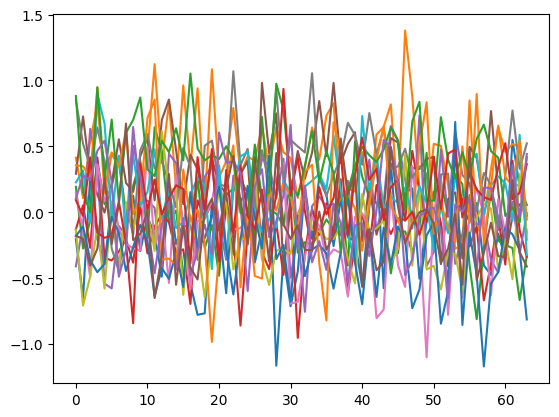

In [ ]:
for i in range(outputs[0][1].shape[-1]):
    plt.plot(outputs[0][1].mean(0)[:, i])

In [ ]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
final_objIds_encoded = le.fit_transform(final_objIds)  # use le.inverse_transform to get the string from the encoded value.

In [ ]:
final_objIds_again = le.inverse_transform(final_objIds_encoded)
assert np.all(final_objIds == final_objIds_again)

In [ ]:
outputs_condensed = np.vstack([o[1].mean(0).mean(1).numpy() for o in outputs])
objIds = le.inverse_transform([o[0][0].numpy() for o in outputs])
len(outputs_condensed), len(objIds)

(7224, 7224)

In [ ]:
df_alerts[df_alerts['objectId'] == objIds[0]]

,objectId,candid,magpsf,sigmapsf,fid,jd,ra,dec,tnsclass,cdsxmatch,roid,mulens,snn_snia_vs_nonia,snn_sn_vs_all,rf_snia_vs_nonia,rf_kn_vs_nonkn,tracklet,lc_features_g,lc_features_r,finkclass
60456,ZTF18acdwnbj,1239482832915015017,18.993652,0.085622,2,2.458994e+06,342.142748,39.634463,Unknown,Unknown,0,0.0,0.0,0.0,0.0,0.0,None,"{'amplitude': None, 'anderson_darling_normal':...","{'amplitude': 0.0, 'anderson_darling_normal': ...",Unknown
71487,ZTF18acdwnbj,1248470372915015006,19.356363,0.174401,2,2.459003e+06,342.142859,39.634490,Unknown,Unknown,0,0.0,0.0,0.0,0.0,0.0,None,"{'amplitude': 0.0, 'anderson_darling_normal': ...","{'amplitude': 0.18133163452148438, 'anderson_d...",Unknown
87546,ZTF18acdwnbj,1259361492915015007,19.065142,0.124304,2,2.459014e+06,342.142772,39.634524,Unknown,Unknown,0,0.0,0.0,0.0,0.0,0.0,None,"{'amplitude': 0.0, 'anderson_darling_normal': ...","{'amplitude': 0.1813497543334961, 'anderson_da...",Unknown


In [ ]:
# [0] because we assume only one finkclass will have the maximum occurence.
# If more than one finkclass have maximum occurence, then the first will be selected because we do [0].
oids_finkclass = []
for oi in objIds:
    common_finkclass = df_alerts[df_alerts['objectId'] == objIds[0]]['finkclass'].mode()[0]
    oids_finkclass.append((oi, common_finkclass))

oids_finkclass = np.array(oids_finkclass)

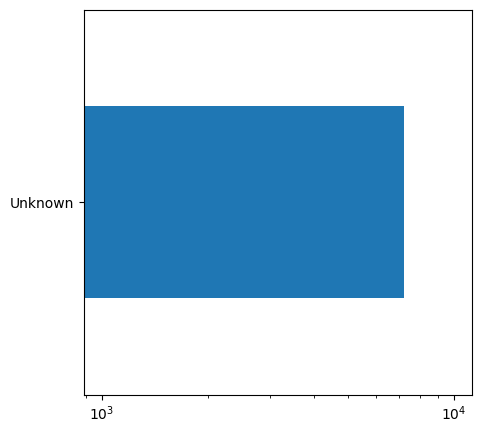

In [ ]:
# See the distribution of the fink classes.
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
pd.Series([oi[1] for oi in oids_finkclass]).value_counts().plot(kind='barh', ax=ax)
ax.set_xscale('log')

In [ ]:
outputs_condensed.shape, len(oids_finkclass)

((7224, 64), 7224)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

outputs_condensed_scaled = StandardScaler().fit_transform(outputs_condensed)
outputs_condensed_transformed = PCA(n_components=2).fit_transform(outputs_condensed_scaled)
outputs_condensed_transformed.shape

(7224, 2)

In [ ]:
t1 = outputs_condensed_transformed[:, 0]
t2 = outputs_condensed_transformed[:, 1]
np.where(t1 < -4.4), np.where(t1 > 4.5)

((array([1782, 2127, 4472, 6628]),), (array([ 137,  455, 2927, 2979]),))

In [ ]:
oids_finkclass[np.where(t1 < -4.4)]

array([['ZTF19abdpctu', 'Unknown'],
       ['ZTF19aayybky', 'Unknown'],
       ['ZTF19abjypbq', 'Unknown'],
       ['ZTF18aakodow', 'Unknown']], dtype='<U12')

In [ ]:
oids_finkclass[np.where(t1 > 4.5)]

array([['ZTF18abduinu', 'Unknown'],
       ['ZTF19aalajjf', 'Unknown'],
       ['ZTF18acdqqet', 'Unknown'],
       ['ZTF19aaufxeg', 'Unknown']], dtype='<U12')

In [ ]:
oids_finkclass[np.where(t2 > 3.5)]

array([['ZTF18acydqnk', 'Unknown'],
       ['ZTF18abkhybe', 'Unknown'],
       ['ZTF19abumxjo', 'Unknown'],
       ['ZTF20aayoyeo', 'Unknown'],
       ['ZTF18absrtud', 'Unknown'],
       ['ZTF19aanbrcj', 'Unknown']], dtype='<U12')

In [ ]:
oids_finkclass[np.where(t2 < -3)]

array([['ZTF20aafupey', 'Unknown'],
       ['ZTF18abnqdza', 'Unknown'],
       ['ZTF19aaafqpd', 'Unknown'],
       ['ZTF20aapcdlz', 'Unknown'],
       ['ZTF20aawwxxc', 'Unknown'],
       ['ZTF18abekpxn', 'Unknown'],
       ['ZTF18ablwyjy', 'Unknown'],
       ['ZTF19abidwoh', 'Unknown'],
       ['ZTF19aaspsgt', 'Unknown'],
       ['ZTF20aarueky', 'Unknown'],
       ['ZTF18abnjubj', 'Unknown'],
       ['ZTF20aaobzwh', 'Unknown'],
       ['ZTF19aamqpjn', 'Unknown'],
       ['ZTF19aaseyps', 'Unknown'],
       ['ZTF18abprrdm', 'Unknown'],
       ['ZTF18adacfja', 'Unknown']], dtype='<U12')

In [ ]:
oids_finkclass[np.where(t2 > -3)]

array([['ZTF18acdwnbj', 'Unknown'],
       ['ZTF19aabzulc', 'Unknown'],
       ['ZTF18abbsoci', 'Unknown'],
       ...,
       ['ZTF19aaafpop', 'Unknown'],
       ['ZTF19abbxlxb', 'Unknown'],
       ['ZTF18abuspoc', 'Unknown']], dtype='<U12')

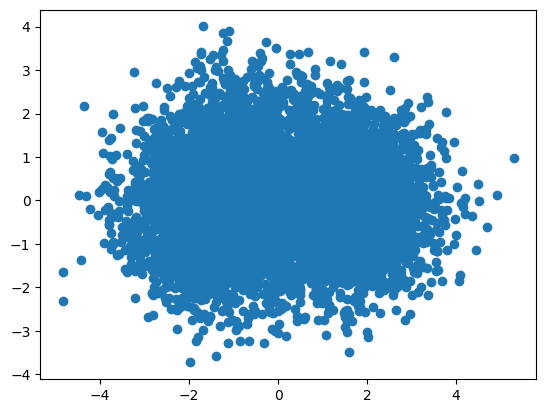

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.scatter(outputs_condensed_transformed[:, 0], outputs_condensed_transformed[:, 1])

In [ ]:
!pip install umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.4 MB/s eta 0:00:00
  Created wheel for umap-learn: filename=umap_learn-0.5.5-py3-none-any.whl size=86832 sha256=e9fdb5f71f594a9221b9a7b34dbbddd09f7246c64ad39564fe3626cb6b16ec8a
  Stored in directory: /root/.cache/pip/wheels/3a/70/07/428d2b58660a1a3b431db59b806a10da736612ebbc66c1bcc5
Successfully built umap-learn


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


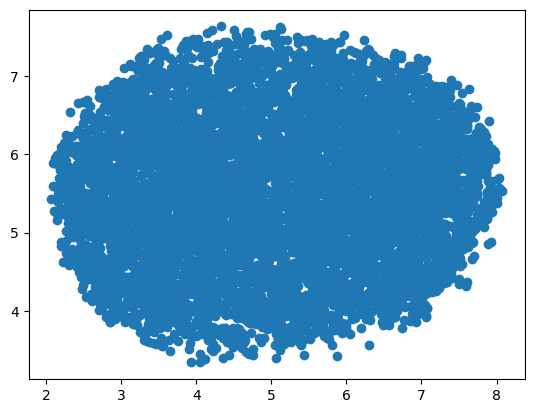

In [ ]:
import umap
umap_embedding = umap.UMAP(random_state=42).fit_transform(outputs_condensed)  # without transforming. Assuming the different features have meaningful relationships, so per-feature normalization makes less sense.
fig, ax = plt.subplots(1, 1)
ax.scatter(umap_embedding[:, 0], umap_embedding[:, 1])

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


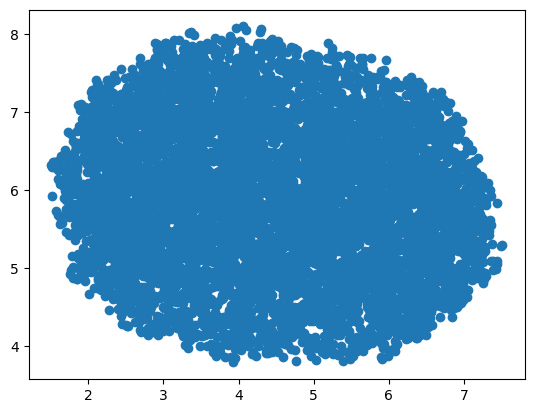

In [ ]:
import umap
umap_embedding = umap.UMAP(random_state=42).fit_transform(outputs_condensed_scaled)
fig, ax = plt.subplots(1, 1)
ax.scatter(umap_embedding[:, 0], umap_embedding[:, 1])

TODO: A first check is to just visualise the latent representations (at the reference points), and see if simple summary statistics of those latent representations can be used for classifying light curves. Need to have a separate dataset where we can quantify the performance; so need to have a dataset where the classification is certain.\
TODO: Can adapt the mtan code to perform classification, using labels as the most common finkclass out of all alerts of the given transient.